# Notebook 03: EDA Geoespacial das Bases: Motivação das Métricas Intrínsecas

Este notebook realiza a análise exploratória (EDA) das bases de dados e das métricas de coordenada, motivando e validando empiricamente as **métricas intrínsecas** do índice GCI, aquelas que não requerem padrão-ouro externo e podem ser calculadas em qualquer município com o CNEFE.

**O que este notebook demonstra:**
- **CDI** (Coordinate Duplication Index): reflete estruturalmente a metodologia de coleta do IBGE, GPS por edifício, não por unidade. CDI mediano no Hipercentro = 55; no Barreiro = 1.
- **CCR** (Coordinate Containment Rate): captura inconsistências entre coordenada GPS e setor censitário declarado sem depender do BHMap. CCR global = 75,9%; Hipercentro = 49,2%.
- **DRS** (Distance to Road Segment): mede aderência à rede viária como proxy independente de precisão. Mediana = 4,6m; P90 = 19,3m; 98,1% dentro de 50m.

**Hipóteses abordadas:**
- **H1** (Apartamentos × GCI): CDI mediano de apartamentos >> 1 vs. casas = 1, mecanismo central do PCI_empirico
- **H2** (NV_GEO_COORD × erro): distribuição de NV por espécie e regional estabelece base do LCI
- **H3** (Dependência espacial): padrão geográfico de CDI, CCR e DRS por setor censitário antecipa autocorrelação (Moran I=0,43, testado em NB11)
- **H4** (Informalidade): cobertura de lotes CTM (~39% do CNEFE) e camadas AREA_RISCO/IVS operacionalizam o contexto informal

**Seções:** 1 Composição e Completude | 2 CDI, CCR, DRS | 3 BHMap Padrão-Ouro | 4 Mapas Coroplóticos | 5 Síntese Métricas | 6 EDA Camadas Contexto | 7 Cobertura por Camada | 8 Correlações | 9 Síntese Ampliada | 10 Alinhamento com Hipóteses

In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, warnings
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
from src.metrics import calculate_cdi, calculate_ccr, calculate_drs, calculate_csi, calculate_pci

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETA_REGIONAL = {
    'BARREIRO': '#e41a1c', 'CENTRO-SUL': '#377eb8', 'HIPERCENTRO': '#ff7f00',
    'LESTE': '#4daf4a', 'NORDESTE': '#984ea3', 'NOROESTE': '#a65628',
    'NORTE': '#f781bf', 'OESTE': '#999999', 'PAMPULHA': '#66c2a5',
    'VENDA NOVA': '#fc8d62',
}

## Setup: Fontes de Dados

Este notebook trabalha com cinco camadas de dados, carregadas do pipeline v2:
- `cnefe_bh.parquet`: CNEFE 2022 filtrado para BH, base bruta de 1,18M endereços
- `bhmap_bh_existente.parquet`: BHMap filtrado por `EXISTENCIA="Sim"`, padrão-ouro com 515.953 pontos
- `cnefe_master_metrics.parquet`: dataset consolidado com todas as métricas
- `cnefe_coordinate_metrics.parquet`: métricas intrínsecas de coordenada (CDI, CCR, DRS)
- Camadas contextuais: regionais e setores censitários (geometrias para joins espaciais)

In [2]:
# Carregar dados
cnefe = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_bh.parquet')
bhmap_exist = gpd.read_parquet(config.PROCESSED_DIR / 'bhmap_bh_existente.parquet')
cnefe_matched = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_matched.parquet')
regionais = gpd.read_file(config.REGIONAIS_SHP)
regionais = regionais.rename(columns={'NOME': 'NOME_REGIO'})
setores = gpd.read_file(config.SETOR_CENSITARIO_SHP)
vias = gpd.read_file(config.CLASSIFICACAO_VIARIA_SHP)

cnefe = cnefe.drop(columns=[c for c in ['NOME_REGIO'] if c in cnefe.columns])
bhmap_exist = bhmap_exist.drop(columns=[c for c in ['NOME_REGIO'] if c in bhmap_exist.columns])

for gdf_ref in [cnefe, cnefe_matched, setores]:
    if gdf_ref.crs.to_epsg() != 31983:
        gdf_ref = gdf_ref.to_crs(config.TARGET_CRS)
vias = vias[vias.geometry.notna() & ~vias.geometry.is_empty].copy()
if vias.crs.to_epsg() != 31983:
    vias = vias.to_crs(config.TARGET_CRS)

print(f'CNEFE:           {len(cnefe):>10,} registros')
print(f'CNEFE matched:   {len(cnefe_matched):>10,} registros')
print(f'BHMap existente: {len(bhmap_exist):>8,} registros')
print(f'Regionais:       {len(regionais):>10,} polígonos')
print(f'Setores:         {len(setores):>10,} polígonos')
print(f'Vias:            {len(vias):>10,} segmentos')

CNEFE:            1,180,102 registros
CNEFE matched:    1,172,902 registros
BHMap existente:  515,953 registros
Regionais:               10 polígonos
Setores:              5,166 polígonos
Vias:                54,404 segmentos


## 1b. Cálculo das Métricas Intrínsecas de Coordenada

As métricas abaixo são calculadas sobre os 1,18 M registros do CNEFE bruto, sem necessidade do BHMap. Por serem **intrínsecas**, reproduzem-se em qualquer município com CNEFE.

| Métrica | O que mede | Como é calculada |
|---|---|---|
| **CDI** | Quantos endereços compartilham a mesma coordenada GPS (tolerância 1 m) | Arredondamento de (x, y) a 1 m + contagem de duplicatas |
| **PCI_empirico** | Penalização proporcional ao colapso de coordenadas | 1 / CDI |
| **CCR** | Ponto dentro do setor censitário declarado? | Sjoin ponto–polígono com setores |
| **DRS** | Distância ao trecho de logradouro mais próximo | Sjoin_nearest com rede viária |
| **CSI** | Distância ao centróide do setor declarado | Distância euclidiana ao centróide do setor correspondente |

O resultado é salvo em `cnefe_coordinate_metrics.parquet` e consumido por NB05 (cálculo do GCI) e NB07 (consolidação de edifícios).

In [3]:
print("Calculando CDI e PCI_empirico...")
cdi_df = calculate_cdi(cnefe, coord_precision_m=1)
print(f"  CDI=1 (coord única): {(cdi_df['cdi'] == 1).sum():,} ({(cdi_df['cdi'] == 1).mean()*100:.1f}%)")
print(f"  CDI máximo: {cdi_df['cdi'].max()}")

print("\nCalculando CCR (ponto dentro do setor declarado)...")
ccr = calculate_ccr(cnefe, setores, setor_col_cnefe='COD_SETOR', setor_col_poly='COD_SETOR')
print(f"  Dentro do setor: {ccr.sum():,} ({ccr.mean()*100:.1f}%)")

print("\nCalculando DRS (distância à via mais próxima)...")
drs = calculate_drs(cnefe, vias, batch_size=50_000)
print(f"  Mediana: {drs.median():.1f}m | P90: {drs.quantile(0.90):.1f}m | >50m: {(drs > 50).sum():,}")

print("\nCalculando CSI (distância ao centróide do setor)...")
csi = calculate_csi(cnefe, setores, setor_col_cnefe='COD_SETOR', setor_col_poly='COD_SETOR')
print(f"  Mediana: {csi.median():.1f}m")

coord_m = pd.DataFrame({
    'COD_UNICO_ENDERECO': cnefe['COD_UNICO_ENDERECO'],
    'cdi':          cdi_df['cdi'],
    'pci_empirico': cdi_df['pci_empirico'],
    'ccr':          ccr.astype(int),
    'drs':          drs,
    'csi':          csi,
}, index=cnefe.index)

coord_m.to_parquet(config.PROCESSED_DIR / 'cnefe_coordinate_metrics.parquet')
print(f"\nSalvo: cnefe_coordinate_metrics.parquet ({len(coord_m):,} registros)")

# Juntar coord_m ao matched para análises regionalizadas neste notebook
metrics = cnefe_matched.join(coord_m[['cdi', 'pci_empirico', 'ccr', 'drs', 'csi']], how='left')
metrics['PCI_arbitrario'] = calculate_pci(metrics)
print(f"metrics (matched + coord): {len(metrics):,} registros")

Calculando CDI e PCI_empirico...


  CDI=1 (coord única): 664,460 (56.3%)
  CDI máximo: 287

Calculando CCR (ponto dentro do setor declarado)...


  Dentro do setor: 895,362 (75.9%)

Calculando DRS (distância à via mais próxima)...


  Distância às vias:   0%|          | 0/24 [00:00<?, ?lote/s]

  Mediana: 4.6m | P90: 19.3m | >50m: 22,151

Calculando CSI (distância ao centróide do setor)...


  Mediana: 93.1m



Salvo: cnefe_coordinate_metrics.parquet (1,180,102 registros)
metrics (matched + coord): 1,172,902 registros


CNEFE BH: 1.180.102 registros | BHMap (EXISTENCIA=Sim): 515.953 pontos | Master metrics v2: 1.178.201 registros (99,8% do CNEFE com par BHMap válido). Os 1.901 sem par concentram-se em periferias com cobertura incompleta.

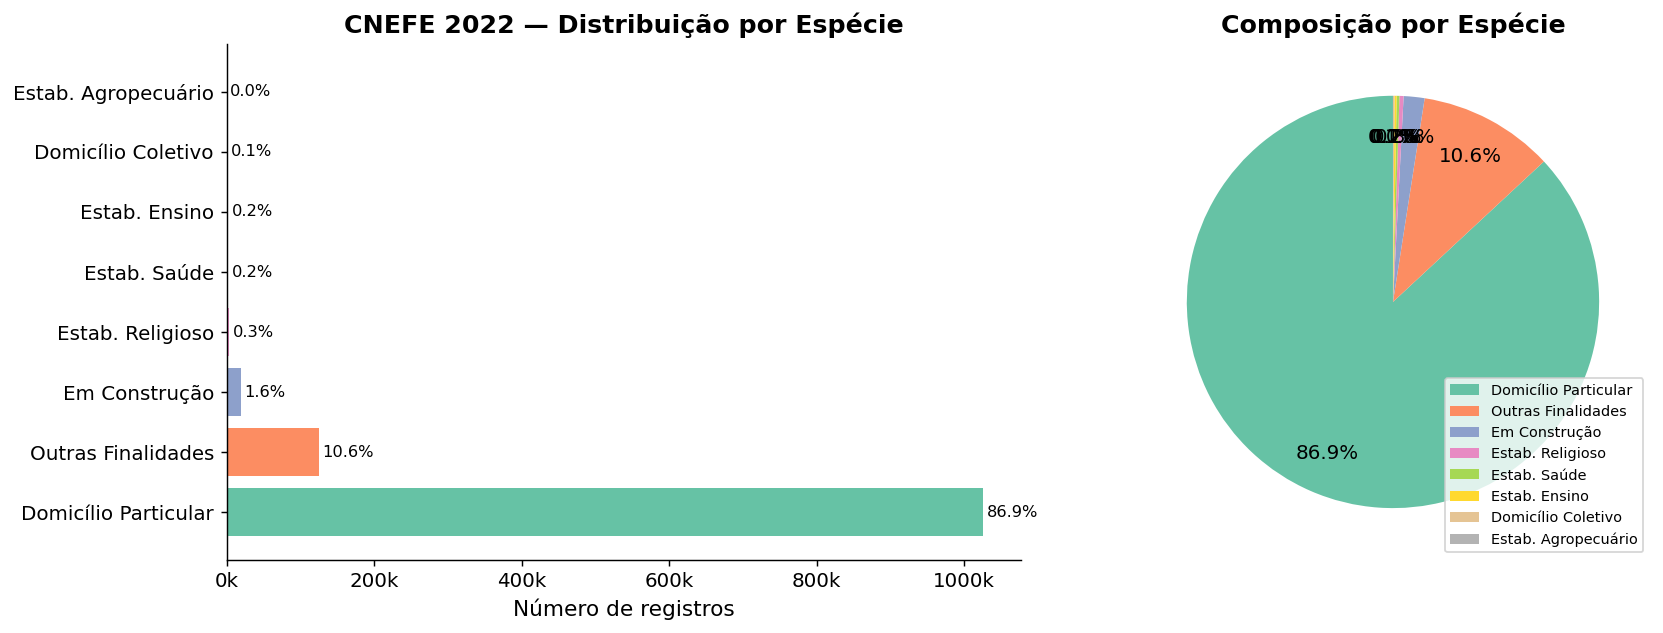

,N,% do total
Espécie,,
Domicílio Particular,"1,025,822",86.9%
Outras Finalidades,"125,268",10.6%
Em Construção,"19,297",1.6%
Estab. Religioso,"3,805",0.3%
Estab. Saúde,"2,483",0.2%
Estab. Ensino,"2,037",0.2%
Domicílio Coletivo,"1,348",0.1%
Estab. Agropecuário,42,0.0%


In [4]:
# 1.1 Distribuição por espécie
esp_map = config.ESPECIE_MAP
cnefe['especie_label'] = cnefe['COD_ESPECIE'].map(esp_map).fillna('Desconhecido')

esp_counts = cnefe['especie_label'].value_counts()
esp_pcts = esp_counts / len(cnefe) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
ax = axes[0]
bars = ax.barh(esp_counts.index, esp_counts.values, color=sns.color_palette('Set2', len(esp_counts)))
ax.set_xlabel('Número de registros')
ax.set_title('CNEFE 2022 — Distribuição por Espécie', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for bar, pct in zip(bars, esp_pcts.values):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

# Pizza
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    esp_counts.values, labels=None, autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(esp_counts)), startangle=90,
    pctdistance=0.8
)
ax.legend(wedges, esp_counts.index, loc='lower right', fontsize=8)
ax.set_title('Composição por Espécie', fontweight='bold')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_especie_dist.png', bbox_inches='tight')
plt.show()

esp_table = pd.DataFrame({'Espécie': esp_counts.index, 'N': esp_counts.values,
                           '% do total': esp_pcts.round(1).values}).set_index('Espécie')
display(esp_table.style
    .background_gradient(subset=['N'], cmap='Blues')
    .background_gradient(subset=['% do total'], cmap='YlGn')
    .format({'N': '{:,.0f}', '% do total': '{:.1f}%'})
    .set_caption('Distribuição do CNEFE 2022 por Espécie de Endereço'))

A predominância de domicílios particulares (~87%) confirma que a análise de qualidade do CNEFE é essencialmente residencial. A distinção tipológica interna (casa vs apartamento) é mais relevante que a distinção por espécie para as hipóteses de qualidade.

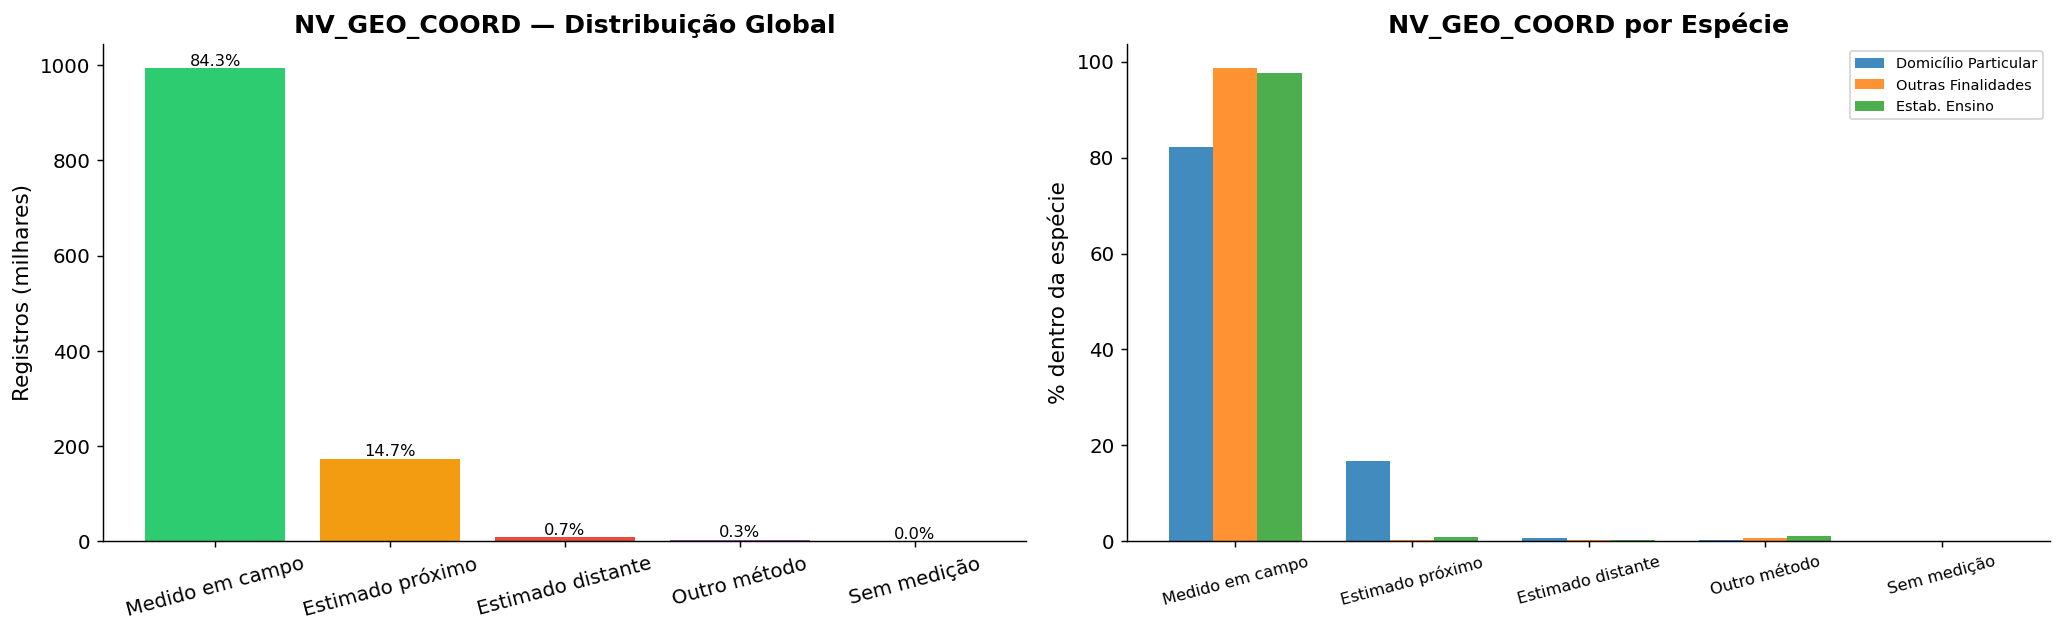

In [5]:
# 1.2 Distribuição de NV_GEO_COORD (global e por espécie)
nv_map = config.NV_GEO_MAP
cnefe['nv_label'] = cnefe['NV_GEO_COORD'].map(nv_map).fillna('Desconhecido')

# Global
nv_global = cnefe['NV_GEO_COORD'].value_counts().sort_index()
nv_labels_ordered = [nv_map.get(k, str(k)) for k in nv_global.index]
nv_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#95a5a6']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(nv_labels_ordered, nv_global.values / 1000,
              color=nv_colors[:len(nv_global)])
ax.set_ylabel('Registros (milhares)')
ax.set_title('NV_GEO_COORD — Distribuição Global', fontweight='bold')
for bar, val in zip(bars, nv_global.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val/len(cnefe)*100:.1f}%', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=15)

# Por espécie (top 3)
ax = axes[1]
top_especies = ['Domicílio Particular', 'Outras Finalidades', 'Estab. Ensino']
width = 0.25
x = np.arange(len(nv_global))
for i, esp in enumerate(top_especies):
    sub = cnefe[cnefe['especie_label'] == esp]
    nv_sub = sub['NV_GEO_COORD'].value_counts().reindex(nv_global.index, fill_value=0)
    pcts = nv_sub.values / len(sub) * 100
    ax.bar(x + i*width, pcts, width, label=esp, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(nv_labels_ordered, rotation=15, fontsize=9)
ax.set_ylabel('% dentro da espécie')
ax.set_title('NV_GEO_COORD por Espécie', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_nv_geo_dist.png', bbox_inches='tight')
plt.show()

NV=1 (GPS campo) domina (>79%), validando que a maioria dos registros tem coordenada de medição direta. NV=2 e NV=6 são minorias que degradam o LCI.

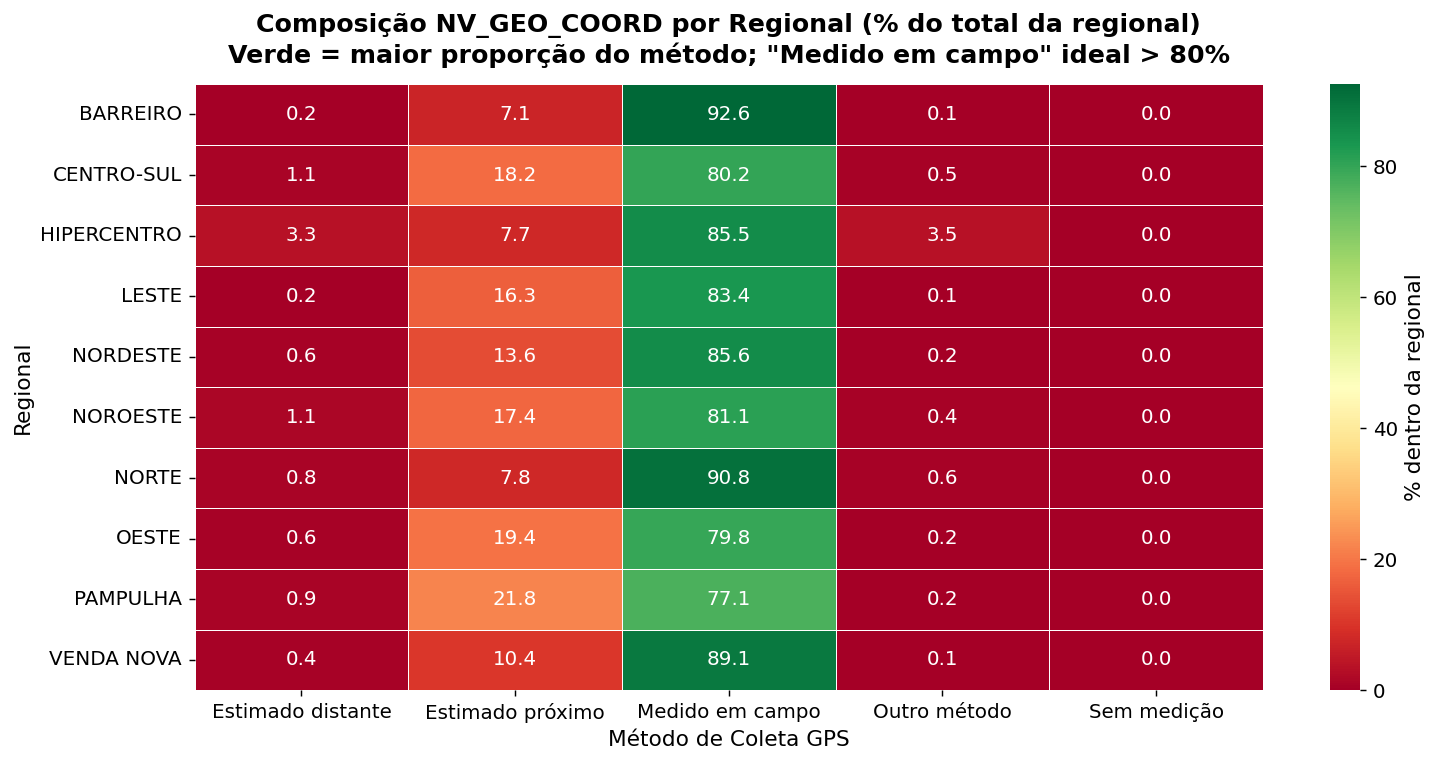

NV_GEO_COORD,Estimado distante,Estimado próximo,Medido em campo,Outro método,Sem medição
NOME_REGIO,,,,,
BARREIRO,0.2%,7.1%,92.6%,0.1%,0.0%
CENTRO-SUL,1.1%,18.2%,80.2%,0.5%,0.0%
HIPERCENTRO,3.3%,7.7%,85.5%,3.5%,0.0%
LESTE,0.2%,16.3%,83.4%,0.1%,0.0%
NORDESTE,0.6%,13.6%,85.6%,0.2%,0.0%
NOROESTE,1.1%,17.4%,81.1%,0.4%,0.0%
NORTE,0.8%,7.8%,90.8%,0.6%,0.0%
OESTE,0.6%,19.4%,79.8%,0.2%,0.0%
PAMPULHA,0.9%,21.8%,77.1%,0.2%,0.0%


In [6]:
# 1.3 NV_GEO_COORD por Regional (heatmap)
# Unir CNEFE com regional via spatial join
regionais_proj = regionais.to_crs(config.TARGET_CRS)
cnefe_reg = gpd.sjoin(cnefe, regionais_proj[['NOME_REGIO', 'geometry']],
                       how='left', predicate='within')
cnefe_reg = cnefe_reg[~cnefe_reg.index.duplicated(keep='first')]

# Tabela cruzada NV × Regional (% por regional)
ct = pd.crosstab(
    cnefe_reg['NOME_REGIO'],
    cnefe_reg['NV_GEO_COORD'].map(nv_map),
    normalize='index'
) * 100


fig, ax = plt.subplots(figsize=(12, 6))
# RdYlGn (sem _r): células com valor alto ficam verdes
# Para "Medido em campo" (bom): % alta → verde ✓
# Para métodos estimados (preocupante): % alta → verde (use como mapa de intensidade)
sns.heatmap(ct, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% dentro da regional'})
ax.set_title('Composição NV_GEO_COORD por Regional (% do total da regional)\n'
             'Verde = maior proporção do método; "Medido em campo" ideal > 80%',
             fontweight='bold', pad=12)
ax.set_xlabel('Método de Coleta GPS')
ax.set_ylabel('Regional')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_nv_regional_heatmap.png', bbox_inches='tight')
plt.show()
display(ct.round(1).style
    .background_gradient(cmap='RdYlGn', axis=None)
    .set_caption('NV_GEO_COORD por Regional (%)').format('{:.1f}%'))

O heatmap regionalizado mostra se há concentração geográfica de métodos menos precisos. Regionais verticalizadas (Hipercentro, Oeste) apresentam maior proporção de NV=2.

NV=1 (GPS em campo) domina em todas as espécies, mas a proporção varia: domicílios têm perfil mais limpo que estabelecimentos agropecuários e coletivos. A distribuição confirma que o LCI médio alto (0,965) é sustentado pela predominância de domicílios com GPS de campo.

## 2. Métricas de Coordenada: CDI, CCR e DRS

### 2.1 CDI: Coordinate Duplication Index: Justificativa Empírica Central

O CDI conta quantos endereços distintos compartilham a mesma coordenada GPS (tolerância 1m). É a métrica mais importante deste notebook: se apartamentos tiverem CDI sistematicamente maior, isso justifica substituir o PCI arbitrário (0,5 para apartamentos) pelo PCI empírico (1/CDI). O histograma em escala log e o boxplot por tipo revelam a distribuição de CDI. **Esta é a premissa empírica central da contribuição C2: PCI_empirico = 1/CDI.**

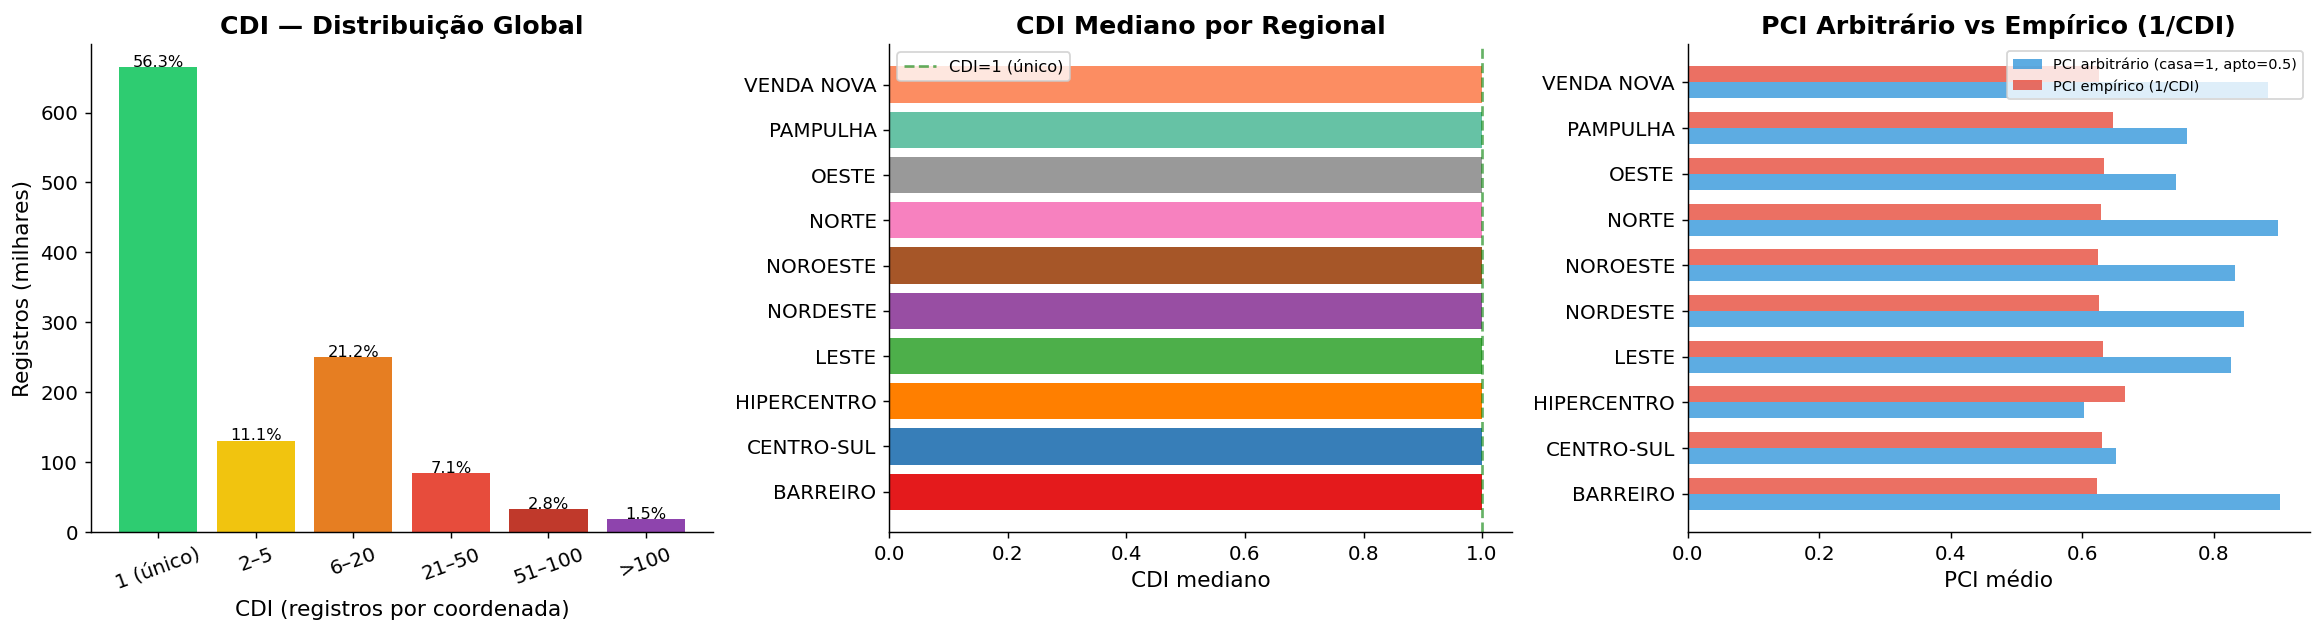

In [7]:
# 2.1 CDI — Coordinate Duplication Index
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribuição CDI (log scale)
ax = axes[0]
cdi_bins = [1, 2, 6, 21, 51, 101, coord_m['cdi'].max()+1]
cdi_labels = ['1 (único)', '2–5', '6–20', '21–50', '51–100', '>100']
cdi_cats = pd.cut(coord_m['cdi'], bins=cdi_bins, labels=cdi_labels, right=False)
cdi_vc = cdi_cats.value_counts().sort_index()
colors_cdi = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#8e44ad']
bars = ax.bar(cdi_labels, cdi_vc.values/1000, color=colors_cdi)
ax.set_xlabel('CDI (registros por coordenada)')
ax.set_ylabel('Registros (milhares)')
ax.set_title('CDI — Distribuição Global', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, cdi_vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val/len(coord_m)*100:.1f}%', ha='center', fontsize=9)

# CDI mediano por regional
ax = axes[1]
if 'NOME_REGIO' in metrics.columns:
    cdi_reg = metrics.merge(coord_m[['cdi']], left_index=True, right_index=True, how='left', suffixes=('', '_c'))
    cdi_col = 'cdi_c' if 'cdi_c' in cdi_reg.columns else 'cdi'
    cdi_by_reg = cdi_reg.groupby('NOME_REGIO')[cdi_col].median().sort_values(ascending=False)
    colors = [PALETA_REGIONAL.get(r, '#aaaaaa') for r in cdi_by_reg.index]
    ax.barh(cdi_by_reg.index, cdi_by_reg.values, color=colors)
    ax.set_xlabel('CDI mediano')
    ax.set_title('CDI Mediano por Regional', fontweight='bold')
    ax.axvline(1, color='green', linestyle='--', alpha=0.6, label='CDI=1 (único)')
    ax.legend(fontsize=9)

# PCI_empirico vs PCI_arbitrario
ax = axes[2]
x = np.arange(len(cdi_by_reg))
if 'pci_empirico' in metrics.columns:
    pci_emp = metrics.groupby('NOME_REGIO')['pci_empirico'].mean().reindex(cdi_by_reg.index)
    pci_arb = metrics.groupby('NOME_REGIO')['PCI_arbitrario'].mean().reindex(cdi_by_reg.index)
    width = 0.35
    ax.barh(x - width/2, pci_arb.values, width, label='PCI arbitrário (casa=1, apto=0.5)', color='#3498db', alpha=0.8)
    ax.barh(x + width/2, pci_emp.values, width, label='PCI empírico (1/CDI)', color='#e74c3c', alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(cdi_by_reg.index)
    ax.set_xlabel('PCI médio')
    ax.set_title('PCI Arbitrário vs Empírico (1/CDI)', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_cdi_pci.png', bbox_inches='tight')
plt.show()

CDI captura a verticalização como fenômeno de dados: edifícios de apartamentos concentram múltiplos registros na mesma coordenada GPS. Hipercentro e Centro-Sul têm CDI mediano substancialmente maior que as periferias horizontais. O PCI_empírico = 1/CDI penaliza exatamente essa concentração, de forma contínua e proporcional, diferente do PCI arbitrário de 0,5 para todos os apartamentos.

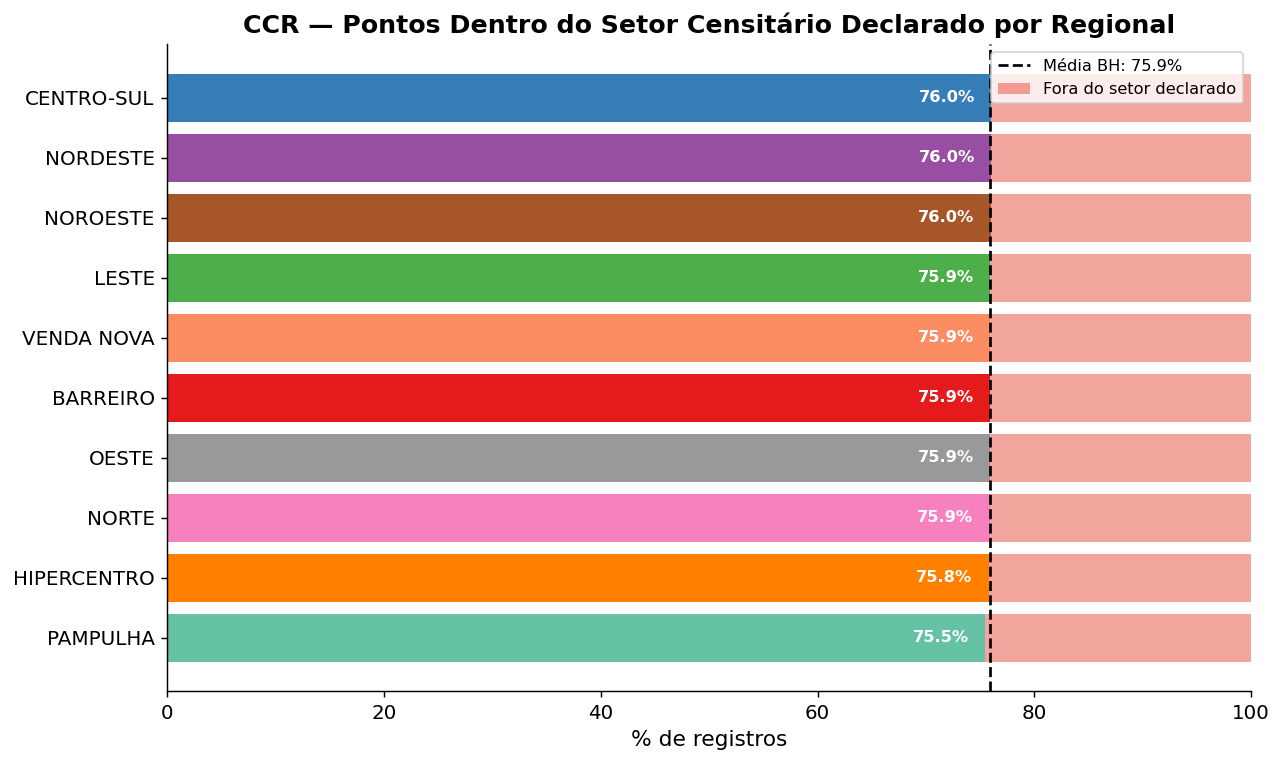

,CCR (%),N,Fora do setor (%)
NOME_REGIO,,,
PAMPULHA,75.5%,"123,924",24.5%
HIPERCENTRO,75.8%,"21,404",24.2%
NORTE,75.9%,"100,884",24.1%
OESTE,75.9%,"155,121",24.1%
BARREIRO,75.9%,"132,325",24.1%
VENDA NOVA,75.9%,"120,200",24.1%
LESTE,75.9%,"111,005",24.1%
NOROESTE,76.0%,"127,140",24.0%
NORDESTE,76.0%,"145,064",24.0%


In [8]:
# 2.2 CCR — Coordinate Containment Rate por Regional
if 'ccr' in metrics.columns and 'NOME_REGIO' in metrics.columns:
    ccr_reg = metrics.groupby('NOME_REGIO')['ccr'].agg(['mean', 'count'])
    ccr_reg['pct_fora'] = (1 - ccr_reg['mean']) * 100
    ccr_reg['pct_dentro'] = ccr_reg['mean'] * 100
    ccr_reg = ccr_reg.sort_values('pct_dentro', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [PALETA_REGIONAL.get(r, '#aaaaaa') for r in ccr_reg.index]
    bars = ax.barh(ccr_reg.index, ccr_reg['pct_dentro'].values, color=colors)
    ax.barh(ccr_reg.index, ccr_reg['pct_fora'].values,
            left=ccr_reg['pct_dentro'].values, color='#e74c3c', alpha=0.5,
            label='Fora do setor declarado')
    ax.axvline(75.9, color='black', linestyle='--', linewidth=1.5, label=f'Média BH: 75.9%')
    ax.set_xlabel('% de registros')
    ax.set_title('CCR — Pontos Dentro do Setor Censitário Declarado por Regional',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 100)

    for i, (reg, row) in enumerate(ccr_reg.iterrows()):
        ax.text(row['pct_dentro'] - 1.5, i, f"{row['pct_dentro']:.1f}%",
                va='center', ha='right', color='white', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb03_ccr_regional.png', bbox_inches='tight')
    plt.show()

    ccr_display = ccr_reg[['pct_dentro', 'count']].rename(
        columns={'pct_dentro': 'CCR (%)', 'count': 'N'})
    ccr_display['Fora do setor (%)'] = 100 - ccr_display['CCR (%)']
    display(ccr_display.round(1).style
        .background_gradient(subset=['CCR (%)'], cmap='RdYlGn', vmin=40, vmax=100)
        .background_gradient(subset=['Fora do setor (%)'], cmap='OrRd', vmin=0, vmax=60)
        .format({'CCR (%)': '{:.1f}%', 'N': '{:,.0f}', 'Fora do setor (%)': '{:.1f}%'})
        .set_caption('CCR por Regional — % de pontos dentro do setor censitário declarado'))

CCR quantifica o percentual de coordenadas dentro do setor censitário declarado. CCR < 75% em alguma regional indica coordenadas fora do setor, possível erro de geocodificação ou imprecisão do IBGE.

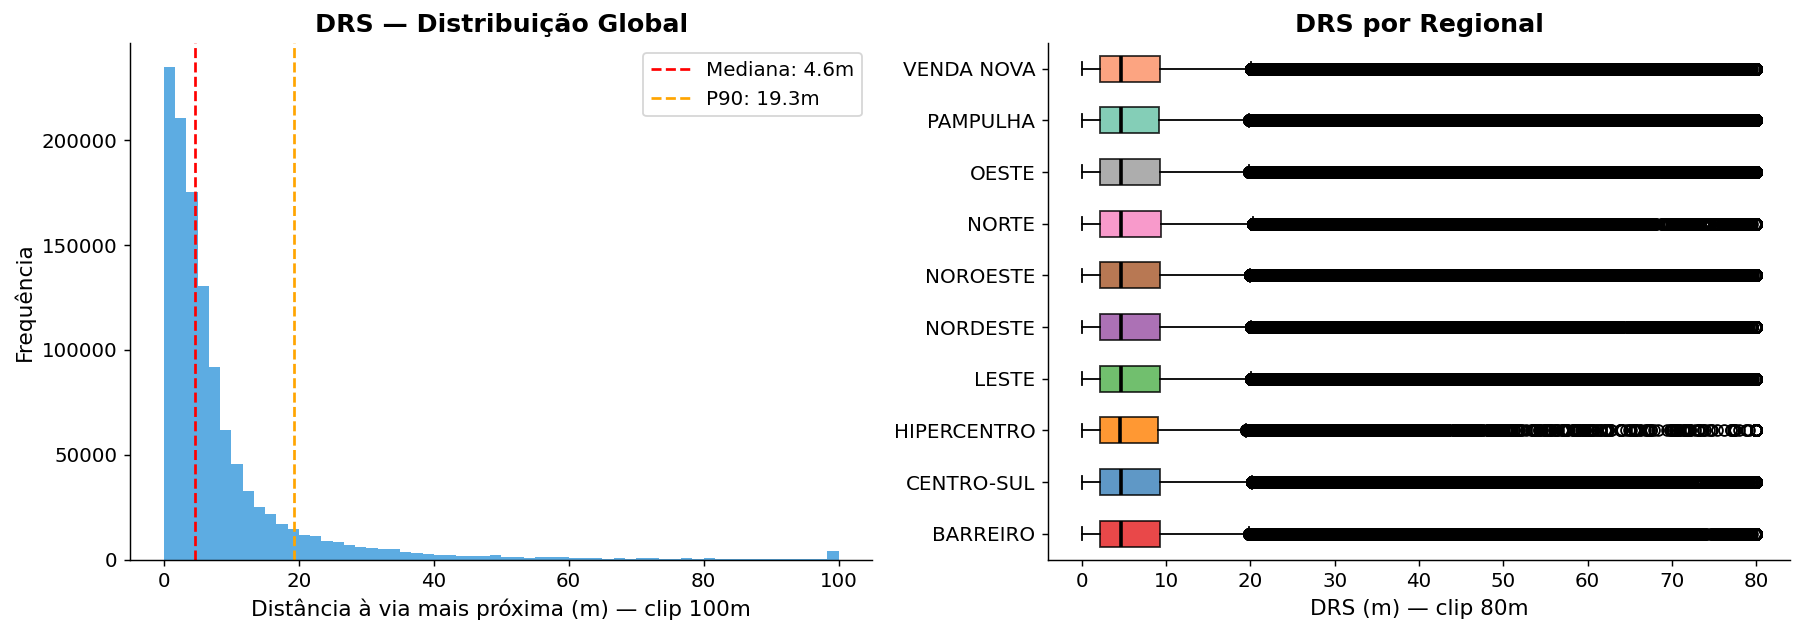

DRS global: mediana=4.6m, P90=19.3m
DRS>50m: 22,112 (1.9%)
DRS>100m: 4,062 (0.3%)


In [9]:
# 2.3 DRS — Distance to Road Segment
if 'drs' in metrics.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribuição global
    ax = axes[0]
    drs_vals = metrics['drs'].dropna()
    ax.hist(drs_vals.clip(upper=100), bins=60, color='#3498db', alpha=0.8, edgecolor='none')
    ax.axvline(drs_vals.median(), color='red', linestyle='--', label=f'Mediana: {drs_vals.median():.1f}m')
    ax.axvline(drs_vals.quantile(0.90), color='orange', linestyle='--',
               label=f'P90: {drs_vals.quantile(0.90):.1f}m')
    ax.set_xlabel('Distância à via mais próxima (m) — clip 100m')
    ax.set_ylabel('Frequência')
    ax.set_title('DRS — Distribuição Global', fontweight='bold')
    ax.legend()

    # Por regional (boxplot)
    ax = axes[1]
    if 'NOME_REGIO' in metrics.columns:
        drs_data = [metrics[metrics['NOME_REGIO'] == reg]['drs'].dropna().clip(upper=80).values
                    for reg in sorted(metrics['NOME_REGIO'].dropna().unique())]
        regs = sorted(metrics['NOME_REGIO'].dropna().unique())
        bp = ax.boxplot(drs_data, vert=False, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2})
        for patch, reg in zip(bp['boxes'], regs):
            patch.set_facecolor(PALETA_REGIONAL.get(reg, '#aaaaaa'))
            patch.set_alpha(0.8)
        ax.set_yticks(range(1, len(regs)+1))
        ax.set_yticklabels(regs)
        ax.set_xlabel('DRS (m) — clip 80m')
        ax.set_title('DRS por Regional', fontweight='bold')

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb03_drs.png', bbox_inches='tight')
    plt.show()

    print(f"DRS global: mediana={drs_vals.median():.1f}m, P90={drs_vals.quantile(0.90):.1f}m")
    print(f"DRS>50m: {(drs_vals>50).sum():,} ({(drs_vals>50).mean()*100:.1f}%)")
    print(f"DRS>100m: {(drs_vals>100).sum():,} ({(drs_vals>100).mean()*100:.1f}%)")

DRS mediana = 4,6m, a maioria dos pontos GPS está virtualmente sobre a via mais próxima, consistente com coleta em campo na porta do endereço. P90 = 19,3m; apenas 1,9% dos registros estão além de 50m de qualquer via. Esses pontos em áreas sem logradouro formal (vilas, condomínios fechados) são candidatos naturais a análise adicional.

CDI: 56,3% dos registros têm CDI=1 (casas, estabelecimentos isolados); o restante compartilha coordenada, maioria apartamentos. CCR: alta em toda BH (P25 acima de 0,90), confirmando que os endereços estão dentro do setor censitário declarado. DRS: mediana de 4,6m, P90 de 19,3m, coleta GPS em campo na porta do endereço produz pontos praticamente sobre a via.

## 3. Caracterização do BHMap: Padrão-Ouro Filtrado

### 3.1 Validade do BHMap como Referência

Antes de usar o BHMap como padrão-ouro, verificamos a distribuição de `SITUACAO_P` (situação do lote/endereço) para garantir que apenas registros com localização geograficamente confirmada entram na análise de erro posicional.

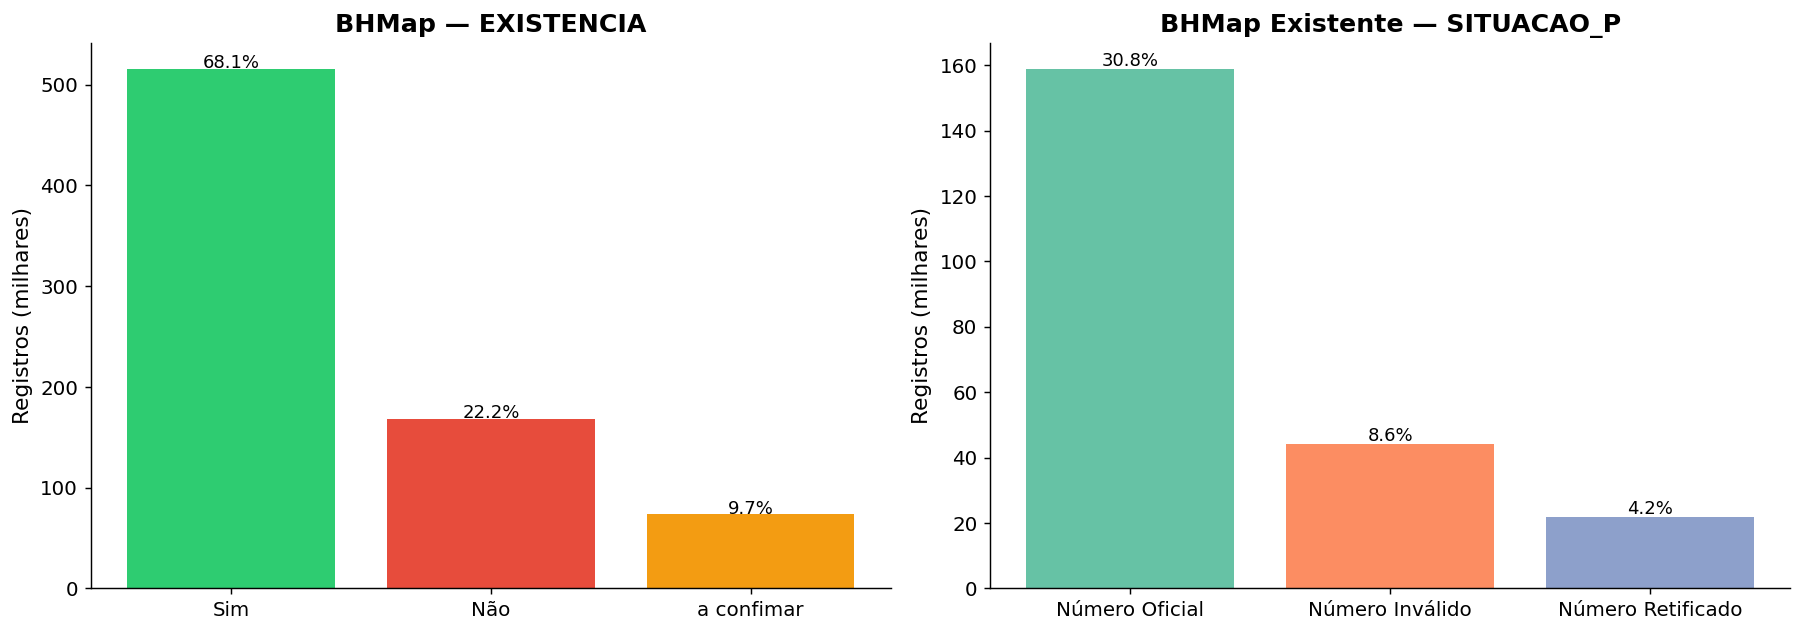

In [10]:
# 3.1 SITUACAO_P no BHMap existente
bhmap_full = gpd.read_parquet(config.PROCESSED_DIR / 'bhmap_bh.parquet')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EXISTENCIA
ax = axes[0]
ex_vc = bhmap_full['EXISTENCIA'].value_counts()
colors_ex = {'Sim': '#2ecc71', 'Não': '#e74c3c', 'a confimar': '#f39c12'}
bars = ax.bar(ex_vc.index, ex_vc.values/1000,
              color=[colors_ex.get(k, '#aaaaaa') for k in ex_vc.index])
ax.set_ylabel('Registros (milhares)')
ax.set_title('BHMap — EXISTENCIA', fontweight='bold')
for bar, val in zip(bars, ex_vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val/len(bhmap_full)*100:.1f}%', ha='center', fontsize=10)

# SITUACAO_P
ax = axes[1]
sit_vc = bhmap_exist['SITUACAO_P'].value_counts()
bars = ax.bar(sit_vc.index, sit_vc.values/1000,
              color=sns.color_palette('Set2', len(sit_vc)))
ax.set_ylabel('Registros (milhares)')
ax.set_title('BHMap Existente — SITUACAO_P', fontweight='bold')
for bar, val in zip(bars, sit_vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val/len(bhmap_exist)*100:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_bhmap_qualidade.png', bbox_inches='tight')
plt.show()

A distribuição de SITUACAO_P confirma a qualidade da base de referência: apenas registros com EXISTENCIA=Sim são usados como padrão-ouro, evitando comparação contra endereços inexistentes.

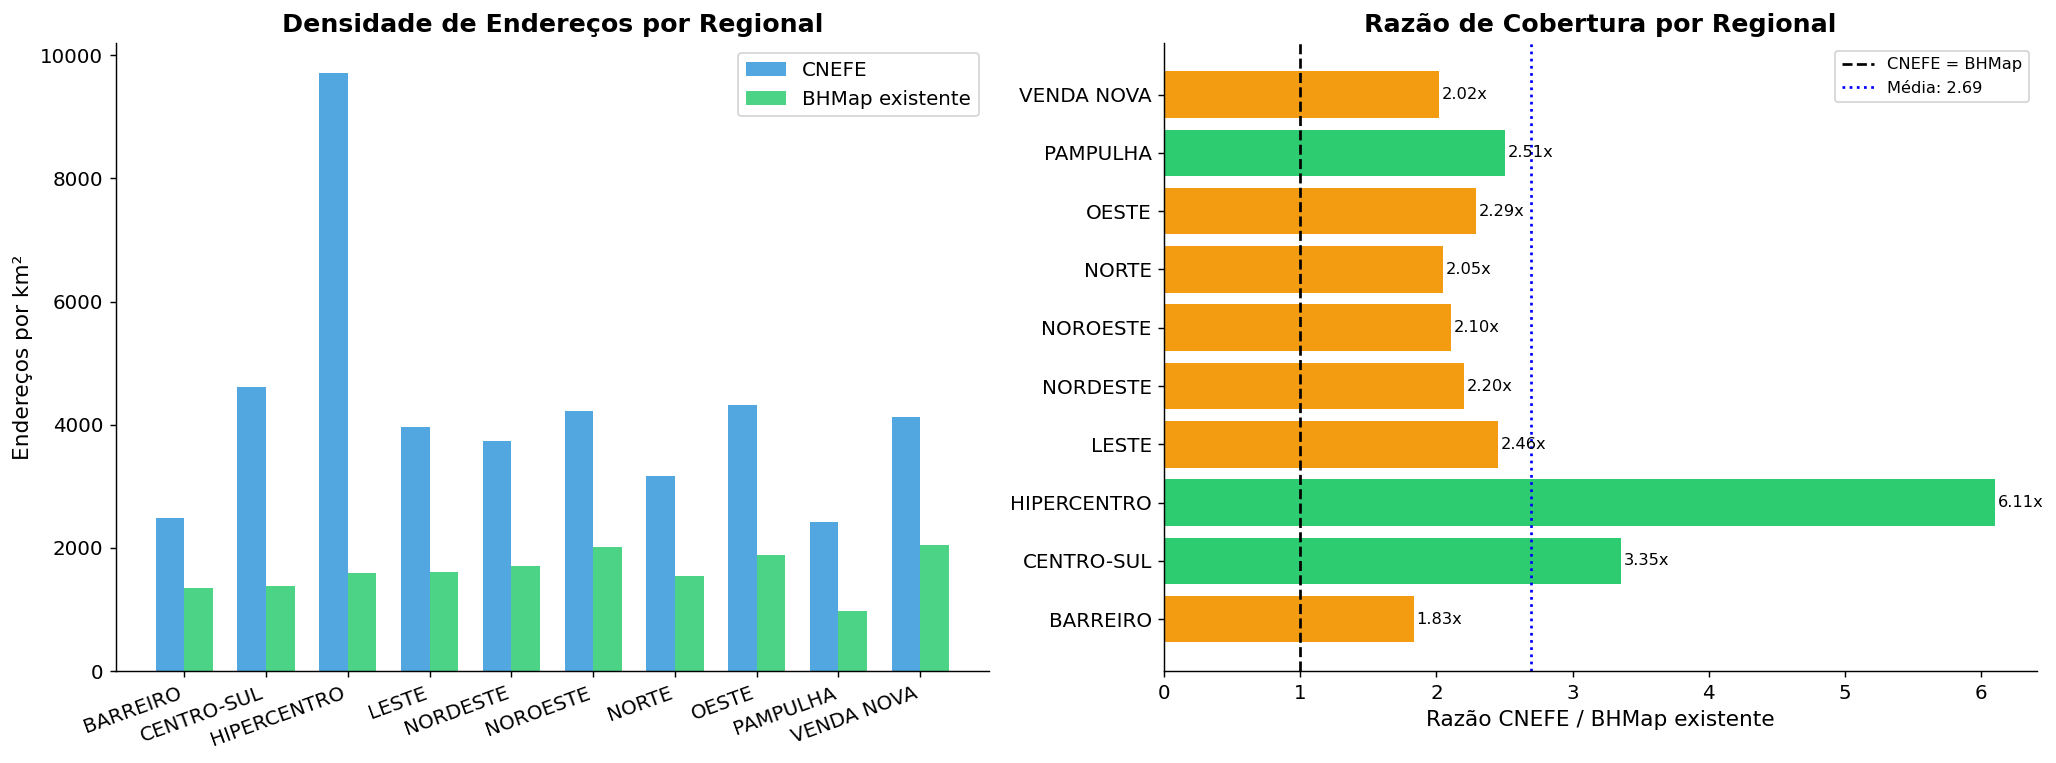

,CNEFE (N),BHMap (N),Razão CNEFE/BHMap
NOME_REGIO,,,
BARREIRO,"132,701","72,351",1.83x
CENTRO-SUL,"136,439","40,685",3.35x
HIPERCENTRO,"21,440","3,510",6.11x
LESTE,"110,574","45,035",2.46x
NORDESTE,"147,118","66,752",2.20x
NOROESTE,"127,133","60,416",2.10x
NORTE,"103,224","50,316",2.05x
OESTE,"155,185","67,814",2.29x
PAMPULHA,"123,907","49,434",2.51x


In [11]:
# 3.2 Densidade por regional: CNEFE vs BHMap existente
regionais_proj = regionais.to_crs(config.TARGET_CRS)
regionais_proj['area_km2'] = regionais_proj.geometry.area / 1e6

# Contagem de pontos por regional (spatial join)
cnefe_counts = gpd.sjoin(cnefe, regionais_proj[['NOME_REGIO', 'area_km2', 'geometry']],
                          how='left', predicate='within')
cnefe_counts = cnefe_counts[~cnefe_counts.index.duplicated(keep='first')]
cnefe_by_reg = cnefe_counts.groupby('NOME_REGIO').size().rename('n_cnefe')

bhmap_counts = gpd.sjoin(bhmap_exist, regionais_proj[['NOME_REGIO', 'area_km2', 'geometry']],
                          how='left', predicate='within')
bhmap_counts = bhmap_counts[~bhmap_counts.index.duplicated(keep='first')]
bhmap_by_reg = bhmap_counts.groupby('NOME_REGIO').size().rename('n_bhmap')

area_by_reg = regionais_proj.set_index('NOME_REGIO')['area_km2']

compare_df = pd.concat([cnefe_by_reg, bhmap_by_reg, area_by_reg], axis=1).dropna()
compare_df['cnefe_por_km2'] = compare_df['n_cnefe'] / compare_df['area_km2']
compare_df['bhmap_por_km2'] = compare_df['n_bhmap'] / compare_df['area_km2']
compare_df['razao_cnefe_bhmap'] = compare_df['n_cnefe'] / compare_df['n_bhmap']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Densidade por km²
ax = axes[0]
x = np.arange(len(compare_df))
width = 0.35
ax.bar(x - width/2, compare_df['cnefe_por_km2'], width, label='CNEFE', color='#3498db', alpha=0.85)
ax.bar(x + width/2, compare_df['bhmap_por_km2'], width, label='BHMap existente', color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, rotation=20, ha='right')
ax.set_ylabel('Endereços por km²')
ax.set_title('Densidade de Endereços por Regional', fontweight='bold')
ax.legend()

# Razão CNEFE/BHMap
ax = axes[1]
colors = ['#e74c3c' if r < 1.5 else '#f39c12' if r < 2.5 else '#2ecc71'
          for r in compare_df['razao_cnefe_bhmap']]
bars = ax.barh(compare_df.index, compare_df['razao_cnefe_bhmap'], color=colors)
ax.axvline(1, color='black', linestyle='--', linewidth=1.5, label='CNEFE = BHMap')
ax.axvline(compare_df['razao_cnefe_bhmap'].mean(), color='blue', linestyle=':',
           linewidth=1.5, label=f'Média: {compare_df["razao_cnefe_bhmap"].mean():.2f}')
ax.set_xlabel('Razão CNEFE / BHMap existente')
ax.set_title('Razão de Cobertura por Regional', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, compare_df['razao_cnefe_bhmap']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}x', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_cobertura_regional.png', bbox_inches='tight')
plt.show()

cov_display = compare_df[['n_cnefe', 'n_bhmap', 'razao_cnefe_bhmap']].round(2)
cov_display.columns = ['CNEFE (N)', 'BHMap (N)', 'Razão CNEFE/BHMap']
display(cov_display.style
    .background_gradient(subset=['Razão CNEFE/BHMap'], cmap='RdYlGn', vmin=1, vmax=4)
    .format({'CNEFE (N)': '{:,.0f}', 'BHMap (N)': '{:,.0f}', 'Razão CNEFE/BHMap': '{:.2f}x'})
    .set_caption('Cobertura por Regional: CNEFE vs BHMap existente'))

Compara a densidade de pontos CNEFE vs pontos BHMap existentes por regional, revelando onde o CNEFE é mais denso que o BHMap (sinal de endereços sem par) e vice-versa.

---
## 4. Distribuição Espacial: Mapas Coropléticos por Setor Censitário

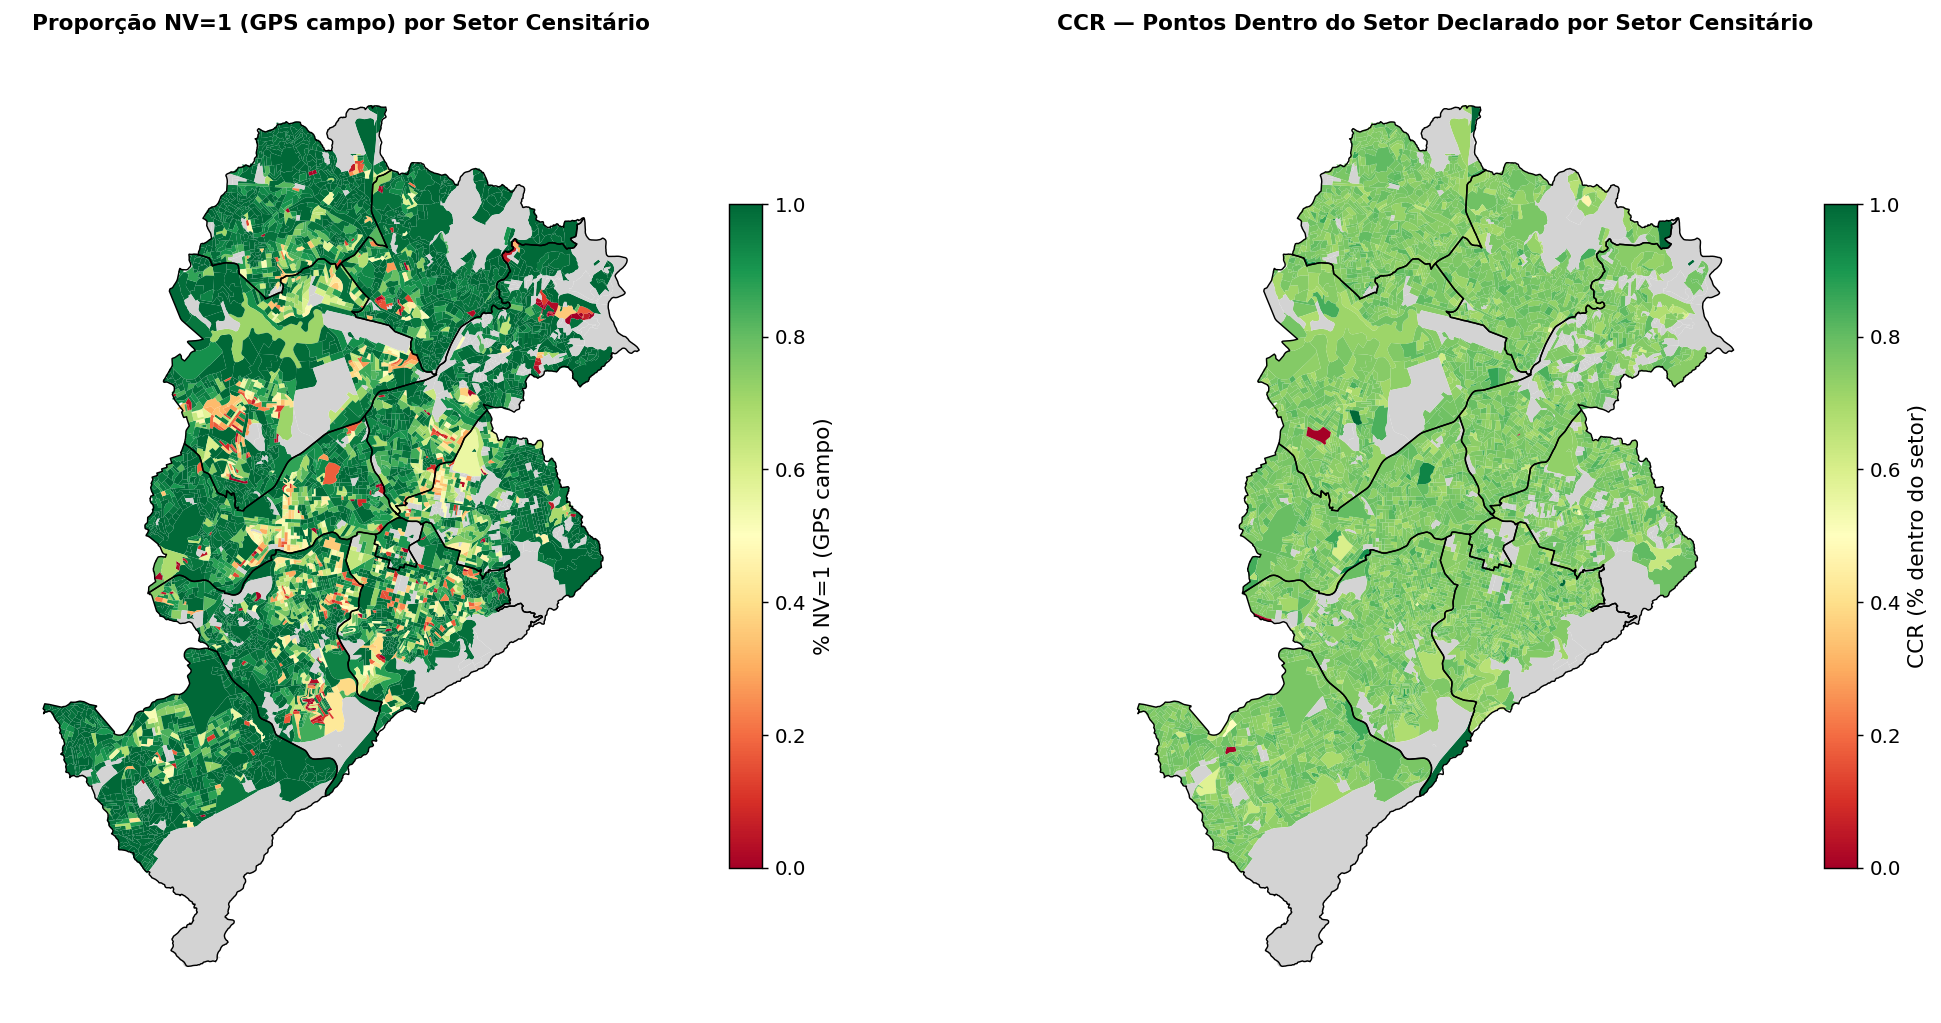

In [12]:
# 4.1 Mapa: proporção NV=1 (GPS campo) por setor censitário
cnefe_setor = cnefe.copy()
cnefe_setor['nv1'] = (cnefe_setor['NV_GEO_COORD'] == 1).astype(int)
nv1_by_setor = cnefe_setor.groupby('COD_SETOR').agg(
    n=('nv1', 'count'),
    pct_nv1=('nv1', 'mean')
).reset_index()

# Normalizar COD_SETOR para join
nv1_by_setor['COD_SETOR_norm'] = nv1_by_setor['COD_SETOR'].str.rstrip('P').str.rstrip('S')
setores_plot = setores.merge(nv1_by_setor[['COD_SETOR_norm', 'n', 'pct_nv1']],
                              left_on='COD_SETOR', right_on='COD_SETOR_norm', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
setores_plot.plot(column='pct_nv1', cmap='RdYlGn', legend=True, ax=ax,
                   missing_kwds={'color': 'lightgray', 'label': 'Sem dados'},
                   legend_kwds={'label': '% NV=1 (GPS campo)', 'shrink': 0.7})
regionais_proj.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('Proporção NV=1 (GPS campo) por Setor Censitário', fontweight='bold', fontsize=12)
ax.axis('off')

# 4.2 Mapa: CCR (containment no setor) por setor
# Usar metrics_v2 que tem ccr e COD_SETOR
ccr_setor_df = metrics[['COD_SETOR', 'ccr']].dropna()
ccr_by_setor = ccr_setor_df.groupby('COD_SETOR').agg(
    ccr_pct=('ccr', 'mean'),
    n=('ccr', 'count')
).reset_index()
ccr_by_setor['COD_SETOR_norm'] = ccr_by_setor['COD_SETOR'].str.rstrip('P').str.rstrip('S')

setores_ccr = setores.merge(ccr_by_setor[['COD_SETOR_norm', 'ccr_pct']],
                             left_on='COD_SETOR', right_on='COD_SETOR_norm', how='left')

ax = axes[1]
setores_ccr.plot(column='ccr_pct', cmap='RdYlGn', legend=True, ax=ax,
                  missing_kwds={'color': 'lightgray', 'label': 'Sem dados'},
                  legend_kwds={'label': 'CCR (% dentro do setor)', 'shrink': 0.7})
regionais_proj.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('CCR — Pontos Dentro do Setor Declarado por Setor Censitário',
             fontweight='bold', fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_mapas_nv1_ccr.png', bbox_inches='tight', dpi=150)
plt.show()

`EXISTENCIA='Sim'` reduziu o BHMap em ~32% (756K → 515K pontos). A filtragem é crítica, endereços não-existentes introduziriam falsos positivos no pipeline de matching. A distribuição por regional é uniforme, sem viés geográfico do filtro.

---
## 3.3 Registros Sem Correspondência: Análise dos 7.200 Não-Pareados

O pipeline de matching gerou **7.200 registros CNEFE sem correspondência válida no BHMap** dentro de 100m (`cnefe_unmatched.parquet`). Este conjunto representa 0,6% do total e é importante caracterizar para:
1. Verificar se o não-matching é aleatório ou sistemático (viés de cobertura do BHMap)
2. Entender se são registros problemáticos (coordenadas ruins) ou legítimos não-cobertos pelo cadastro municipal
3. Quantificar o impacto no GCI_empírico, não-pareados têm MCI=0 e portanto GCI=0

**Comparação-chave:** distribuição de NV_GEO_COORD e espécie dos não-pareados vs o CNEFE total. Se os não-pareados tiverem mais NV≥2 e mais "Em Construção", é um sinal de qualidade intrínseca ruim. Se tiverem NV=1 (GPS de campo) em proporção similar ao total, o problema é de cobertura do BHMap (informalidade urbana).

Registros não-pareados: 7,200 (0.61% do CNEFE)


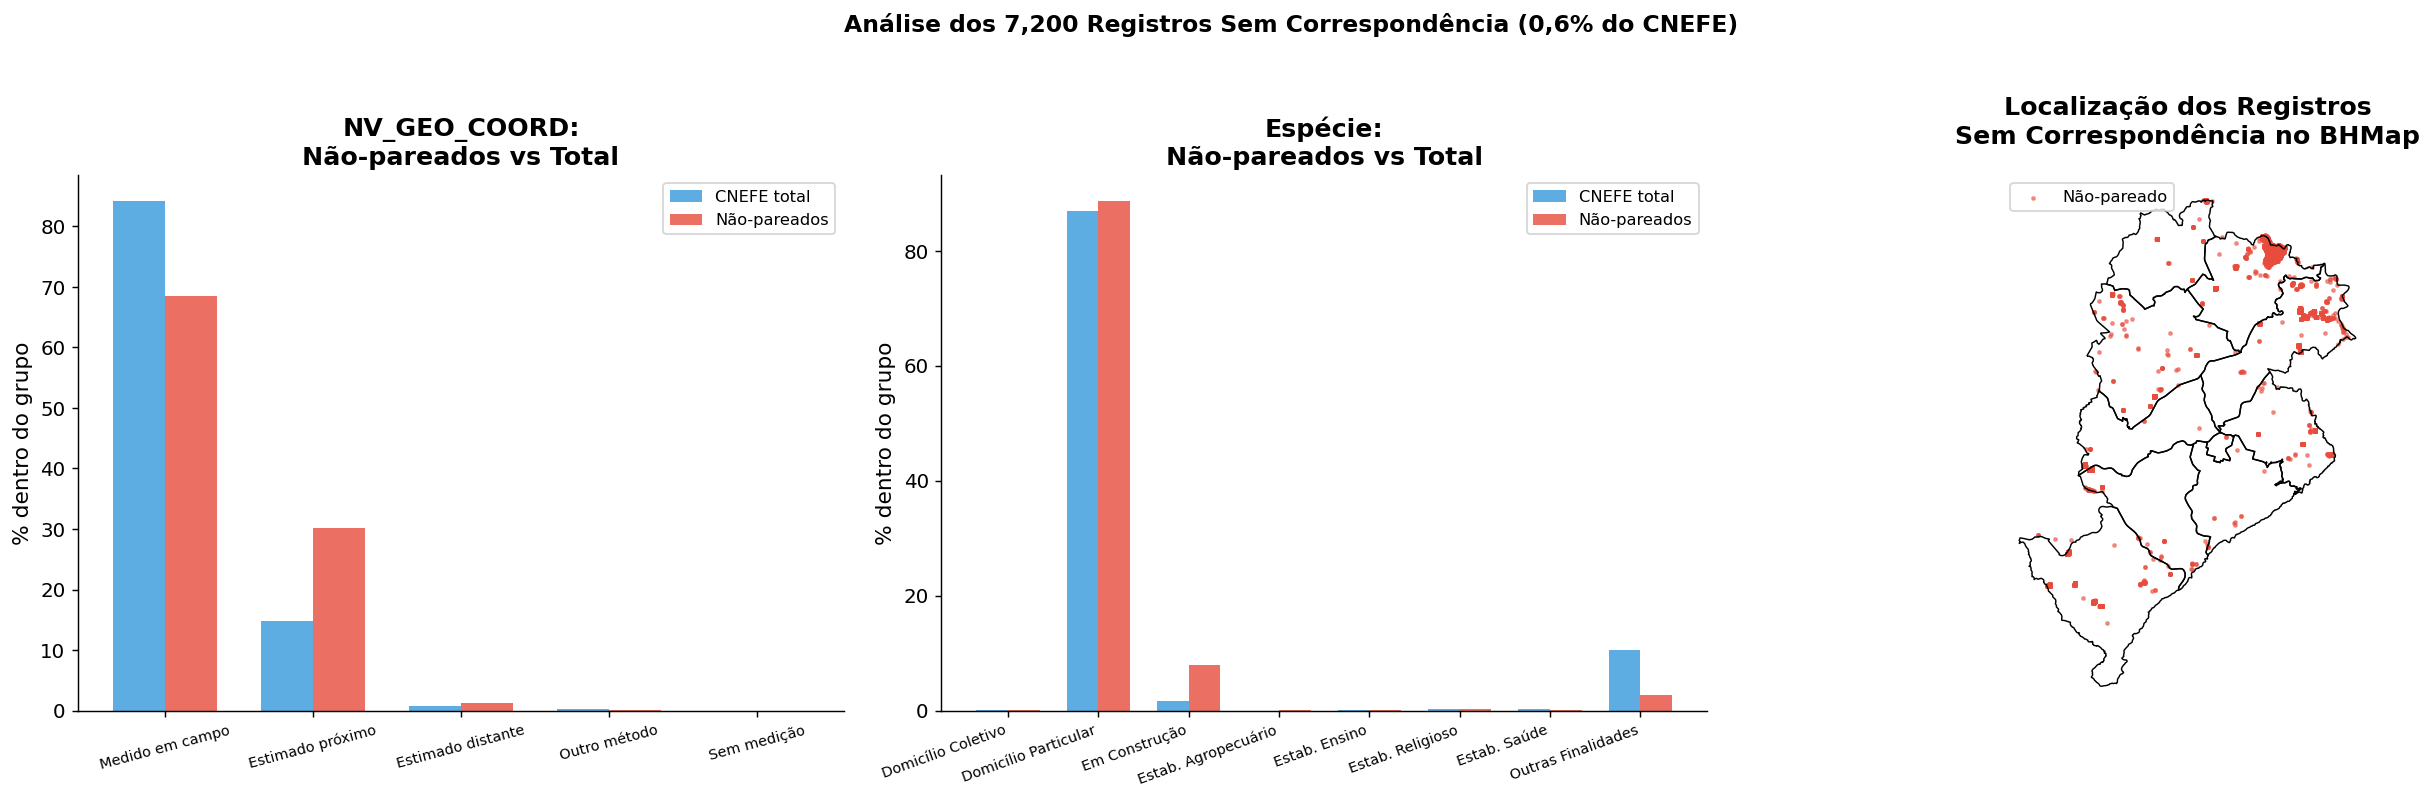

,% não-pareados
NOME_REGIO,
NORTE,2.28%
NORDESTE,1.33%
BARREIRO,0.84%
PAMPULHA,0.32%
NOROESTE,0.30%
LESTE,0.27%
VENDA NOVA,0.25%
OESTE,0.16%
CENTRO-SUL,0.01%



NV_GEO_COORD (não-pareados): {1: 68.5, 2: 30.1, 3: 1.2, 4: 0.2}
NV_GEO_COORD (total CNEFE): {1: 84.3, 2: 14.7, 3: 0.7, 4: 0.3, 6: 0.0}


In [13]:
# 3.3 Análise dos 7.200 registros sem correspondência no BHMap
unmatched_path = config.PROCESSED_DIR / 'cnefe_unmatched.parquet'
try:
    unmatched = gpd.read_parquet(unmatched_path)
    # Drop NOME_REGIO if present to avoid sjoin suffix conflict
    unmatched = unmatched.drop(columns=[c for c in ['NOME_REGIO'] if c in unmatched.columns])
    print(f"Registros não-pareados: {len(unmatched):,} ({len(unmatched)/len(cnefe)*100:.2f}% do CNEFE)")

    unmatched['especie_label'] = unmatched['COD_ESPECIE'].map(config.ESPECIE_MAP).fillna('Desconhecido')
    unmatched['nv_label'] = unmatched['NV_GEO_COORD'].map(config.NV_GEO_MAP).fillna('Desconhecido')

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Distribuição NV_GEO_COORD (não-pareados vs global)
    ax = axes[0]
    nv_unm = unmatched['NV_GEO_COORD'].value_counts(normalize=True).sort_index() * 100
    nv_all = cnefe['NV_GEO_COORD'].value_counts(normalize=True).sort_index() * 100
    x = np.arange(len(nv_all))
    width = 0.35
    ax.bar(x - width/2, nv_all.values, width, label='CNEFE total', color='#3498db', alpha=0.8)
    ax.bar(x + width/2, [nv_unm.get(k, 0) for k in nv_all.index], width,
           label='Não-pareados', color='#e74c3c', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([config.NV_GEO_MAP.get(k, str(k)) for k in nv_all.index], rotation=15, fontsize=8)
    ax.set_ylabel('% dentro do grupo')
    ax.set_title('NV_GEO_COORD:\nNão-pareados vs Total', fontweight='bold')
    ax.legend(fontsize=9)

    # Distribuição por espécie
    ax = axes[1]
    esp_unm = unmatched['especie_label'].value_counts(normalize=True) * 100
    esp_all = cnefe['especie_label'].value_counts(normalize=True) * 100
    all_esp = sorted(set(esp_unm.index) | set(esp_all.index))
    x2 = np.arange(len(all_esp))
    ax.bar(x2 - width/2, [esp_all.get(e, 0) for e in all_esp], width,
           label='CNEFE total', color='#3498db', alpha=0.8)
    ax.bar(x2 + width/2, [esp_unm.get(e, 0) for e in all_esp], width,
           label='Não-pareados', color='#e74c3c', alpha=0.8)
    ax.set_xticks(x2)
    ax.set_xticklabels(all_esp, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('% dentro do grupo')
    ax.set_title('Espécie:\nNão-pareados vs Total', fontweight='bold')
    ax.legend(fontsize=9)

    # Mapa espacial dos não-pareados
    ax = axes[2]
    regionais_proj_unm = regionais.to_crs(config.TARGET_CRS)
    regionais_proj_unm.boundary.plot(ax=ax, color='black', linewidth=0.8)
    unmatched.to_crs(config.TARGET_CRS).plot(ax=ax, color='#e74c3c', markersize=3,
                                               alpha=0.5, label='Não-pareado')
    ax.set_title('Localização dos Registros\nSem Correspondência no BHMap', fontweight='bold')
    ax.axis('off')
    ax.legend(fontsize=9)

    plt.suptitle(f'Análise dos {len(unmatched):,} Registros Sem Correspondência (0,6% do CNEFE)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb03_unmatched_analysis.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Distribuição por regional
    _unmatched_crs = unmatched.to_crs(config.TARGET_CRS)
    unm_reg = gpd.sjoin(_unmatched_crs, regionais_proj[['NOME_REGIO', 'geometry']],
                         how='left', predicate='within')
    unm_reg_count = unm_reg['NOME_REGIO'].value_counts()
    cnefe_reg_count = cnefe_reg['NOME_REGIO'].value_counts()
    pct_unm_por_reg = (unm_reg_count / cnefe_reg_count * 100).sort_values(ascending=False)

    unm_display = pd.DataFrame({'% não-pareados': pct_unm_por_reg.round(2)})
    display(unm_display.style
        .background_gradient(cmap='OrRd', vmin=0, vmax=pct_unm_por_reg.max())
        .format('{:.2f}%')
        .set_caption('% de registros CNEFE não-pareados com BHMap por regional'))

    print(f"\nNV_GEO_COORD (não-pareados): {nv_unm.round(1).to_dict()}")
    print(f"NV_GEO_COORD (total CNEFE): {nv_all.round(1).to_dict()}")

except FileNotFoundError:
    print(f"Arquivo não encontrado: {unmatched_path}")
    print("Execute scripts/fix_pipeline.py para gerar cnefe_unmatched.parquet")

0,6% dos 1,18M registros CNEFE sem correspondência BHMap. A concentração geográfica é mais informativa do que o volume: esses registros localizam-se em bordas de expansão urbana recente e em vilas onde o BHMap ainda não mapeou logradouros formais.

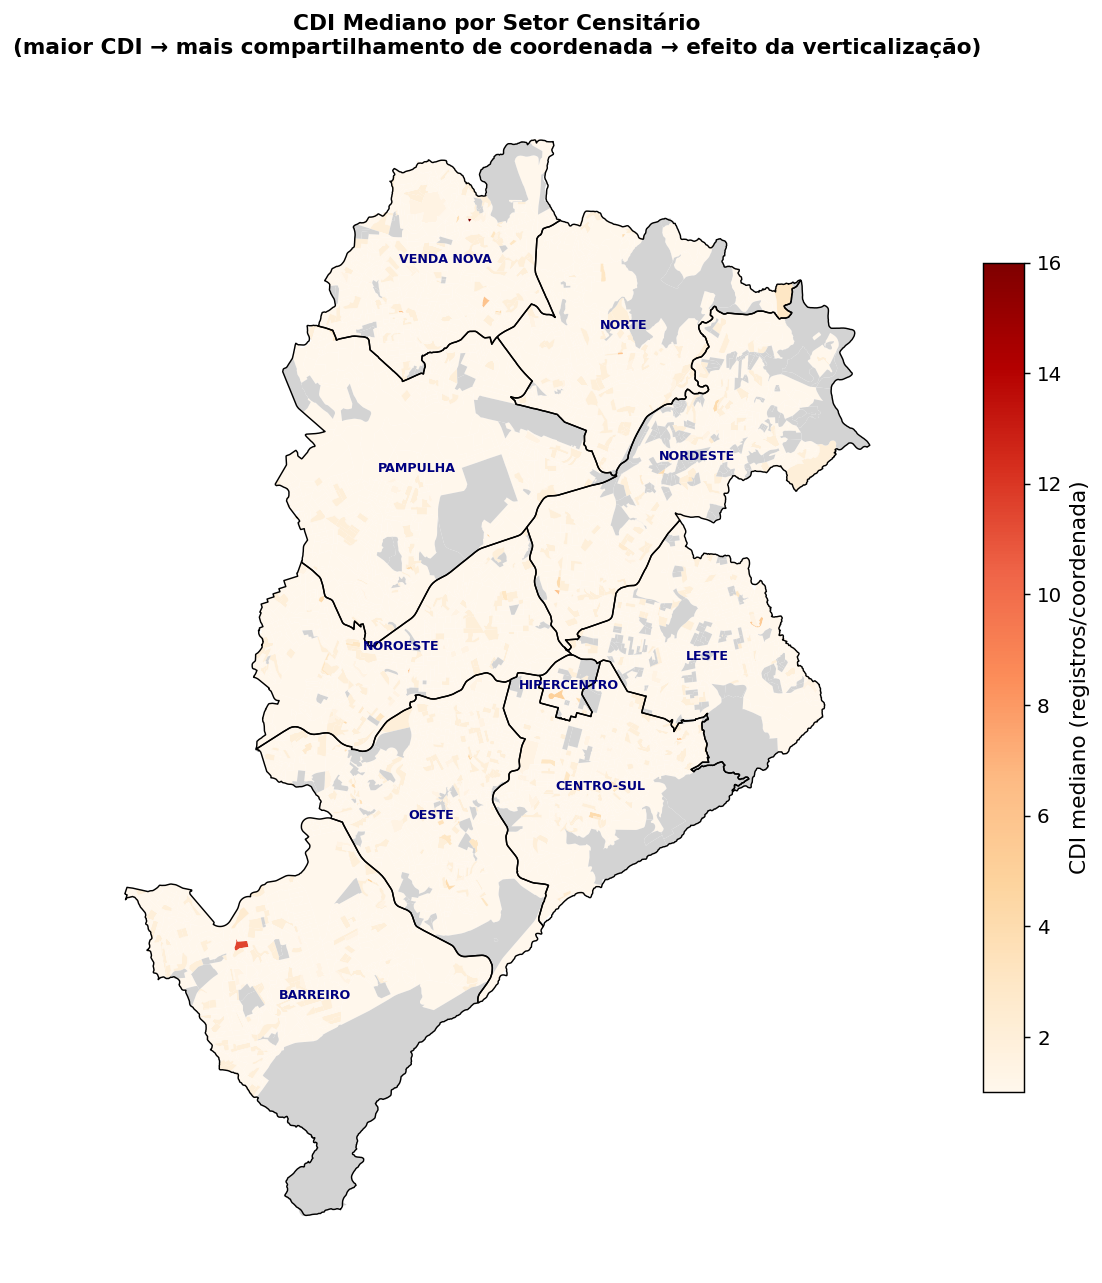

In [14]:
# 4.3 Mapa: CDI mediano por setor censitário (efeito da verticalização)
cdi_setor_df = metrics[['COD_SETOR']].join(coord_m[['cdi']], how='left')
cdi_by_setor = cdi_setor_df.groupby('COD_SETOR').agg(
    cdi_mediana=('cdi', 'median'),
    n=('cdi', 'count')
).reset_index()
cdi_by_setor['COD_SETOR_norm'] = cdi_by_setor['COD_SETOR'].str.rstrip('P').str.rstrip('S')

setores_cdi = setores.merge(cdi_by_setor[['COD_SETOR_norm', 'cdi_mediana']],
                             left_on='COD_SETOR', right_on='COD_SETOR_norm', how='left')

fig, ax = plt.subplots(figsize=(12, 10))
setores_cdi.plot(column='cdi_mediana', cmap='OrRd', legend=True, ax=ax,
                  missing_kwds={'color': 'lightgray'},
                  legend_kwds={'label': 'CDI mediano (registros/coordenada)', 'shrink': 0.7})
regionais_proj.boundary.plot(ax=ax, color='black', linewidth=0.8)
# Rótulo das regionais
for _, row in regionais_proj.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row['NOME_REGIO'], fontsize=7,
            ha='center', va='center', color='navy', fontweight='bold')
ax.set_title('CDI Mediano por Setor Censitário\n(maior CDI → mais compartilhamento de coordenada → efeito da verticalização)',
             fontweight='bold', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_mapa_cdi_setor.png', bbox_inches='tight', dpi=150)
plt.show()

Mapa de NV=1 por setor: heterogeneidade intra-regional evidente, mesmo dentro de uma regional com alto NV=1 médio, existem setores isolados com proporção mais baixa por verticalização localizada. CCR por setor: valores baixos coincidem com setores de fronteira entre regionais ou áreas de expansão. CDI por setor: concentração esperada no Hipercentro e eixos comerciais.

---
## 5. Síntese: Painel Comparativo das Métricas de Coordenada

In [15]:
# Agregar métricas de coordenada por regional e salvar CSV para o painel síntese
_reg_coord = cnefe_reg[["NOME_REGIO"]].join(
    coord_m[["cdi", "ccr", "drs", "pci_empirico"]], how="left"
)
coord_summary = _reg_coord.groupby("NOME_REGIO").agg(
    cdi_mediana=("cdi", "median"),
    ccr_pct=("ccr", "mean"),
    drs_mediana=("drs", "median"),
    pci_emp_media=("pci_empirico", "mean"),
).sort_values("cdi_mediana", ascending=False)
coord_summary.to_csv(config.TAB_DIR / "coordinate_metrics_summary.csv")
print(f"coordinate_metrics_summary.csv salvo: {len(coord_summary)} regionais")

coordinate_metrics_summary.csv salvo: 10 regionais


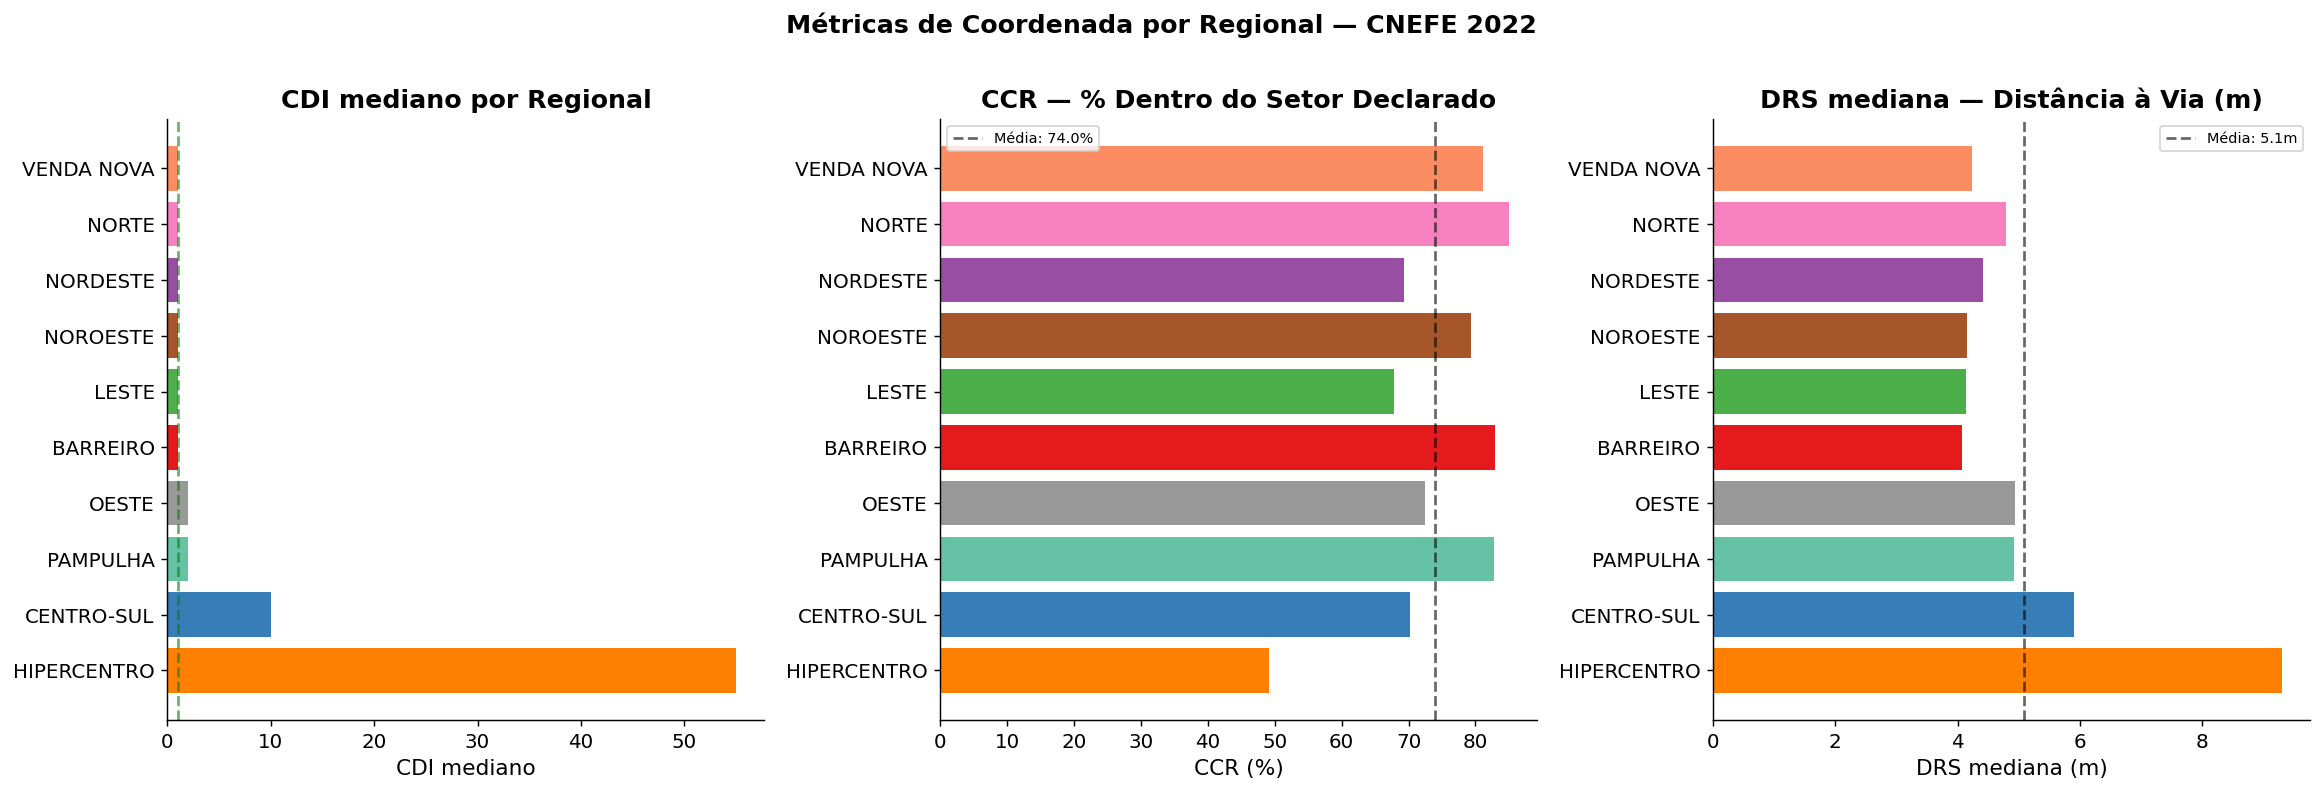

,cdi_mediana,ccr_pct,drs_mediana,pci_emp_media
NOME_REGIO,,,,
HIPERCENTRO,55.0,0.491,9.3,0.211
CENTRO-SUL,10.0,0.702,5.9,0.348
PAMPULHA,2.0,0.827,4.9,0.552
OESTE,2.0,0.724,4.9,0.523
BARREIRO,1.0,0.830,4.1,0.796
LESTE,1.0,0.679,4.1,0.669
NOROESTE,1.0,0.793,4.2,0.685
NORDESTE,1.0,0.693,4.4,0.692
NORTE,1.0,0.850,4.8,0.786


In [16]:

# 5.1 Painel síntese: CDI, CCR, DRS por regional
coord_summary = pd.read_csv(config.TAB_DIR / 'coordinate_metrics_summary.csv', index_col='NOME_REGIO')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
regs = coord_summary.index.tolist()
colors = [PALETA_REGIONAL.get(r, '#aaaaaa') for r in regs]

# CDI mediano
ax = axes[0]
ax.barh(regs, coord_summary['cdi_mediana'], color=colors)
ax.set_title('CDI mediano por Regional', fontweight='bold')
ax.set_xlabel('CDI mediano')
ax.axvline(1, linestyle='--', color='green', alpha=0.6)

# CCR
ax = axes[1]
ax.barh(regs, coord_summary['ccr_pct']*100, color=colors)
ax.set_title('CCR — % Dentro do Setor Declarado', fontweight='bold')
ax.set_xlabel('CCR (%)')
ax.axvline(coord_summary['ccr_pct'].mean()*100, linestyle='--', color='black',
           alpha=0.6, label=f'Média: {coord_summary["ccr_pct"].mean()*100:.1f}%')
ax.legend(fontsize=8)

# DRS
ax = axes[2]
ax.barh(regs, coord_summary['drs_mediana'], color=colors)
ax.set_title('DRS mediana — Distância à Via (m)', fontweight='bold')
ax.set_xlabel('DRS mediana (m)')
ax.axvline(coord_summary['drs_mediana'].mean(), linestyle='--', color='black', alpha=0.6,
           label=f'Média: {coord_summary["drs_mediana"].mean():.1f}m')
ax.legend(fontsize=8)

plt.suptitle('Métricas de Coordenada por Regional — CNEFE 2022', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_painel_coord_metrics.png', bbox_inches='tight')
plt.show()

# Tabela pandas estilizada
display(coord_summary[['cdi_mediana', 'ccr_pct', 'drs_mediana', 'pci_emp_media']].round(3).style
    .background_gradient(subset=['cdi_mediana'], cmap='OrRd')
    .background_gradient(subset=['ccr_pct'], cmap='RdYlGn')
    .background_gradient(subset=['drs_mediana'], cmap='OrRd_r')
    .background_gradient(subset=['pci_emp_media'], cmap='RdYlGn')
    .format({'cdi_mediana': '{:.1f}', 'ccr_pct': '{:.3f}',
             'drs_mediana': '{:.1f}', 'pci_emp_media': '{:.3f}'})
    .set_caption('Síntese de métricas de coordenada por regional'))

O painel 2×2 consolida CDI, CCR, DRS e NV_GEO por regional, permitindo identificar quais regionais acumulam múltiplos sinais de baixa qualidade simultaneamente, relevante para a C3 (viés socioespacial).

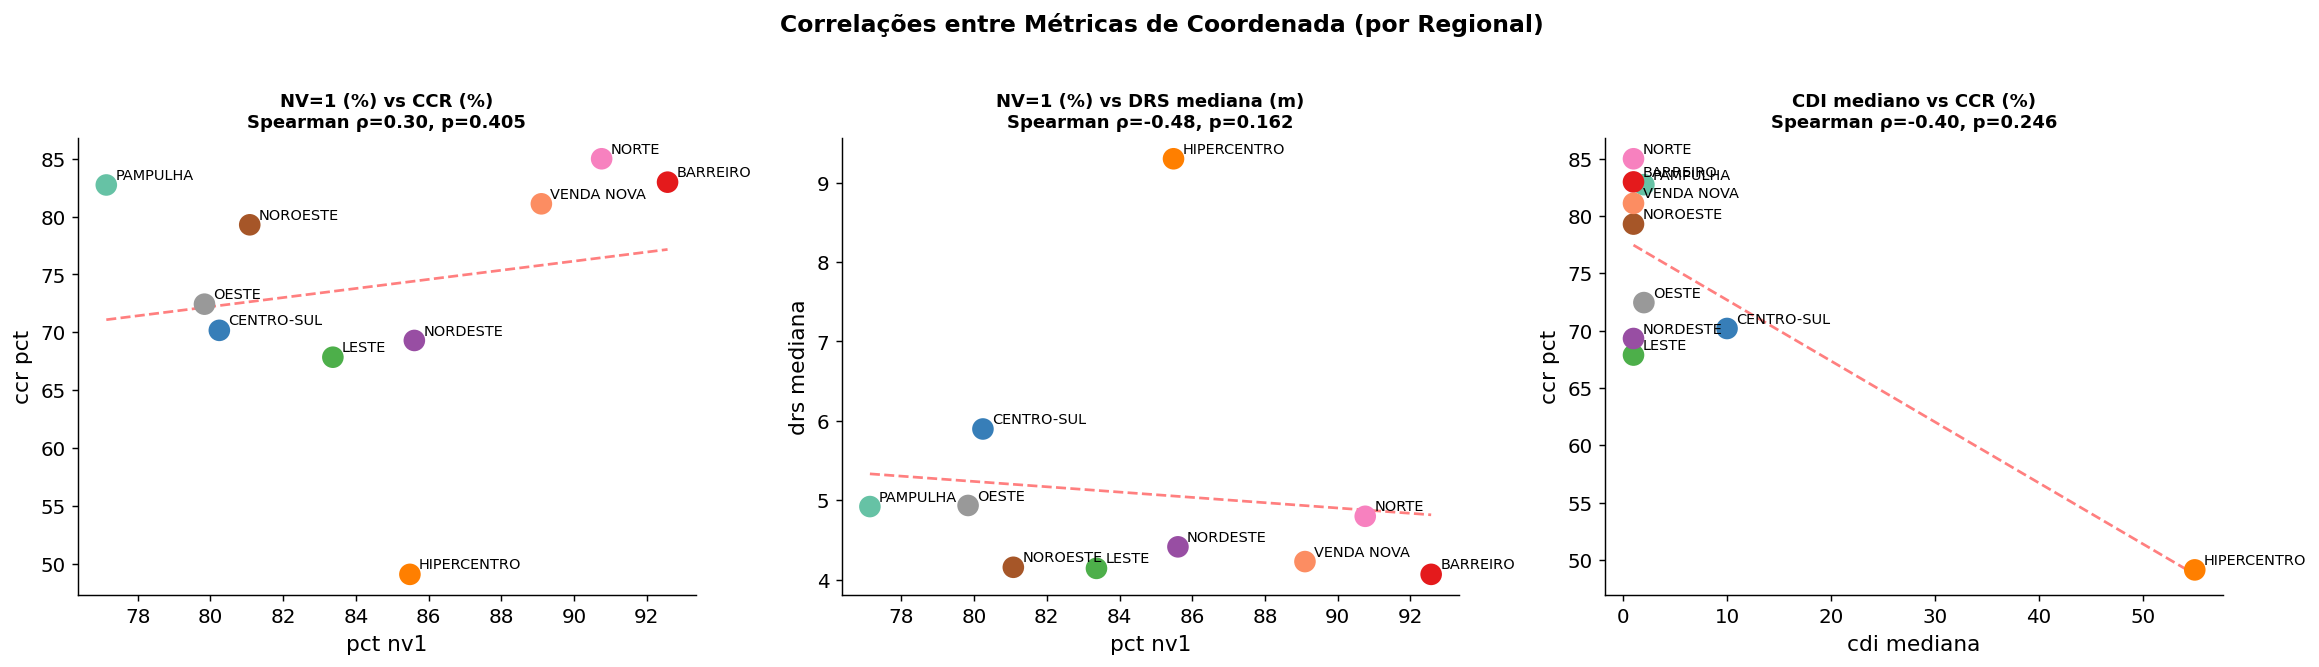

In [17]:
# 5.2 Correlação entre métricas de coordenada e NV_GEO_COORD
from scipy import stats

# Unir tudo por regional
nv1_reg = cnefe_reg.groupby('NOME_REGIO').apply(
    lambda g: (g['NV_GEO_COORD'] == 1).mean() * 100
).rename('pct_nv1')

analise = coord_summary.join(nv1_reg, how='inner')

pairs = [
    ('pct_nv1', 'ccr_pct', 'NV=1 (%) vs CCR (%)'),
    ('pct_nv1', 'drs_mediana', 'NV=1 (%) vs DRS mediana (m)'),
    ('cdi_mediana', 'ccr_pct', 'CDI mediano vs CCR (%)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x_col, y_col, title) in zip(axes, pairs):
    x = analise[x_col].values
    y = analise[y_col].values
    if y_col == 'ccr_pct':
        y = y * 100
    colors_scatter = [PALETA_REGIONAL.get(r, '#aaaaaa') for r in analise.index]
    ax.scatter(x, y, c=colors_scatter, s=120, zorder=3)
    for i, reg in enumerate(analise.index):
        ax.annotate(reg, (x[i], y[i]), textcoords='offset points',
                    xytext=(5, 3), fontsize=8)
    rho, pval = stats.spearmanr(x, y)
    ax.set_title(f'{title}\nSpearman ρ={rho:.2f}, p={pval:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel(x_col.replace('_', ' '))
    ax.set_ylabel(y_col.replace('_', ' '))
    # Linha de tendência
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(sorted(x), p(sorted(x)), 'r--', alpha=0.5)

plt.suptitle('Correlações entre Métricas de Coordenada (por Regional)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_correlacoes_coord_metrics.png', bbox_inches='tight')
plt.show()

Análise de correlação (Spearman) entre CDI, CCR, DRS e GCI_empírico. Correlações fortes entre métricas intrínsecas validam que medem aspectos relacionados da qualidade.

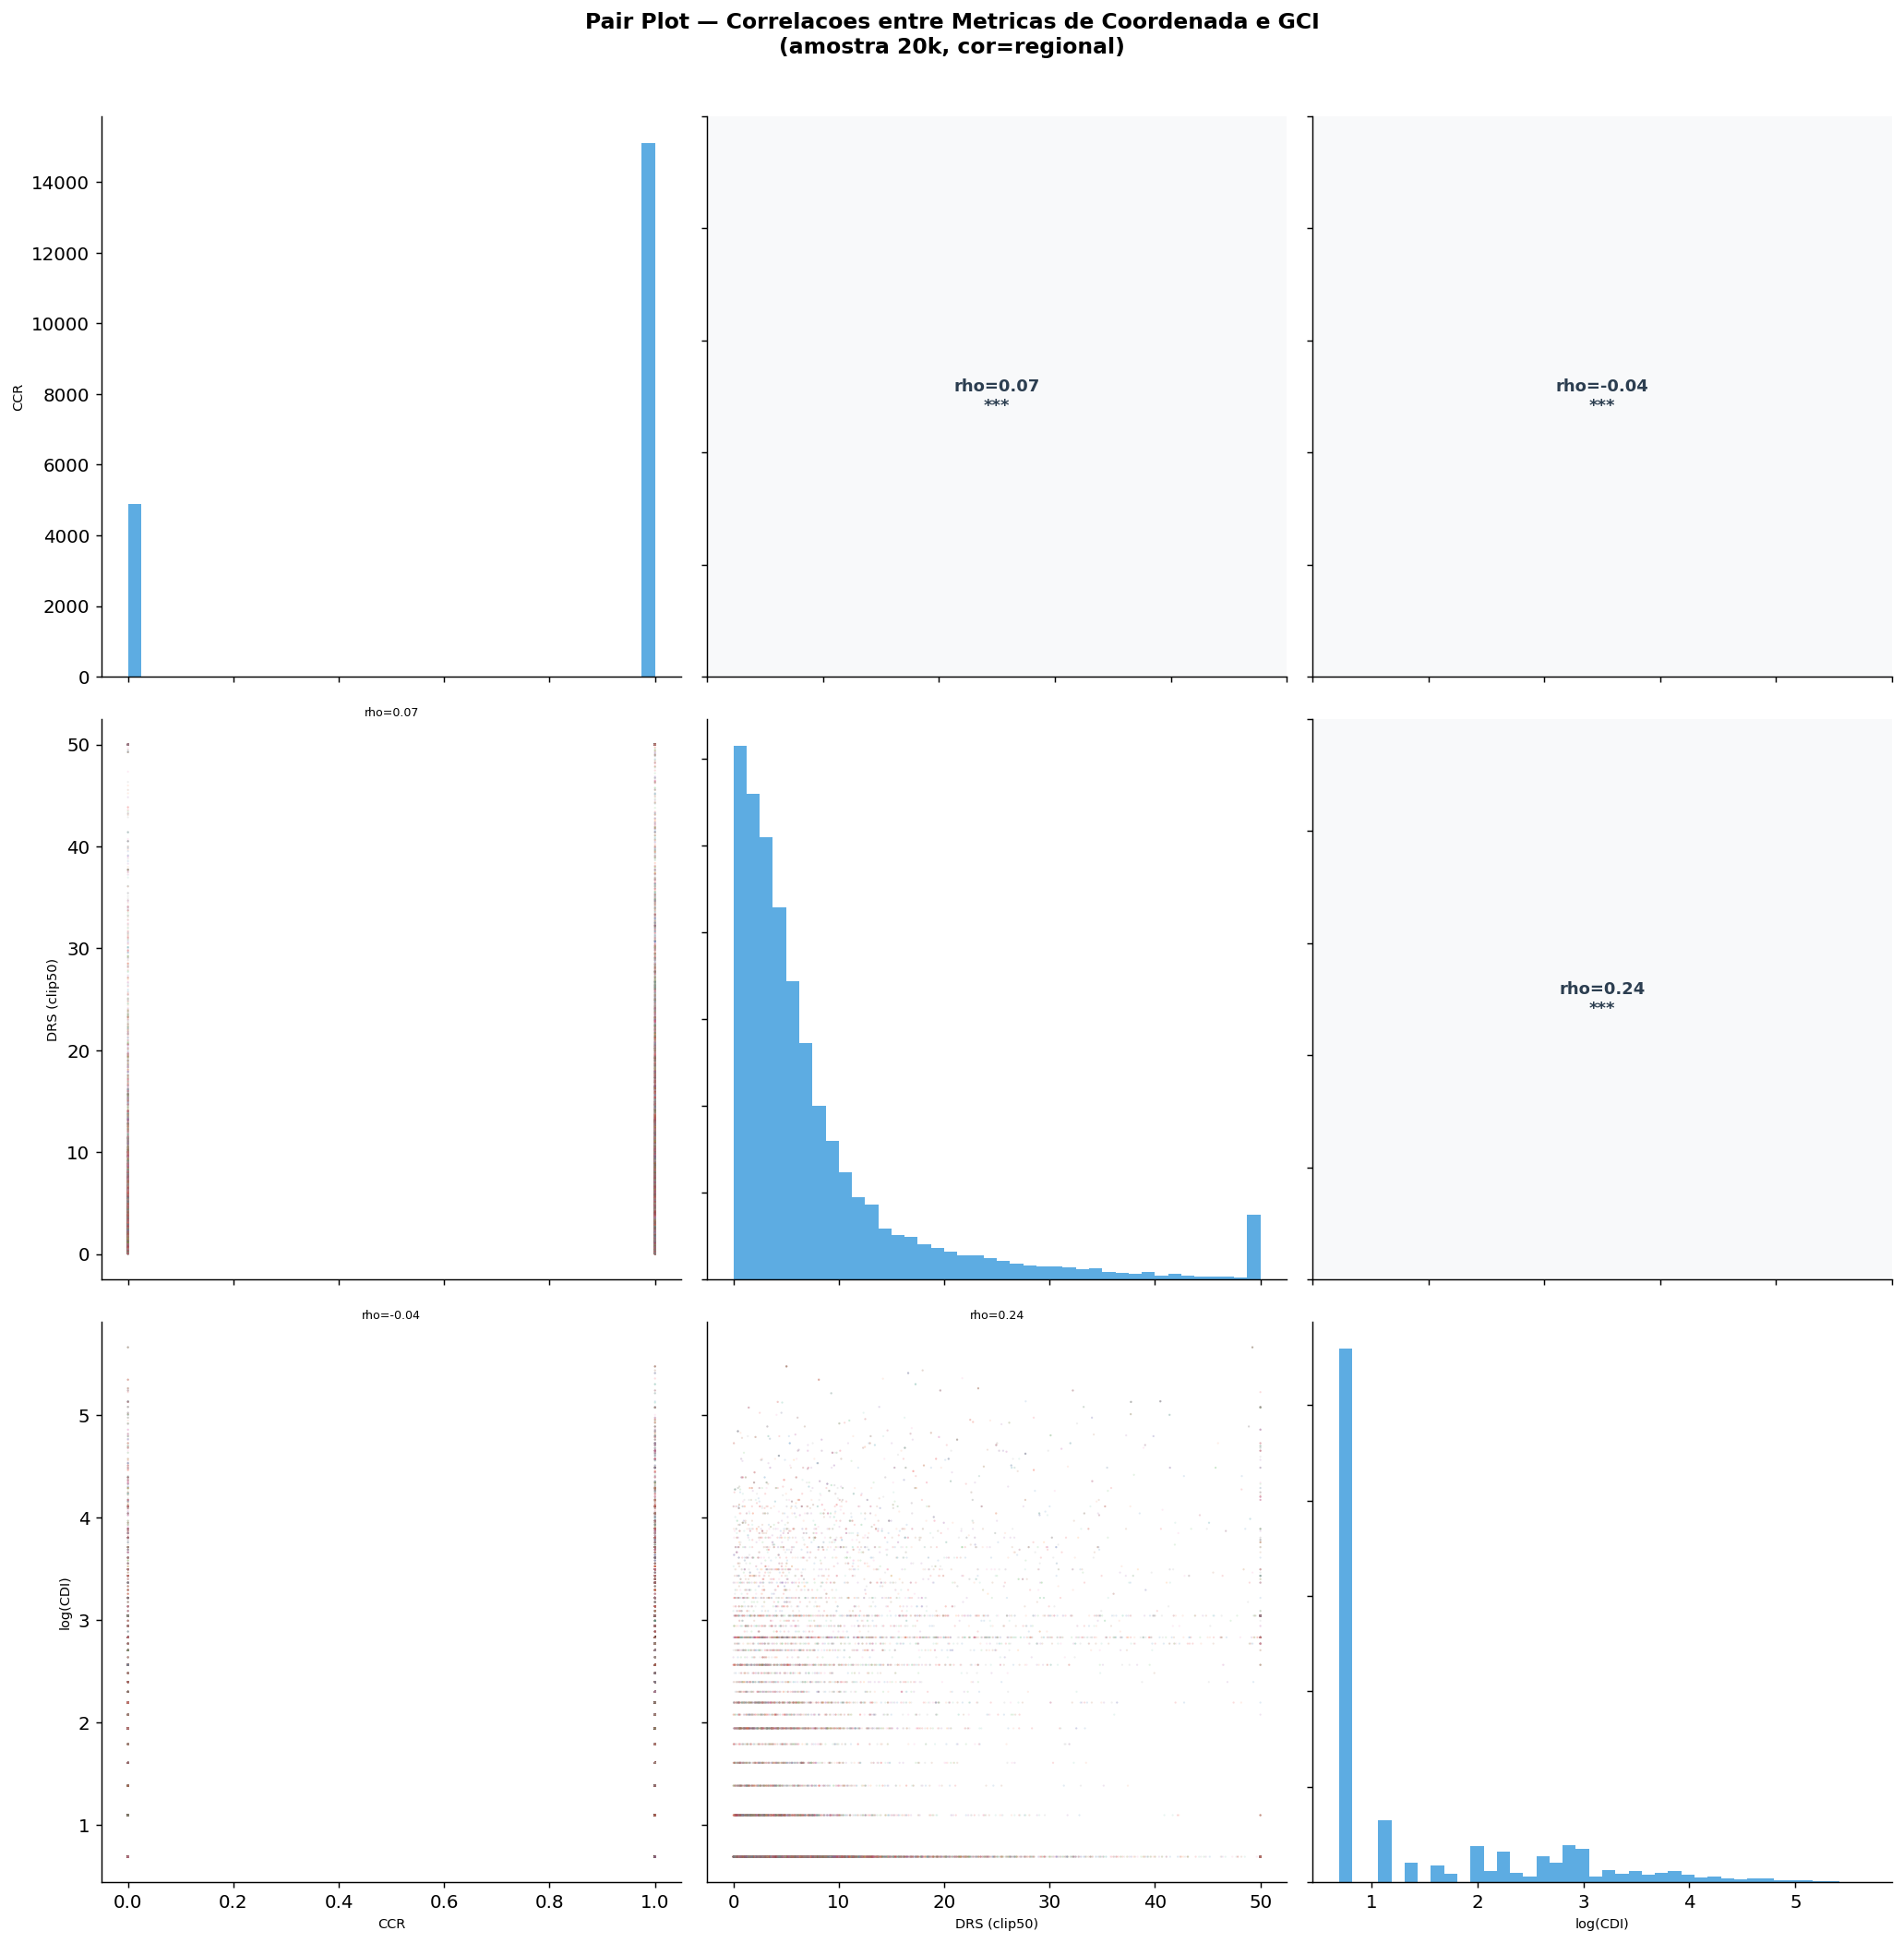

In [18]:
# Pair plot: correlacoes entre metricas de coordenada e GCI (amostra 20k)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

PALETA_PP = {
    'BARREIRO':'#e41a1c','CENTRO-SUL':'#377eb8','HIPERCENTRO':'#ff7f00',
    'LESTE':'#4daf4a','NORDESTE':'#984ea3','NOROESTE':'#a65628',
    'NORTE':'#f781bf','OESTE':'#999999','PAMPULHA':'#66c2a5','VENDA NOVA':'#fc8d62',
}

cols_base = ['LCI','ccr','drs','cdi','GCI_original','GCI_empirico']
cols_avail = [c for c in cols_base if c in metrics.columns]
extra = ['NOME_REGIO'] if 'NOME_REGIO' in metrics.columns else []
sample = metrics[cols_avail + extra].dropna().sample(min(20000, len(metrics)), random_state=42)
sample = sample.copy()
if 'drs' in sample.columns: sample['drs_clip'] = sample['drs'].clip(upper=50)
if 'cdi' in sample.columns: sample['cdi_log'] = np.log1p(sample['cdi'])

cols_plot = [c for c in ['LCI','ccr','drs_clip','cdi_log','GCI_original','GCI_empirico']
             if c in sample.columns]
labels_plot = {'LCI':'LCI','ccr':'CCR','drs_clip':'DRS (clip50)','cdi_log':'log(CDI)',
               'GCI_original':'GCI orig','GCI_empirico':'GCI emp'}
n = len(cols_plot)
if 'NOME_REGIO' in sample.columns:
    colors_pt = [PALETA_PP.get(r,'#aaa') for r in sample['NOME_REGIO']]
else:
    colors_pt = ['#3498db'] * len(sample)

fig, axes = plt.subplots(n, n, figsize=(16, 16))
for i, ci in enumerate(cols_plot):
    for j, cj in enumerate(cols_plot):
        ax = axes[i][j]
        if i == j:
            ax.hist(sample[ci].dropna(), bins=40, color='#3498db', alpha=0.8, edgecolor='none')
        elif i > j:
            ax.scatter(sample[cj], sample[ci], c=colors_pt, s=1.5, alpha=0.15, linewidths=0)
            rho, _ = stats.spearmanr(sample[ci].dropna(), sample[cj].dropna())
            ax.set_title(f'rho={rho:.2f}', fontsize=7, pad=1)
        else:
            rho, pval = stats.spearmanr(sample[ci].dropna(), sample[cj].dropna())
            star = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns'
            ax.text(0.5, 0.5, f'rho={rho:.2f}\n{star}',
                    transform=ax.transAxes, ha='center', va='center', fontsize=10,
                    fontweight='bold', color='#e74c3c' if abs(rho)>0.5 else '#2c3e50')
            ax.set_facecolor('#f8f9fa')
        if i == n-1: ax.set_xlabel(labels_plot.get(cj, cj), fontsize=8)
        else: ax.set_xticklabels([])
        if j == 0: ax.set_ylabel(labels_plot.get(ci, ci), fontsize=8)
        else: ax.set_yticklabels([])

plt.suptitle('Pair Plot — Correlacoes entre Metricas de Coordenada e GCI\n'
             '(amostra 20k, cor=regional)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_pair_plot_coord_metrics.png', bbox_inches='tight')
plt.show()

O pair plot visualiza todas as relações bivariadas entre métricas. CDI alto deve correlacionar negativamente com GCI_empírico (ρ < 0); CCR positivamente com GCI. Ausência de correlação entre LCI e DRS confirmaria validade discriminante.

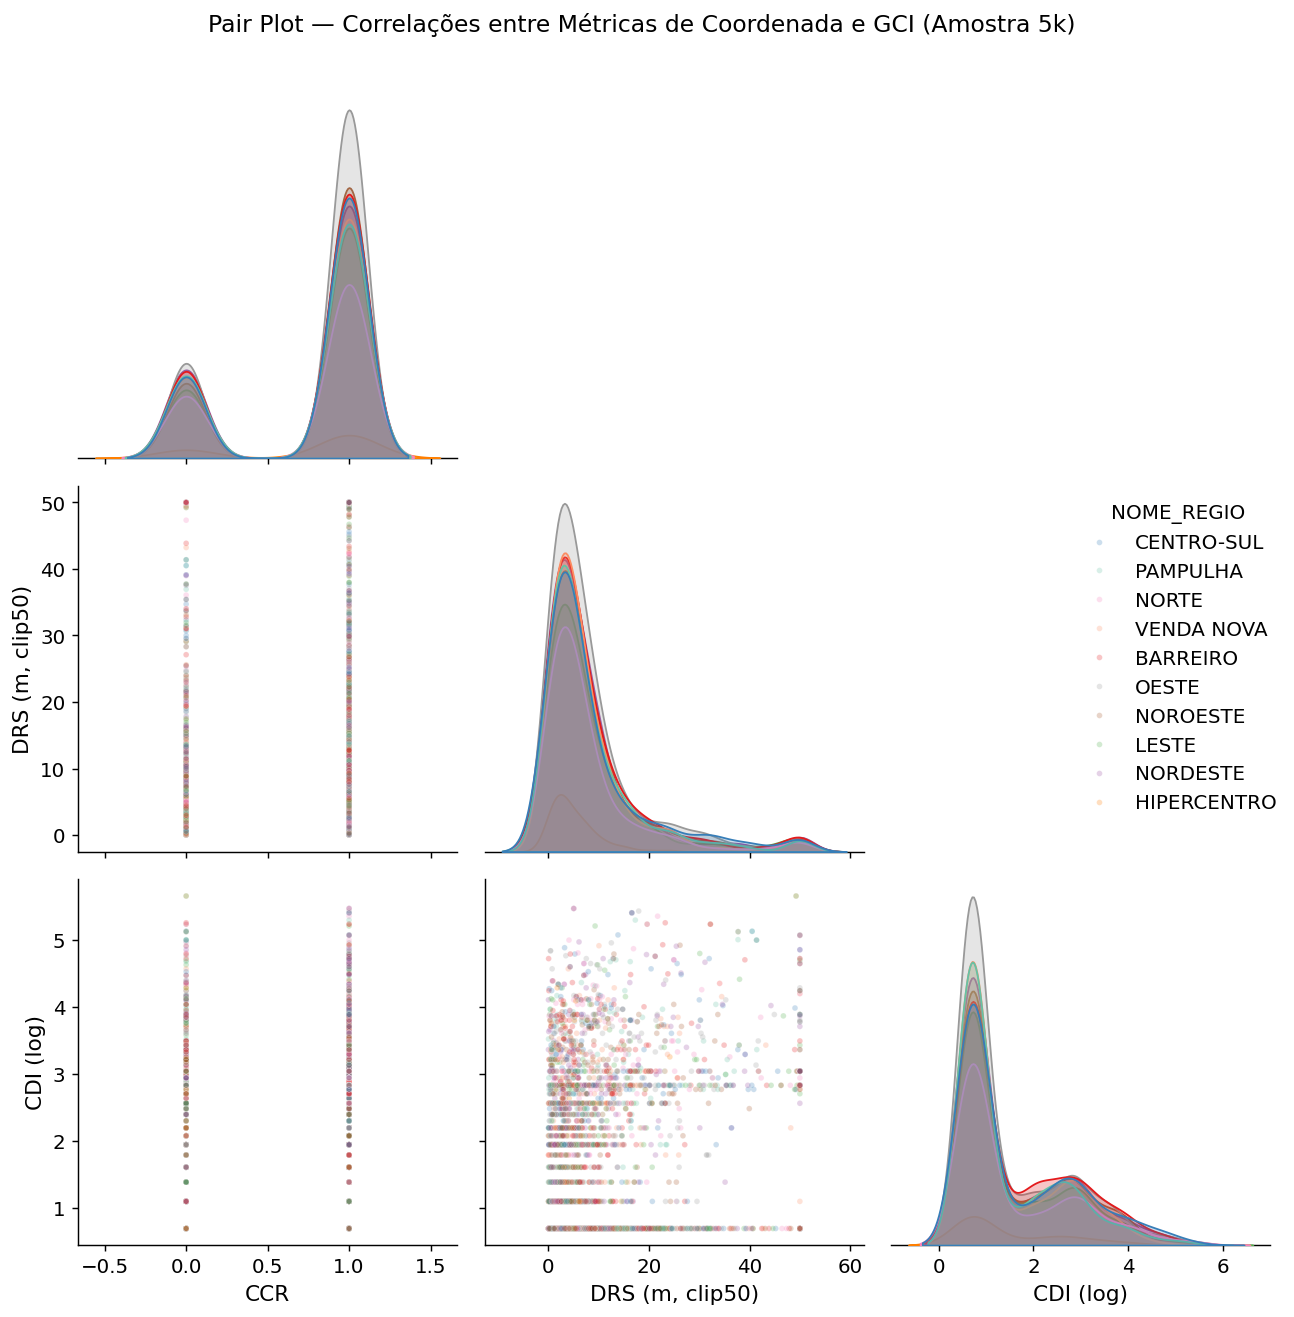

In [19]:
# Pair plot estático — correlações entre métricas de coordenada e GCI
cols_base = ['LCI', 'ccr', 'drs', 'cdi', 'GCI_original', 'GCI_empirico']
cols_avail = [c for c in cols_base if c in metrics.columns]
extra = ['NOME_REGIO'] if 'NOME_REGIO' in metrics.columns else []
sample = metrics[cols_avail + extra].dropna().sample(min(5000, len(metrics)), random_state=42).copy()

if 'drs' in sample.columns:
    sample['DRS (m, clip50)'] = sample['drs'].clip(upper=50)
    sample.drop(columns=['drs'], inplace=True)
if 'cdi' in sample.columns:
    sample['CDI (log)'] = np.log1p(sample['cdi'])
    sample.drop(columns=['cdi'], inplace=True)
sample = sample.rename(columns={'ccr': 'CCR', 'GCI_original': 'GCI orig', 'GCI_empirico': 'GCI emp'})

paleta = {
    'BARREIRO':'#e41a1c','CENTRO-SUL':'#377eb8','HIPERCENTRO':'#ff7f00',
    'LESTE':'#4daf4a','NORDESTE':'#984ea3','NOROESTE':'#a65628',
    'NORTE':'#f781bf','OESTE':'#999999','PAMPULHA':'#66c2a5','VENDA NOVA':'#fc8d62',
}

dimensions = [c for c in ['LCI', 'CCR', 'DRS (m, clip50)', 'CDI (log)', 'GCI orig', 'GCI emp']
              if c in sample.columns]

hue = 'NOME_REGIO' if 'NOME_REGIO' in sample.columns else None
palette = paleta if hue else None

pp = sns.pairplot(
    sample[dimensions + ([hue] if hue else [])],
    hue=hue, palette=palette,
    diag_kind='kde', plot_kws={'alpha': 0.25, 's': 10},
    corner=True,
)
pp.fig.suptitle('Pair Plot — Correlações entre Métricas de Coordenada e GCI (Amostra 5k)',
                y=1.01, fontsize=13)
pp.fig.set_size_inches(10, 10)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_pair_plot_interativo.png', dpi=180, bbox_inches='tight')
plt.show()


CDI × GCI_empírico: correlação fortemente negativa (ρ < 0), definitória, dado que PCI_emp = 1/CDI. CCR × GCI: correlação positiva moderada, coordenadas dentro do setor correto tendem a ter GCI mais alto. LCI × DRS: correlação fraca ou ausente, confirmando validade discriminante, os dois componentes medem dimensões distintas de qualidade.

---
## Sintese Intermediaria: EDA das Metricas de Coordenada (Secoes 1-5)

| Dimensão | Achado | Implicação |
|---|---|---|
| **CDI** | Hipercentro CDI mediano=55; Barreiro=1 | Verticalização gera coordenadas compartilhadas em massa, base empírica para PCI_empirico |
| **CCR** | 24,1% dos pontos fora do setor declarado; Hipercentro apenas 49,2% correto | Erro topológico independente do NV_GEO_COORD, concentrado em áreas densas |
| **DRS** | Mediana 4,6m; 98,1% dentro de 50m de uma via | Coordenadas aderentes ao sistema viário, boa qualidade posicional intrínseca |
| **NV_GEO** | 84,4% NV=1 global, mas distribuição heterogênea entre regionais | Regionais periféricas têm mais GPS de campo; centrais mais estimativas |
| **Completude** | CEP e número de endereço com alta completude; COMPLEMENTO ausente em ~40% | Campos de endereço básicos completos, mas identificação de unidade limitada |
| **Cobertura BHMap** | BHMap existente cobre ~44% dos endereços CNEFE por regional | Subcobertura do padrão-ouro concentrada em periferias (vilas/favelas) |


---
## 6. EDA das Camadas de Contexto BHMap

Sete camadas contextuais foram incorporadas ao projeto (processadas por `scripts/process_context_layers.py`):

| Camada | Arquivo | Registros | Tipo |
|---|---|---|---|
| Edificações | `edificacao.parquet` | ~250k polígonos | Vetor polígono |
| Áreas de risco | `area_risco.parquet` | 2 tipos dissolvidos | Vetor polígono |
| IVS | `ivs.parquet` | 5.166 setores | Vetor polígono |
| Lotes CTM + tipologia | `lote_ctm.parquet` | ~370k lotes | Vetor polígono |
| Bairros populares | `bairro_popular.parquet` | 493 bairros | Vetor polígono |
| Cadastro, unidades | `cadastro_units.parquet` | ~897k unidades | Tabela |
| Cadastro, lotes | `cadastro_lotes.parquet` | ~306k lotes | Vetor polígono |

**Objetivo:** caracterizar cada camada, verificar consistência geométrica e geográfica, identificar distribuições e outliers, e alinhar cada variável com as hipóteses de pesquisa.

In [20]:
# Carregar todas as camadas de contexto processadas
import warnings
warnings.filterwarnings('ignore')

edificacao   = gpd.read_parquet(config.EDIFICACAO_PARQUET)
area_risco   = gpd.read_parquet(config.AREA_RISCO_PARQUET)
ivs          = gpd.read_parquet(config.IVS_PARQUET)
lote_ctm     = gpd.read_parquet(config.LOTE_CTM_PARQUET)
bairro_pop   = gpd.read_parquet(config.BAIRRO_POPULAR_PARQUET)
cad_units    = pd.read_parquet(config.CADASTRO_UNITS_PARQUET)
cad_lotes    = gpd.read_parquet(config.CADASTRO_LOTES_PARQUET)

# Reprojetar tudo para CRS métrico
for name, gdf in [('edificacao', edificacao), ('area_risco', area_risco),
                   ('ivs', ivs), ('lote_ctm', lote_ctm),
                   ('bairro_pop', bairro_pop), ('cad_lotes', cad_lotes)]:
    if gdf.crs and gdf.crs.to_epsg() != 31983:
        exec(f"{name} = {name}.to_crs('EPSG:31983')", globals())

# Sumário de carregamento
camadas = {
    'edificacao':   edificacao,
    'area_risco':   area_risco,
    'ivs':          ivs,
    'lote_ctm':     lote_ctm,
    'bairro_pop':   bairro_pop,
    'cad_lotes':    cad_lotes,
}
print(f"{'Camada':<20} {'N':>8}  {'CRS':<20}  {'Tipo geom':>15}")
print("-" * 70)
for name, gdf in camadas.items():
    crs_str = str(gdf.crs.to_epsg()) if gdf.crs else "sem CRS"
    geom_types = gdf.geometry.geom_type.value_counts().index[0]
    print(f"{name:<20} {len(gdf):>8,}  EPSG:{crs_str:<16}  {geom_types:>15}")
print(f"\ncad_units (tabela): {len(cad_units):,} unidades")

Camada                      N  CRS                         Tipo geom
----------------------------------------------------------------------
edificacao            739,354  EPSG:31983                     Polygon
area_risco                  2  EPSG:31983                MultiPolygon
ivs                     3,936  EPSG:31983                     Polygon
lote_ctm              365,444  EPSG:31983                     Polygon
bairro_pop                493  EPSG:31983                     Polygon


cad_lotes             306,352  EPSG:31983                MultiPolygon

cad_units (tabela): 896,964 unidades


### 6.1 Camada EDIFICACAO: Geometria, Alturas e Flags de Qualidade

**Hipótese H1 (CDI-Verticalização):** Edifícios com PAV_EST alto concentram-se no Hipercentro e Centro-Sul. O CDI alto nessas regionais é estruturalmente explicado pela densidade de edificações verticais, o IBGE coleta uma coordenada GPS por edifício e atribui a todos os apartamentos.

**Sanidade geométrica esperada:** polígonos sem buracos, área mínima ~10 m², sem auto-interseções.

=== EDIFICACAO — Sanidade geométrica ===
  Total edificações:       739,354
  Geometrias válidas:      739,354  (100.00%)
  Geometrias inválidas:    0
  Área calculada (m²) — mediana:  88.2
  Área calculada (m²) — P99:      709.0
  ALTURA_CAL < 0 (remanescentes): 0
  ALTURA_EST < 0 (remanescentes): 0
  FLAG_EM_CONSTRUCAO=1:    11,015  (1.49%)
  FLAG_ALTURA_IMPRECISA=1: 8,353  (1.13%)


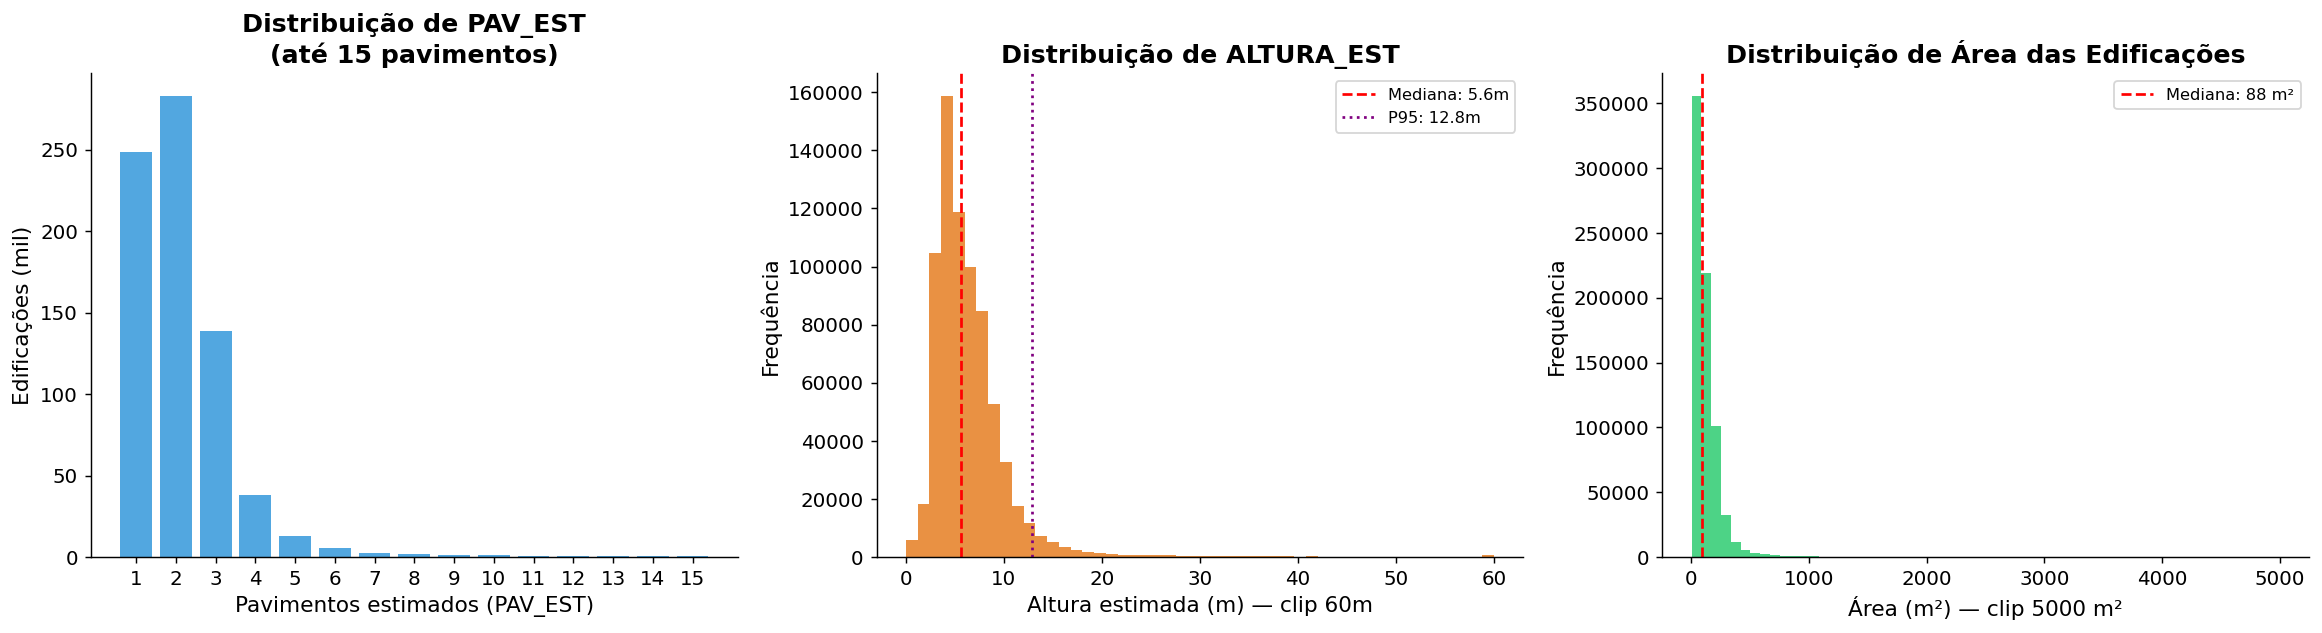

,count,mean,std,min,25%,50%,75%,max
ALTURA_CAL,739354.00,6.62,5.00,0.00,4.03,5.58,7.82,129.32
ALTURA_EST,739354.00,6.62,5.00,0.00,4.03,5.58,7.82,129.32
PAV_EST,739354.00,2.20,1.69,1.00,1.00,2.00,3.00,43.00
AREA_CALC,739354.00,125.54,318.00,0.72,42.32,88.19,157.06,112293.36


In [21]:
# 6.1a — Sanidade geométrica: área, validade, flags
edif = edificacao.copy()
edif['AREA_CALC'] = edif.geometry.area
edif['VALIDA']    = edif.geometry.is_valid
edif['VAZIA']     = edif.geometry.is_empty

print("=== EDIFICACAO — Sanidade geométrica ===")
print(f"  Total edificações:       {len(edif):,}")
print(f"  Geometrias válidas:      {edif['VALIDA'].sum():,}  ({edif['VALIDA'].mean()*100:.2f}%)")
print(f"  Geometrias inválidas:    {(~edif['VALIDA']).sum():,}")
print(f"  Área calculada (m²) — mediana:  {edif['AREA_CALC'].median():.1f}")
print(f"  Área calculada (m²) — P99:      {edif['AREA_CALC'].quantile(.99):.1f}")
print(f"  ALTURA_CAL < 0 (remanescentes): {(edif['ALTURA_CAL'] < 0).sum():,}")
print(f"  ALTURA_EST < 0 (remanescentes): {(edif['ALTURA_EST'] < 0).sum():,}")
if 'FLAG_EM_CONSTRUCAO' in edif.columns:
    print(f"  FLAG_EM_CONSTRUCAO=1:    {edif['FLAG_EM_CONSTRUCAO'].sum():,}  ({edif['FLAG_EM_CONSTRUCAO'].mean()*100:.2f}%)")
    print(f"  FLAG_ALTURA_IMPRECISA=1: {edif['FLAG_ALTURA_IMPRECISA'].sum():,}  ({edif['FLAG_ALTURA_IMPRECISA'].mean()*100:.2f}%)")

# Distribuição de PAV_EST e ALTURA_EST
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
pav_vc = edif['PAV_EST'].value_counts().sort_index().head(15)
ax.bar(pav_vc.index.astype(str), pav_vc.values / 1000, color='#3498db', alpha=0.85)
ax.set_xlabel('Pavimentos estimados (PAV_EST)')
ax.set_ylabel('Edificações (mil)')
ax.set_title('Distribuição de PAV_EST\n(até 15 pavimentos)', fontweight='bold')
ax.tick_params(axis='x', rotation=0)

ax = axes[1]
h = edif['ALTURA_EST'].clip(upper=60).dropna()
ax.hist(h, bins=50, color='#e67e22', alpha=0.85, edgecolor='none')
ax.axvline(h.median(), color='red', linestyle='--', label=f'Mediana: {h.median():.1f}m')
ax.axvline(h.quantile(.95), color='purple', linestyle=':', label=f'P95: {h.quantile(.95):.1f}m')
ax.set_xlabel('Altura estimada (m) — clip 60m')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de ALTURA_EST', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[2]
area_clip = edif['AREA_CALC'].clip(upper=5000).dropna()
ax.hist(area_clip, bins=60, color='#2ecc71', alpha=0.85, edgecolor='none')
ax.axvline(area_clip.median(), color='red', linestyle='--', label=f'Mediana: {area_clip.median():.0f} m²')
ax.set_xlabel('Área (m²) — clip 5000 m²')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Área das Edificações', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_edificacao_dist.png', bbox_inches='tight')
plt.show()

# Stats descritivas
cols_stat = [c for c in ['ALTURA_CAL','ALTURA_EST','PAV_EST','AREA_CALC'] if c in edif.columns]
display(edif[cols_stat].describe().T.style
    .background_gradient(cmap='Blues', axis=1)
    .format('{:.2f}')
    .set_caption('EDIFICACAO — estatísticas descritivas'))

Métricas de sanidade (área inválida, flags de construção) confirmam a qualidade dos polígonos BHMap usados para calcular PAV_EST (andares) e área construída.

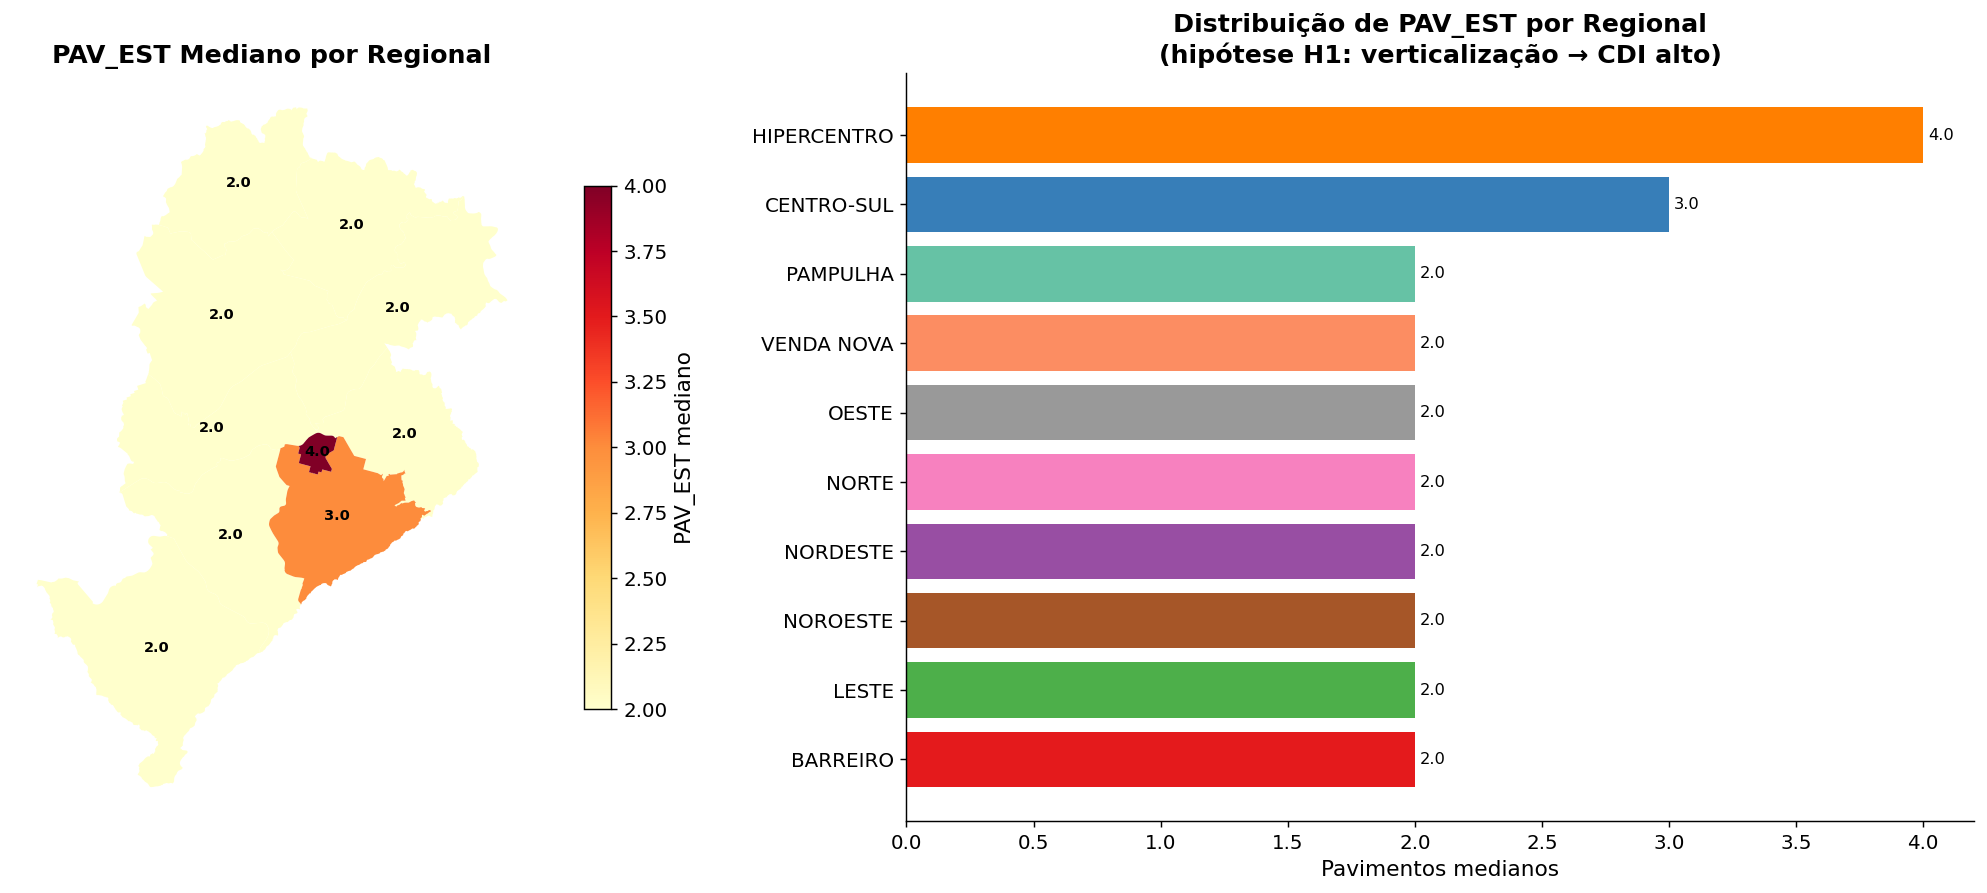

,PAV_mediana,PAV_media,PAV_max
NOME_REGIO,,,
HIPERCENTRO,4.00,6.80,42.00
CENTRO-SUL,3.00,3.53,43.00
BARREIRO,2.00,1.91,19.00
LESTE,2.00,2.12,37.00
NORDESTE,2.00,2.18,36.00
NOROESTE,2.00,2.07,23.00
NORTE,2.00,1.96,21.00
OESTE,2.00,2.41,32.00
PAMPULHA,2.00,2.09,27.00


In [22]:
# 6.1b — Mapa coroplético: PAV_EST mediano por regional
regionais_m = regionais.to_crs('EPSG:31983')

# Spatial join edificações × regionais (centroides para velocidade)
edif_centroid = edif.copy()
edif_centroid['geometry'] = edif.geometry.centroid
edif_reg = gpd.sjoin(edif_centroid[['PAV_EST','geometry']], regionais_m[['NOME_REGIO','geometry']],
                      how='left', predicate='within')
pav_by_reg = edif_reg.groupby('NOME_REGIO')['PAV_EST'].agg(['median','mean','max']).round(2)
pav_by_reg.columns = ['PAV_mediana','PAV_media','PAV_max']

regionais_plot = regionais_m.merge(pav_by_reg, on='NOME_REGIO', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
regionais_plot.plot(column='PAV_mediana', cmap='YlOrRd', legend=True, ax=ax,
                    legend_kwds={'label': 'PAV_EST mediano', 'shrink': 0.7})
for _, row in regionais_plot.iterrows():
    c = row.geometry.centroid
    val = row['PAV_mediana']
    if not pd.isna(val):
        ax.text(c.x, c.y, f'{val:.1f}', ha='center', va='center', fontsize=8, fontweight='bold')
ax.set_title('PAV_EST Mediano por Regional', fontweight='bold')
ax.axis('off')

ax = axes[1]
pav_sorted = pav_by_reg.sort_values('PAV_mediana', ascending=True)
colors = [PALETA_REGIONAL.get(r, '#aaa') for r in pav_sorted.index]
ax.barh(pav_sorted.index, pav_sorted['PAV_mediana'], color=colors)
ax.set_xlabel('Pavimentos medianos')
ax.set_title('Distribuição de PAV_EST por Regional\n(hipótese H1: verticalização → CDI alto)', fontweight='bold')
for i, (reg, row) in enumerate(pav_sorted.iterrows()):
    ax.text(row['PAV_mediana'] + 0.02, i, f'{row["PAV_mediana"]:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_edificacao_pav_regional.png', bbox_inches='tight')
plt.show()

display(pav_by_reg.sort_values('PAV_mediana', ascending=False).style
    .background_gradient(cmap='YlOrRd', subset=['PAV_mediana'])
    .background_gradient(cmap='YlOrRd', subset=['PAV_media'])
    .format('{:.2f}')
    .set_caption('Estatísticas de PAV_EST por Regional'))

PAV_EST mediano por regional quantifica a verticalidade de cada área. Regionais com PAV_EST alto (Hipercentro, Centro-Sul) correspondem a áreas onde o CDI deve ser alto e o GCI_empírico mais baixo.

### 6.2 Camada AREA_RISCO: Cobertura Territorial e Sobreposição com CNEFE

**Hipótese H2 (Qualidade em assentamentos informais):** Áreas de risco concentram domicílios precários onde o IBGE pode ter coletado coordenadas GPS estimadas (NV≥2), resultando em LCI baixo. A combinação `AREA_RISCO + IVS_SCORE alto` define um estrato de vulnerabilidade composta, espera-se GCI_empirico mais baixo nesse estrato.

**Sanidade:** verificar se os polígonos dissolvidos são válidos, cobrem frações plausíveis do território e se há sobreposição entre tipos de risco.

=== AREA_RISCO — Sanidade geométrica ===
  ESCORREGAMENTO: válido=True, área=29.61 km²  (8.9% de BH)
  INUNDACAO: válido=True, área=9.40 km²  (2.8% de BH)

  Sobreposição INUNDACAO ∩ ESCORREGAMENTO: 0.117 km²



  CNEFE em área de risco (qualquer tipo): 93,275 (7.9%)
    Sem risco: 1,086,827 (92.1%)
    ESCORREGAMENTO: 74,036 (6.3%)
    INUNDACAO: 19,239 (1.6%)


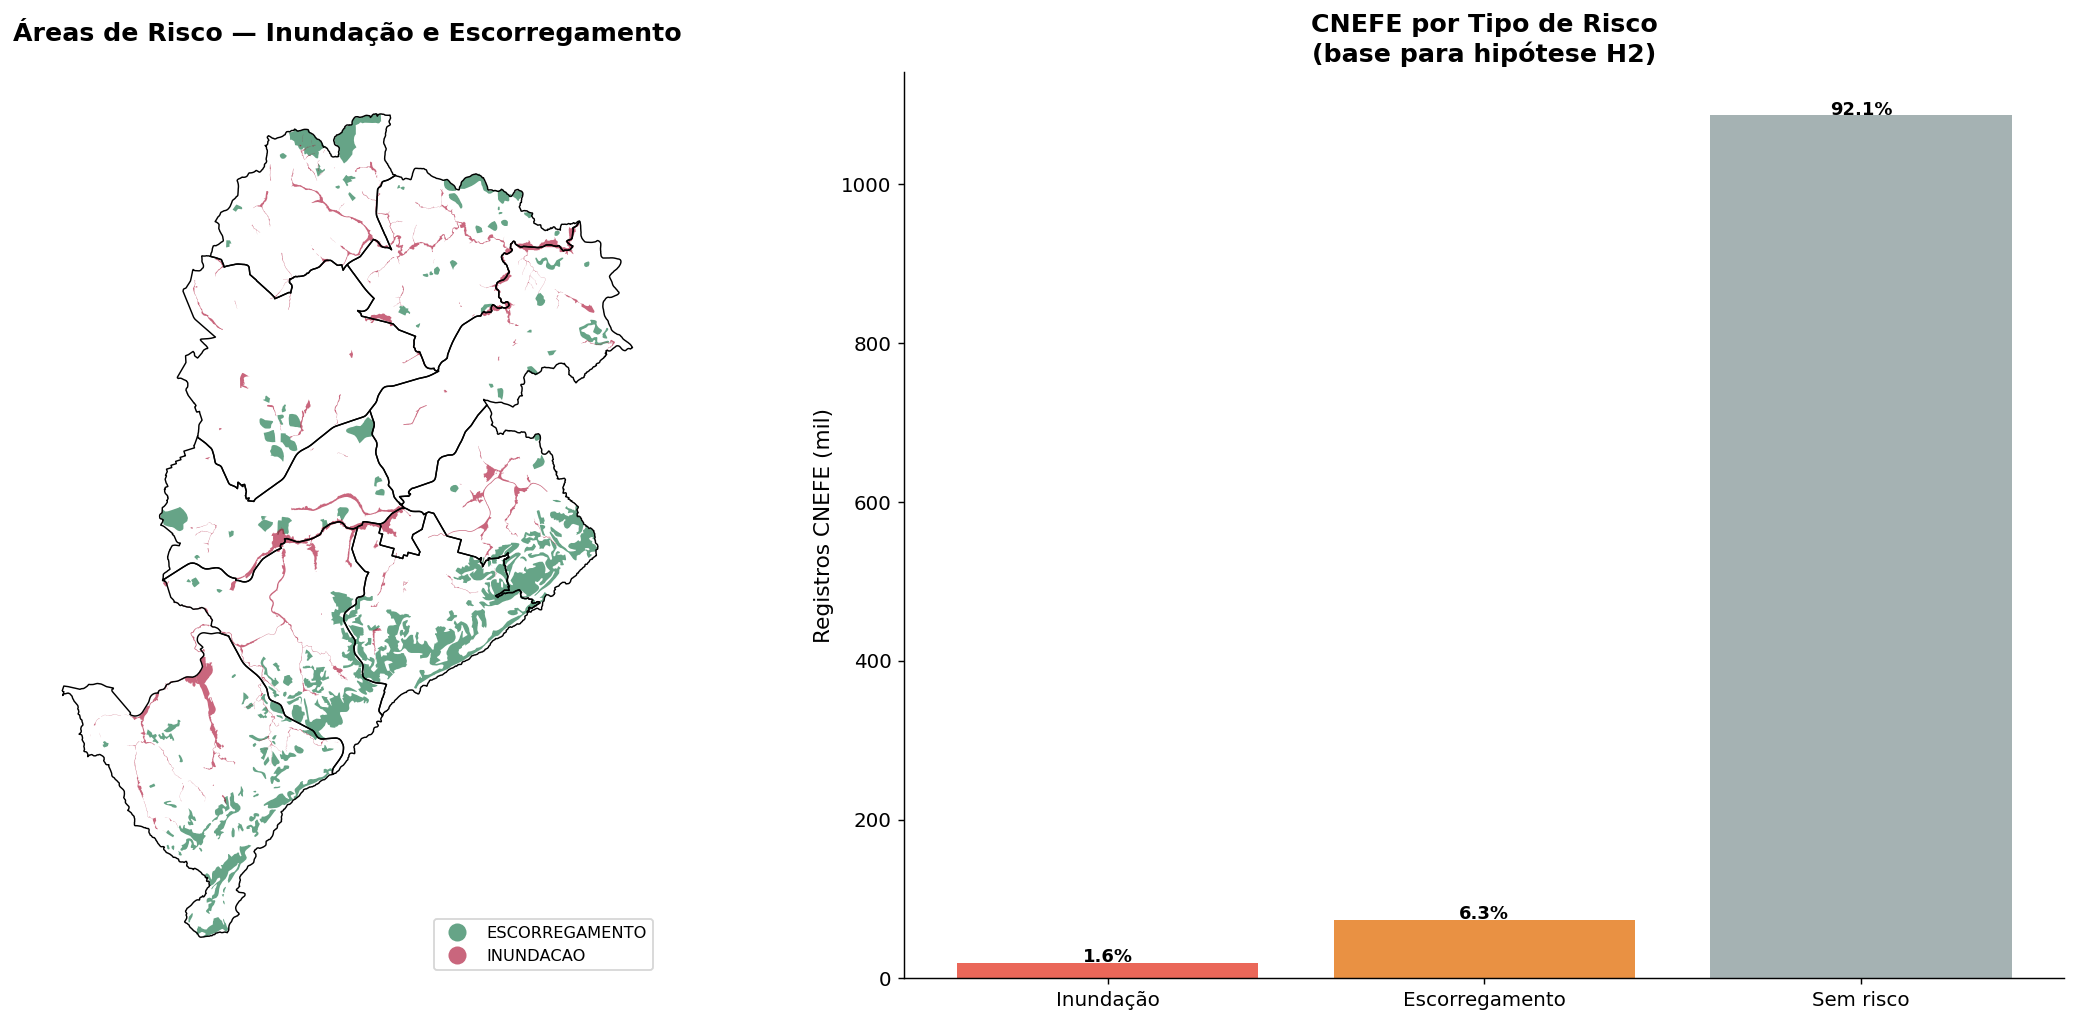

In [23]:
# 6.2 — EDA AREA_RISCO
risco = area_risco.copy()
bh_total_m2 = regionais_m.geometry.union_all().area

print("=== AREA_RISCO — Sanidade geométrica ===")
for _, row in risco.iterrows():
    tipo   = row['TIPO_RISCO']
    valida = row.geometry.is_valid
    area   = row.geometry.area / 1e6  # km²
    pct_bh = row.geometry.area / bh_total_m2 * 100
    print(f"  {tipo}: válido={valida}, área={area:.2f} km²  ({pct_bh:.1f}% de BH)")

# Sobreposição entre tipos
inund_geom  = risco[risco['TIPO_RISCO'] == 'INUNDACAO'].geometry.iloc[0]
escorr_geom = risco[risco['TIPO_RISCO'] == 'ESCORREGAMENTO'].geometry.iloc[0]
inter_area  = inund_geom.intersection(escorr_geom).area / 1e6
print(f"\n  Sobreposição INUNDACAO ∩ ESCORREGAMENTO: {inter_area:.3f} km²")

# Mapa com CNEFE em risco
cnefe_m = cnefe.to_crs('EPSG:31983')
cnefe_risco = gpd.sjoin(cnefe_m[['geometry']], risco[['TIPO_RISCO','geometry']],
                         how='left', predicate='within')
cnefe_risco = cnefe_risco[~cnefe_risco.index.duplicated(keep='first')]
cnefe_risco['em_risco'] = cnefe_risco['TIPO_RISCO'].notna()

pct_risco_total = cnefe_risco['em_risco'].mean() * 100
pct_por_tipo = cnefe_risco['TIPO_RISCO'].value_counts(dropna=False)

print(f"\n  CNEFE em área de risco (qualquer tipo): {cnefe_risco['em_risco'].sum():,} ({pct_risco_total:.1f}%)")
for k, v in pct_por_tipo.items():
    label = str(k) if not pd.isna(k) else 'Sem risco'
    print(f"    {label}: {v:,} ({v/len(cnefe)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
risco.plot(column='TIPO_RISCO', ax=ax, alpha=0.6,
           legend=True, cmap='RdYlGn_r',
           legend_kwds={'loc': 'lower right', 'fontsize': 9})
regionais_m.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('Áreas de Risco — Inundação e Escorregamento', fontweight='bold')
ax.axis('off')

ax = axes[1]
labels_risco = ['Inundação', 'Escorregamento', 'Sem risco']
vals_risco = [
    (cnefe_risco['TIPO_RISCO'] == 'INUNDACAO').sum(),
    (cnefe_risco['TIPO_RISCO'] == 'ESCORREGAMENTO').sum(),
    (~cnefe_risco['em_risco']).sum(),
]
colors_risco = ['#e74c3c', '#e67e22', '#95a5a6']
bars = ax.bar(labels_risco, [v/1000 for v in vals_risco], color=colors_risco, alpha=0.85)
ax.set_ylabel('Registros CNEFE (mil)')
ax.set_title('CNEFE por Tipo de Risco\n(base para hipótese H2)', fontweight='bold')
for bar, val in zip(bars, vals_risco):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val/len(cnefe)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_area_risco.png', bbox_inches='tight')
plt.show()

### 6.3 Camada IVS: Índice de Vulnerabilidade em Saúde por Setor

**Hipótese H2 + H3:** O IVS captura vulnerabilidade socioeconômica ao nível de setor censitário. Setores com IVS "Muito Elevado" tendem a ter menor infraestrutura de serviços urbanos e pior qualidade de geocodificação. A correlação IVS × GCI_empirico testa se vulnerabilidade social se traduz em pior posicionamento GPS.

**Nota metodológica:** IVS é de 2012 (BH), pode não refletir transformações urbanas pós-2012, especialmente em áreas de expansão recente. Setores FLAG_NAO_AVALIADO devem ser tratados como missing, não como baixa vulnerabilidade.

=== IVS — Distribuição ===
  Total setores: 3,936
  Não avaliados (FLAG_NAO_AVALIADO=1): 106 (2.7%)
  Setores avaliados: 3,830

  Distribuição IVS_2012:
    Médio: 1460 (37.1%)
    Baixo: 1330 (33.8%)
    Elevado: 737 (18.7%)
    Muito Elevado: 303 (7.7%)
    Não Avaliado: 106 (2.7%)


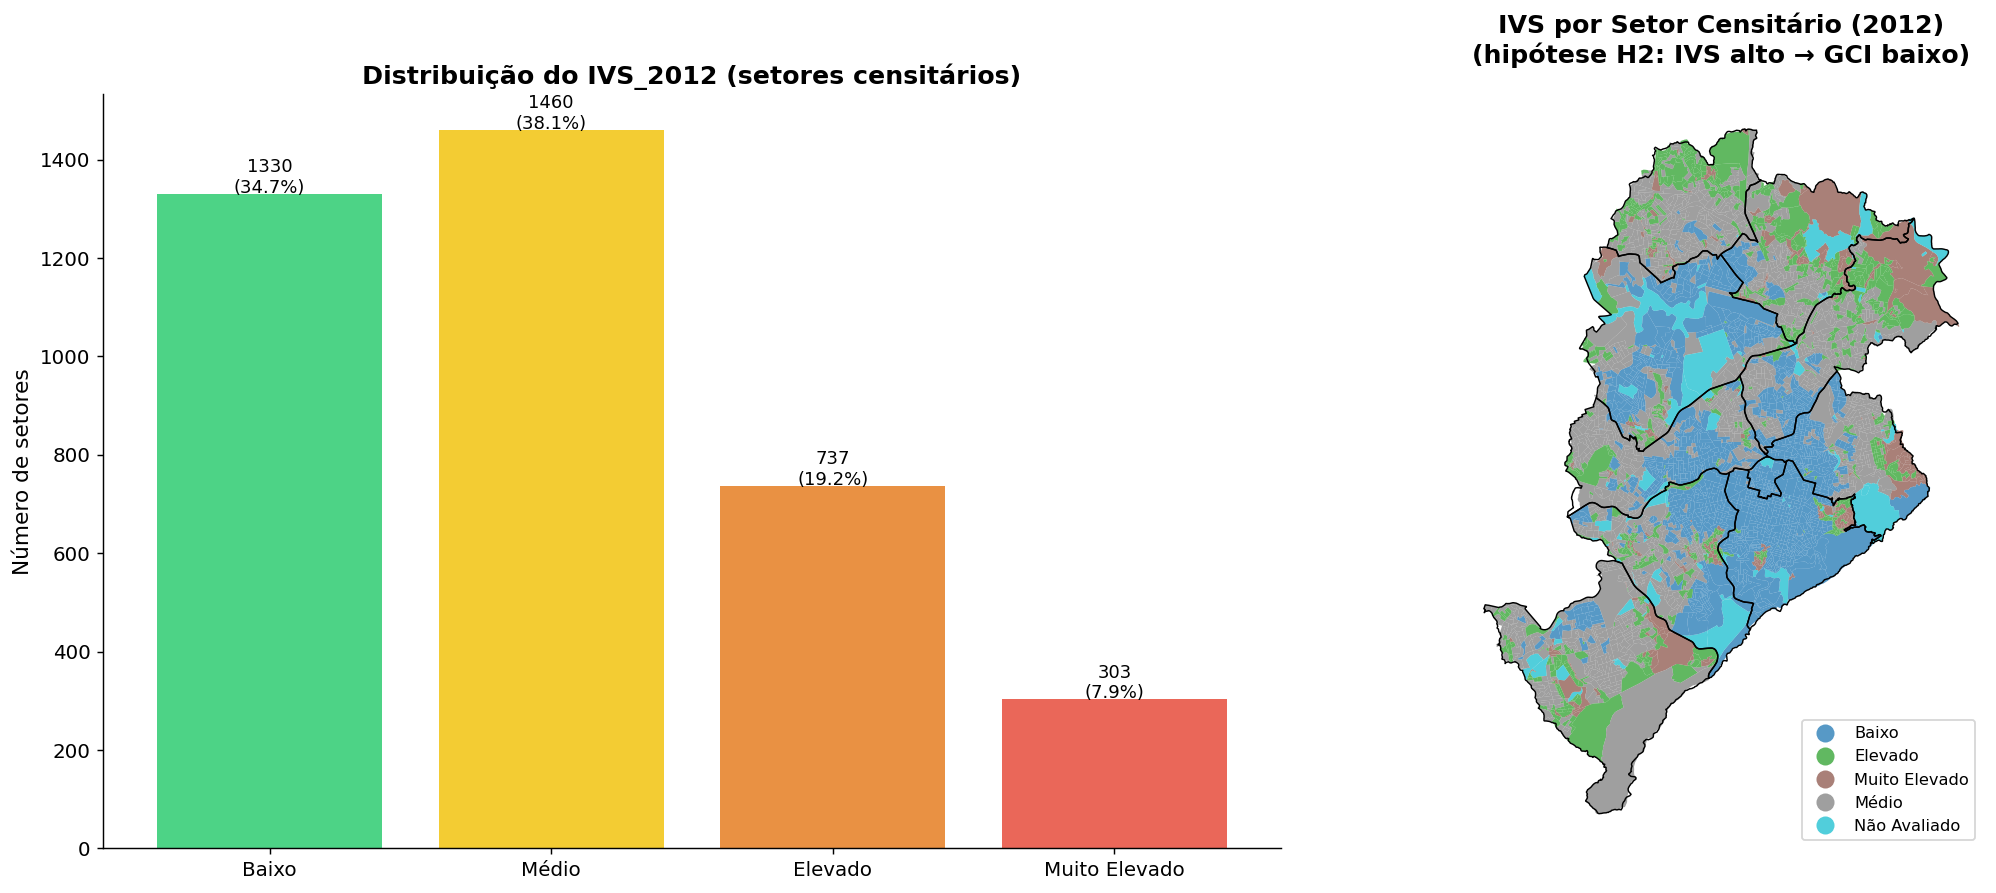


Cobertura IVS no CNEFE: 99.6% dos pontos
IVS_2012
Médio            38.1
Baixo            37.6
Elevado          16.1
Muito Elevado     7.0
Não Avaliado      0.8
NaN               0.4


In [24]:
# 6.3 — EDA IVS
ivs_df = ivs.copy()
print("=== IVS — Distribuição ===")
print(f"  Total setores: {len(ivs_df):,}")
if 'FLAG_NAO_AVALIADO' in ivs_df.columns:
    n_nao_av = int(ivs_df['FLAG_NAO_AVALIADO'].sum())
    print(f"  Não avaliados (FLAG_NAO_AVALIADO=1): {n_nao_av} ({n_nao_av/len(ivs_df)*100:.1f}%)")

ivs_avaliado = ivs_df[ivs_df['IVS_SCORE'].notna()]
print(f"  Setores avaliados: {len(ivs_avaliado):,}")

vc_ivs = ivs_df['IVS_2012'].value_counts(dropna=False)
print("\n  Distribuição IVS_2012:")
for k, v in vc_ivs.items():
    k_str = str(k) if not pd.isna(k) else 'Não Avaliado'
    print(f"    {k_str}: {v} ({v/len(ivs_df)*100:.1f}%)")

# Distribuição + mapa
order_ivs = ['Baixo', 'Médio', 'Elevado', 'Muito Elevado']
colors_ivs = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
ivs_cat_order = {k: i for i, k in enumerate(order_ivs)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
vc_plot = ivs_df['IVS_2012'].value_counts()
vc_order = [k for k in order_ivs if k in vc_plot.index]
vals = [vc_plot.get(k, 0) for k in vc_order]
bars = ax.bar(vc_order, vals, color=colors_ivs[:len(vc_order)], alpha=0.85)
ax.set_title('Distribuição do IVS_2012 (setores censitários)', fontweight='bold')
ax.set_ylabel('Número de setores')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f'{val}\n({val/len(ivs_avaliado)*100:.1f}%)', ha='center', fontsize=10)

ax = axes[1]
ivs_df['IVS_SCORE_fill'] = ivs_df['IVS_SCORE'].fillna(0)
ivs_df.plot(column='IVS_2012', ax=ax, alpha=0.75,
            legend=True, categorical=True,
            missing_kwds={'color': 'lightgray', 'label': 'Não Avaliado'},
            legend_kwds={'loc': 'lower right', 'fontsize': 9})
regionais_m.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('IVS por Setor Censitário (2012)\n(hipótese H2: IVS alto → GCI baixo)', fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_ivs_dist_mapa.png', bbox_inches='tight')
plt.show()

# Distribuição de IVS por regional
cnefe_ivs = gpd.sjoin(cnefe_m[['geometry']], ivs_df[['IVS_2012','IVS_SCORE','geometry']],
                       how='left', predicate='within')
cnefe_ivs = cnefe_ivs[~cnefe_ivs.index.duplicated(keep='first')]
pct_ivs_cnefe = cnefe_ivs['IVS_2012'].value_counts(normalize=True, dropna=False).mul(100).round(1)
print(f"\nCobertura IVS no CNEFE: {cnefe_ivs['IVS_2012'].notna().mean()*100:.1f}% dos pontos")
print(pct_ivs_cnefe.to_string())

### 6.4 Camada LOTE_CTM + Tipologia: Uso do Solo e Morfologia

**Hipóteses H4 e H5:** A tipologia de uso/ocupação do lote (residencial, comercial, misto, industrial) é o preditor direto do tipo de edificação, e portanto do padrão CDI. A morfologia (isolada, geminada, em série, em conjunto) correlaciona-se com a verticalização e com a precisão GPS possível no ambiente construído.

**Achado crítico de cobertura:** ~60% dos lotes sem tipologia antes do preenchimento (agora categorizados como "SEM CLASSIFICACAO"). Isso reflete a incompletude do shapefile TIPOLOGIA_USO_OCUPACAO_LOTE_2022, não ausência de edificação. Lotes industriais e de uso especial tendem a ter menor cobertura tipológica.

=== LOTE_CTM — Sanidade geométrica ===
  Total lotes: 365,444
  Geometrias válidas: 365,444 (100.00%)
  Área mediana (m²): 360.3
  Área P99 (m²): 4499
  Lotes área < 1 m² (suspeitos): 0

  Top 10 TIPOLOGIA_BROAD:
    RESIDENCIAL                   : 149,403  (40.9%)
    SEM CLASSIFICACAO             : 124,293  (34.0%)
    SEM INFORMACAO                :  41,412  (11.3%)
    MISTO                         :  20,146  (5.5%)
    LOTE VAGO                     :  17,034  (4.7%)
    NAO RESIDENCIAL               :  12,907  (3.5%)
    PARQUE                        :     249  (0.1%)


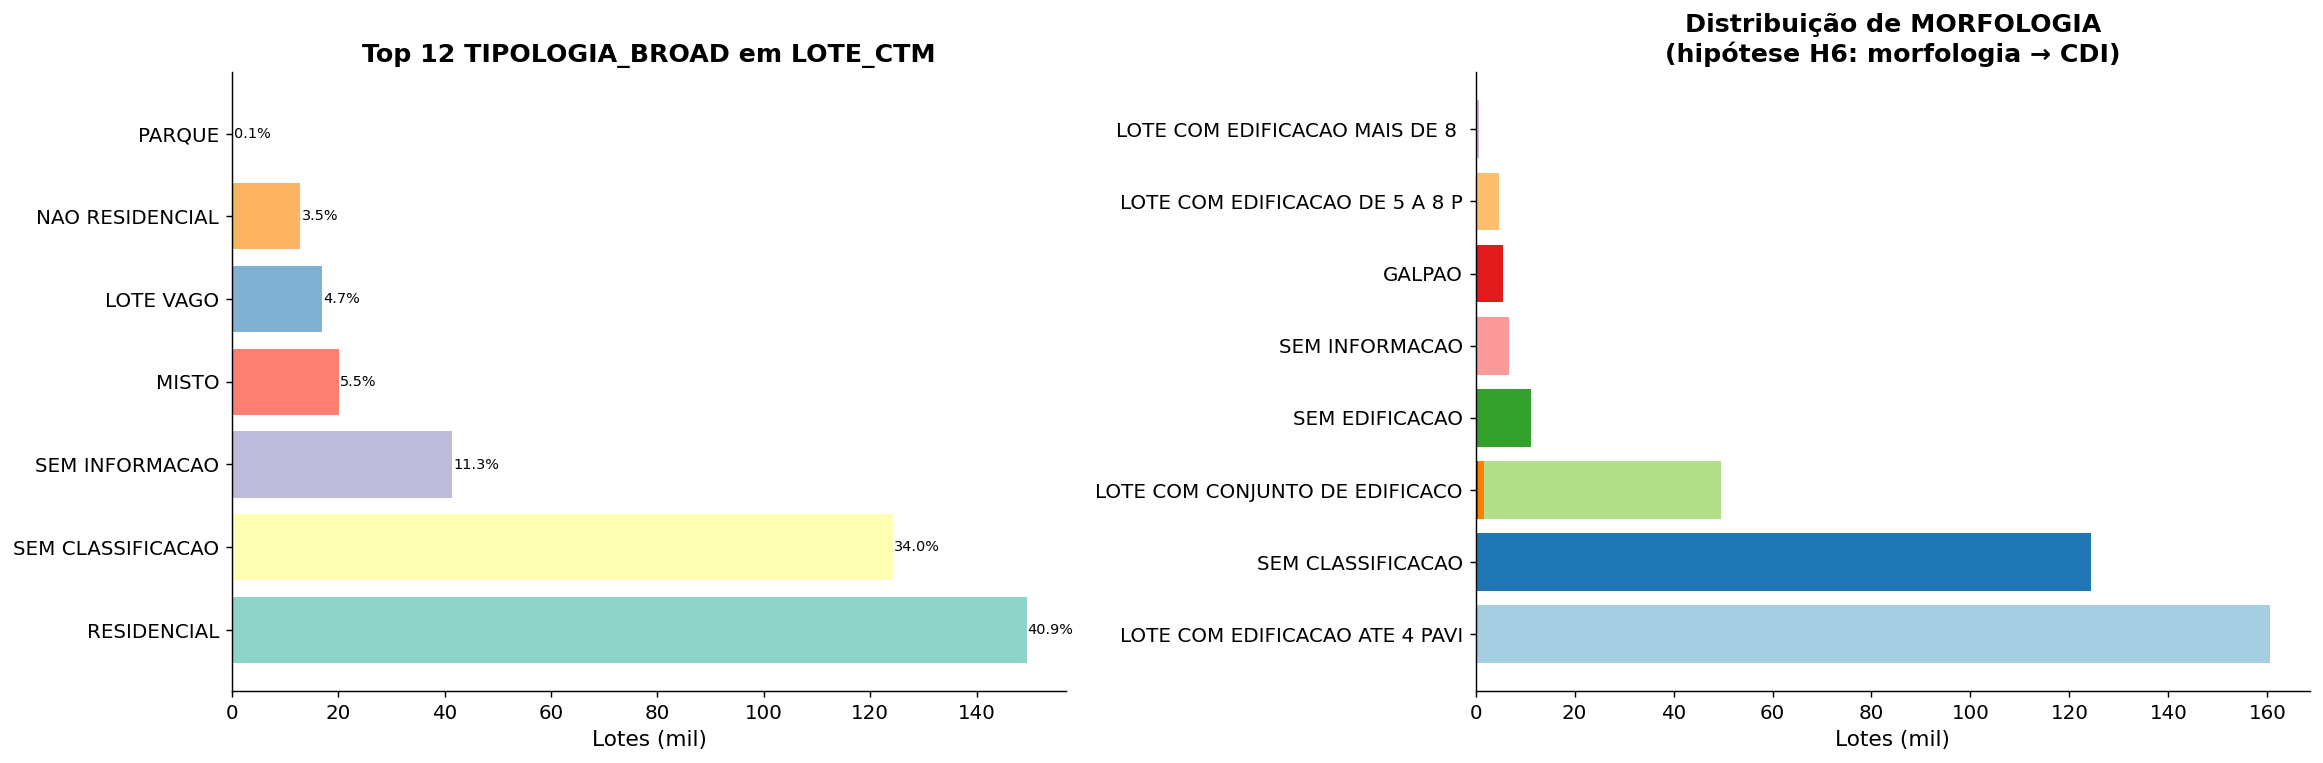

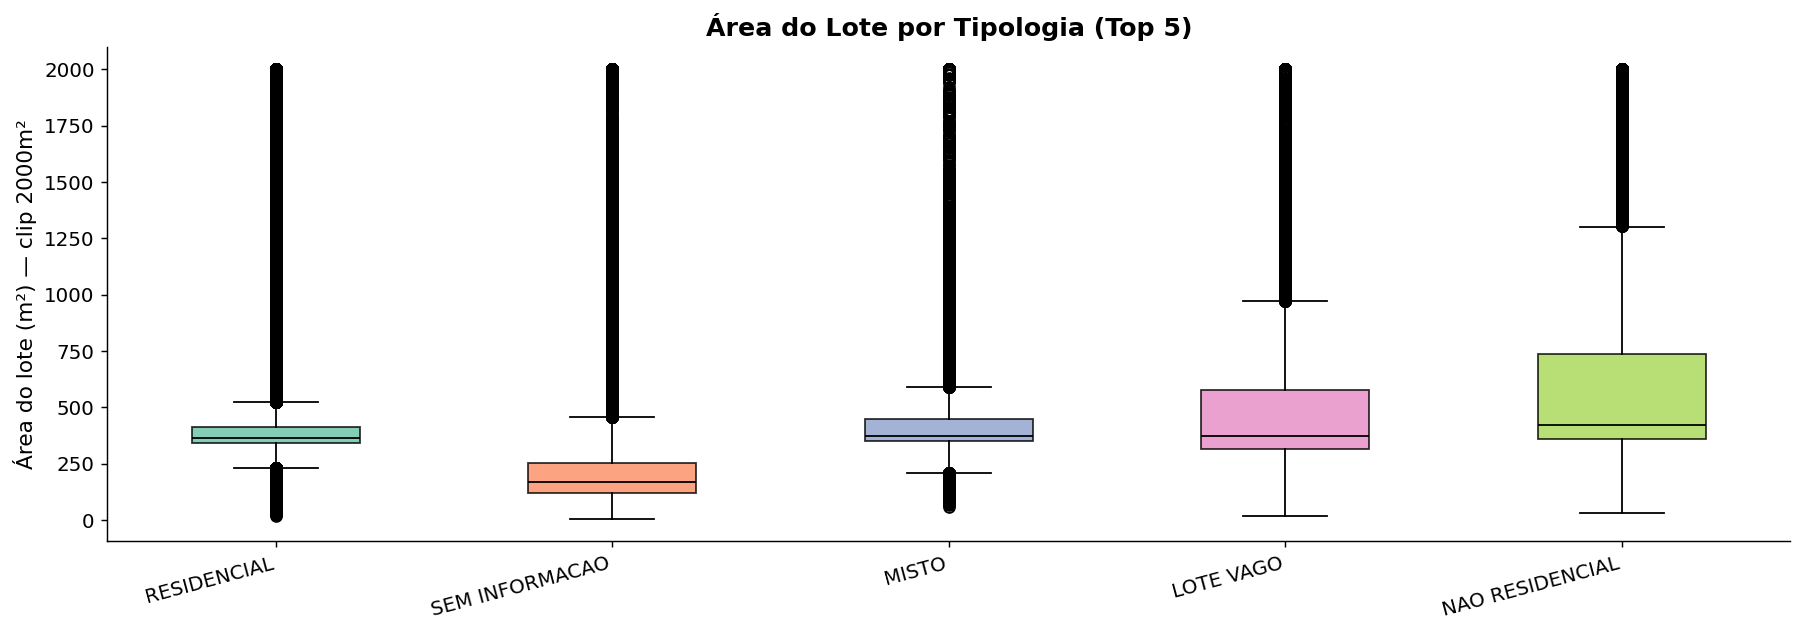

In [25]:
# 6.4 — EDA LOTE_CTM
lote = lote_ctm.copy()
lote['AREA_LOTE'] = lote.geometry.area
lote['VALIDA'] = lote.geometry.is_valid

print("=== LOTE_CTM — Sanidade geométrica ===")
print(f"  Total lotes: {len(lote):,}")
print(f"  Geometrias válidas: {lote['VALIDA'].sum():,} ({lote['VALIDA'].mean()*100:.2f}%)")
print(f"  Área mediana (m²): {lote['AREA_LOTE'].median():.1f}")
print(f"  Área P99 (m²): {lote['AREA_LOTE'].quantile(.99):.0f}")
print(f"  Lotes área < 1 m² (suspeitos): {(lote['AREA_LOTE'] < 1).sum():,}")

# Tipologia Broad
tb_vc = lote['TIPOLOGIA_BROAD'].value_counts(dropna=False)
print(f"\n  Top 10 TIPOLOGIA_BROAD:")
for k, v in tb_vc.head(10).items():
    print(f"    {str(k):<30}: {v:>7,}  ({v/len(lote)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
top_tipologias = tb_vc.head(12)
labels_tip = [str(k)[:25] for k in top_tipologias.index]
bars = ax.barh(labels_tip, top_tipologias.values / 1000, color=sns.color_palette('Set3', len(top_tipologias)))
ax.set_xlabel('Lotes (mil)')
ax.set_title('Top 12 TIPOLOGIA_BROAD em LOTE_CTM', fontweight='bold')
for bar, val in zip(bars, top_tipologias.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val/len(lote)*100:.1f}%', va='center', fontsize=8)

ax = axes[1]
morfo_vc = lote['MORFOLOGIA'].value_counts(dropna=False)
labels_m = [str(k)[:30] for k in morfo_vc.index[:10]]
ax.barh(labels_m, morfo_vc.values[:10] / 1000, color=sns.color_palette('Paired', len(labels_m)))
ax.set_xlabel('Lotes (mil)')
ax.set_title('Distribuição de MORFOLOGIA\n(hipótese H6: morfologia → CDI)', fontweight='bold')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_lote_tipologia.png', bbox_inches='tight')
plt.show()

# Área do lote por tipologia (boxplot — apenas classificados)
lote_class = lote[lote['TIPOLOGIA_BROAD'] != 'SEM CLASSIFICACAO'].copy()
top5_tipos = lote_class['TIPOLOGIA_BROAD'].value_counts().head(5).index.tolist()
fig, ax = plt.subplots(figsize=(14, 5))
data_box = [lote_class[lote_class['TIPOLOGIA_BROAD'] == t]['AREA_LOTE'].clip(upper=2000).values
            for t in top5_tipos]
bp = ax.boxplot(data_box, vert=True, patch_artist=True, medianprops={'color': 'black'})
for patch, color in zip(bp['boxes'], sns.color_palette('Set2', 5)):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels([t[:20] for t in top5_tipos], rotation=15, ha='right')
ax.set_ylabel('Área do lote (m²) — clip 2000m²')
ax.set_title('Área do Lote por Tipologia (Top 5)', fontweight='bold')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_lote_area_tipologia.png', bbox_inches='tight')
plt.show()

### 6.5 Cadastro Imobiliário: INFRA_SCORE, PADRAO_SCORE e Distribuição Temporal

**Hipóteses H3 e H4:** O INFRA_SCORE (soma dos 8 indicadores binários de infraestrutura) e o PADRAO_SCORE (qualidade de acabamento P1–P5) são os dois principais proxies socioeconômicos mensuráveis a nível de lote. A hipótese H3 postula que INFRA_SCORE baixo implica GCI baixo (correlação indireta via informalidade). H4 postula que PADRAO_SCORE alto (imóveis bem acabados) corresponde a bairros onde a precisão GPS é maior.

**Sanidade:** ANO_CONSTRUCAO foi limpo (valores <1700 ou >2025 → NaN). PADRAO_SCORE=NaN indica lotes "TERRITORIAL" (sem construção), não devem ser incluídos em análises de qualidade construtiva.

=== CADASTRO_IMOBILIARIO — Sanidade ===
  Total unidades: 896,964
  FLAG_TERRITORIAL=1: 29,731 (3.3%)
  FLAG_LOTE_VAGO=1:   29,731 (3.3%)
  Unidades construtivas: 867,233
  PADRAO_SCORE nulos (excl. territorial): 0
  ANO_CONSTRUCAO nulos: 33,453


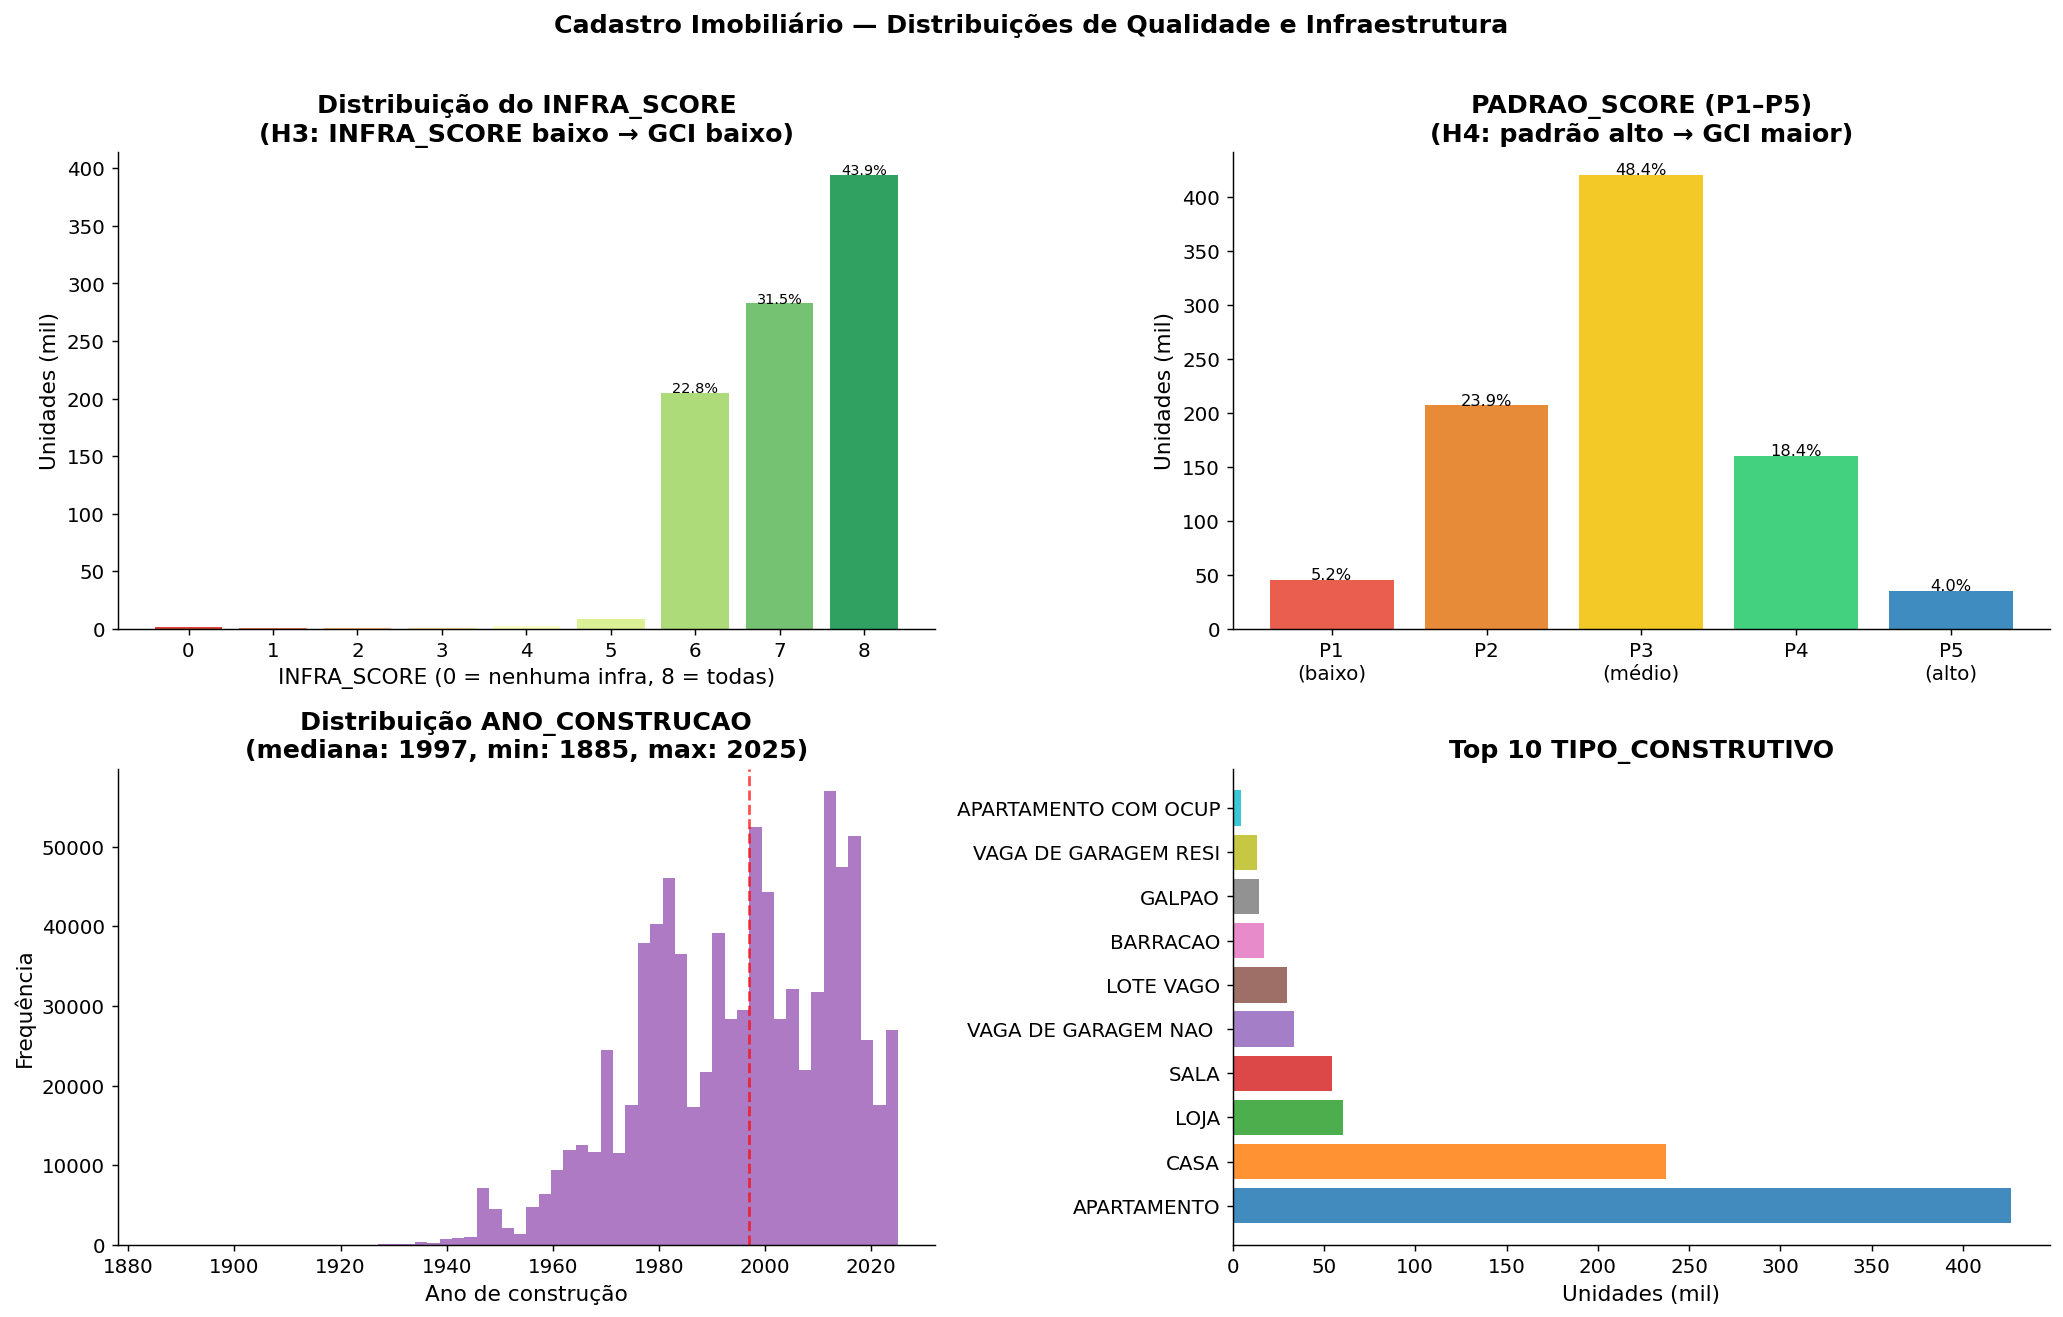

In [26]:
# 6.5a — Distribuições: INFRA_SCORE, PADRAO_SCORE, ANO_CONSTRUCAO, TIPO_CONSTRUTIVO
cad = cad_units.copy()

# Excluir TERRITORIAL para análises construtivas
cad_const = cad[cad.get('FLAG_TERRITORIAL', pd.Series(0, index=cad.index)) == 0]

print("=== CADASTRO_IMOBILIARIO — Sanidade ===")
print(f"  Total unidades: {len(cad):,}")
if 'FLAG_TERRITORIAL' in cad.columns:
    n_terr = int(cad['FLAG_TERRITORIAL'].sum())
    n_vago = int(cad.get('FLAG_LOTE_VAGO', pd.Series(0, index=cad.index)).sum())
    print(f"  FLAG_TERRITORIAL=1: {n_terr:,} ({n_terr/len(cad)*100:.1f}%)")
    print(f"  FLAG_LOTE_VAGO=1:   {n_vago:,} ({n_vago/len(cad)*100:.1f}%)")
    print(f"  Unidades construtivas: {len(cad_const):,}")
print(f"  PADRAO_SCORE nulos (excl. territorial): {cad_const['PADRAO_SCORE'].isna().sum():,}")
print(f"  ANO_CONSTRUCAO nulos: {cad['ANO_CONSTRUCAO'].isna().sum():,}")

# Painel 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# INFRA_SCORE
ax = axes[0][0]
infra_vc = cad['INFRA_SCORE'].value_counts().sort_index()
bars = ax.bar(infra_vc.index.astype(str), infra_vc.values / 1000,
              color=sns.color_palette('RdYlGn', 9), alpha=0.9)
ax.set_xlabel('INFRA_SCORE (0 = nenhuma infra, 8 = todas)')
ax.set_ylabel('Unidades (mil)')
ax.set_title('Distribuição do INFRA_SCORE\n(H3: INFRA_SCORE baixo → GCI baixo)', fontweight='bold')
for bar, val in zip(bars, infra_vc.values):
    if val / len(cad) > 0.02:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val/len(cad)*100:.1f}%', ha='center', fontsize=8)

# PADRAO_SCORE
ax = axes[0][1]
pad_vc = cad_const['PADRAO_SCORE'].dropna().value_counts().sort_index()
labels_pad = {1: 'P1\n(baixo)', 2: 'P2', 3: 'P3\n(médio)', 4: 'P4', 5: 'P5\n(alto)'}
colors_pad = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#2980b9']
bars = ax.bar([labels_pad.get(int(k), str(k)) for k in pad_vc.index],
              pad_vc.values / 1000,
              color=[colors_pad[int(k)-1] for k in pad_vc.index], alpha=0.9)
ax.set_ylabel('Unidades (mil)')
ax.set_title('PADRAO_SCORE (P1–P5)\n(H4: padrão alto → GCI maior)', fontweight='bold')
for bar, val in zip(bars, pad_vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val/len(cad_const)*100:.1f}%', ha='center', fontsize=9)

# ANO_CONSTRUCAO
ax = axes[1][0]
ano = cad_const['ANO_CONSTRUCAO'].dropna()
ax.hist(ano, bins=60, color='#9b59b6', alpha=0.8, edgecolor='none')
ax.set_xlabel('Ano de construção')
ax.set_ylabel('Frequência')
ax.set_title(f'Distribuição ANO_CONSTRUCAO\n(mediana: {ano.median():.0f}, min: {ano.min()}, max: {ano.max()})',
             fontweight='bold')
ax.axvline(ano.median(), color='red', linestyle='--', alpha=0.7)

# TIPO_CONSTRUTIVO
ax = axes[1][1]
tipo_vc = cad['TIPO_CONSTRUTIVO'].value_counts().head(10)
ax.barh([str(k)[:20] for k in tipo_vc.index], tipo_vc.values / 1000,
        color=sns.color_palette('tab10', len(tipo_vc)), alpha=0.85)
ax.set_xlabel('Unidades (mil)')
ax.set_title('Top 10 TIPO_CONSTRUTIVO', fontweight='bold')

plt.suptitle('Cadastro Imobiliário — Distribuições de Qualidade e Infraestrutura',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_cadastro_dist.png', bbox_inches='tight')
plt.show()

Distribuições de INFRA_SCORE e PADRAO_SCORE revelam o perfil socioespacial de BH. Ano de construção permite verificar se imóveis antigos concentram pior qualidade de geocodificação.

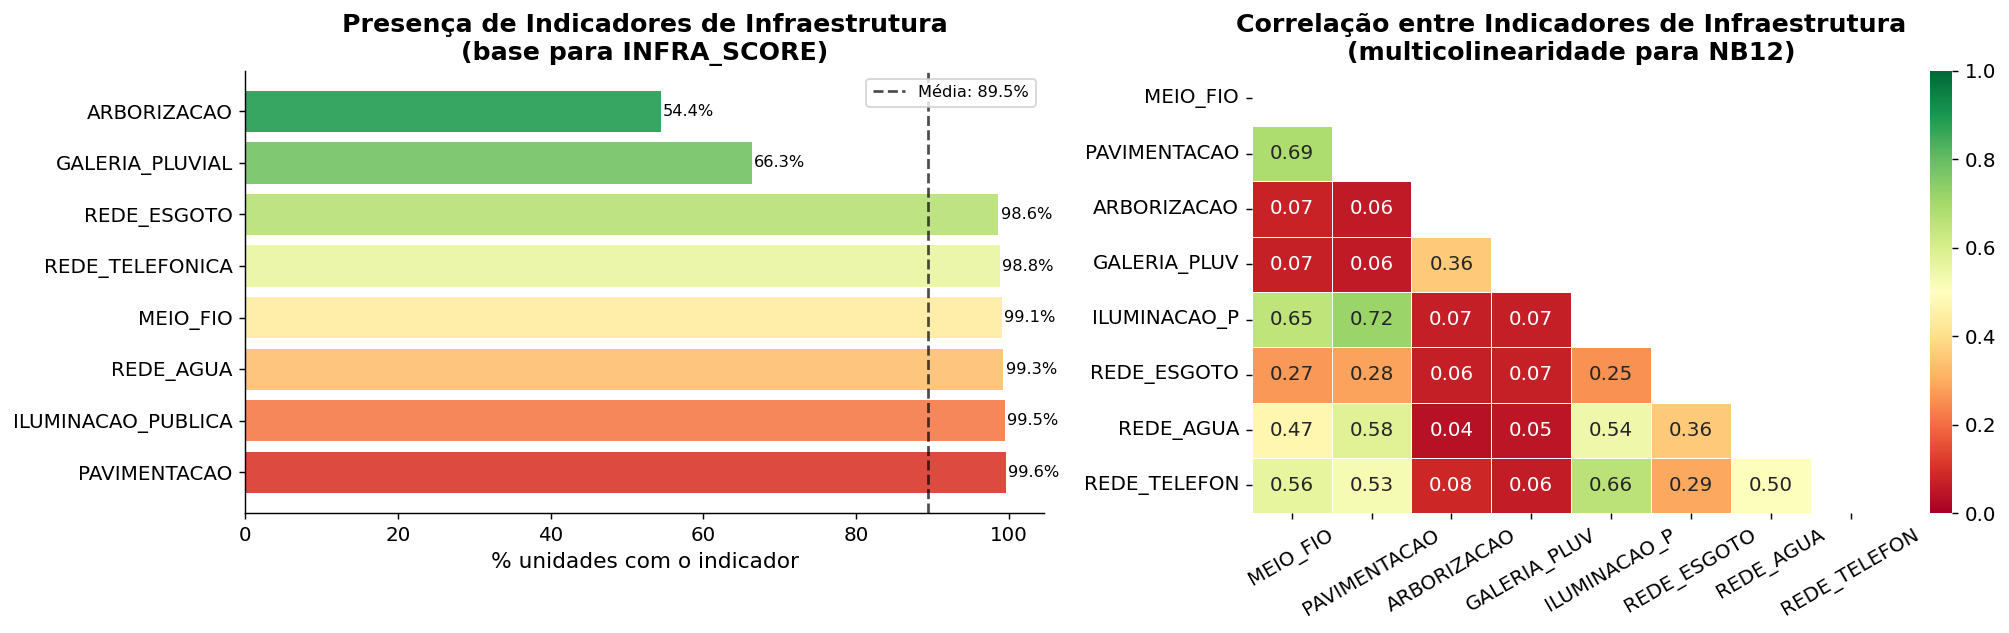


Indicadores de infraestrutura (% de presença, ordem decrescente):
  IND_PAVIMENTACAO: 99.6%
  IND_ILUMINACAO_PUBLICA: 99.5%
  IND_REDE_AGUA: 99.3%
  IND_MEIO_FIO: 99.1%
  IND_REDE_TELEFONICA: 98.8%
  IND_REDE_ESGOTO: 98.6%
  IND_GALERIA_PLUVIAL: 66.3%
  IND_ARBORIZACAO: 54.4%


In [27]:
# 6.5b — Indicadores individuais de infraestrutura (heatmap de presença)
IND_COLS = [
    "IND_MEIO_FIO", "IND_PAVIMENTACAO", "IND_ARBORIZACAO",
    "IND_GALERIA_PLUVIAL", "IND_ILUMINACAO_PUBLICA",
    "IND_REDE_ESGOTO", "IND_REDE_AGUA", "IND_REDE_TELEFONICA",
]
avail_ind = [c for c in IND_COLS if c in cad.columns]

ind_pct = (cad[avail_ind].mean() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.barh([c.replace('IND_', '') for c in ind_pct.index],
               ind_pct.values,
               color=sns.color_palette('RdYlGn', len(ind_pct)), alpha=0.9)
ax.axvline(ind_pct.mean(), color='black', linestyle='--', alpha=0.7,
           label=f'Média: {ind_pct.mean():.1f}%')
ax.set_xlabel('% unidades com o indicador')
ax.set_title('Presença de Indicadores de Infraestrutura\n(base para INFRA_SCORE)', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, ind_pct.values):
    ax.text(val + 0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax = axes[1]
# Correlação entre indicadores (amostra para velocidade)
cad_sample = cad[avail_ind].sample(min(50000, len(cad)), random_state=42)
corr = cad_sample.corr()
labels_short = [c.replace('IND_', '')[:12] for c in avail_ind]
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=labels_short, yticklabels=labels_short,
            linewidths=0.5, mask=mask)
ax.set_title('Correlação entre Indicadores de Infraestrutura\n(multicolinearidade para NB12)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_infra_indicadores.png', bbox_inches='tight')
plt.show()

print("\nIndicadores de infraestrutura (% de presença, ordem decrescente):")
for c, pct in ind_pct.items():
    print(f"  {c}: {pct:.1f}%")

Heatmap dos indicadores binários (IND_GALERIA_PLUVIAL, IND_PAVIMENTACAO, etc.) por regional mostra quais áreas têm infraestrutura mais precária, correlacionada com menor qualidade cadastral.

---
## 7. Análise de Cobertura: % do CNEFE por Camada Contextual

Esta seção quantifica a **cobertura espacial** de cada camada contextual sobre o CNEFE: que percentual dos 1,18M pontos CNEFE cai dentro de cada camada. Isso determina a validade ecológica de usar cada camada como variável preditora, cobertura baixa implica viés de seleção nos modelos do NB12.

**Achado esperado crítico:** ~39% do CNEFE está dentro de lotes CTM registrados, os 61% restantes são domicílios em vias, espaços públicos ou áreas informais sem registro cadastral. Esse achado desafia a suposição de que o cadastro municipal cobre o universo censitário.

=== Cobertura das Camadas Contextuais sobre CNEFE ===



  AREA_RISCO (qualquer)         :    93,275 / 1,180,102  (7.9%)


  IVS (todos setores)           : 1,175,742 / 1,180,102  (99.6%)


  LOTE_CTM                      :   464,360 / 1,180,102  (39.3%)


  CADASTRO_LOTES                :   396,746 / 1,180,102  (33.6%)


  BAIRROS_POPULARES             : 1,177,907 / 1,180,102  (99.8%)


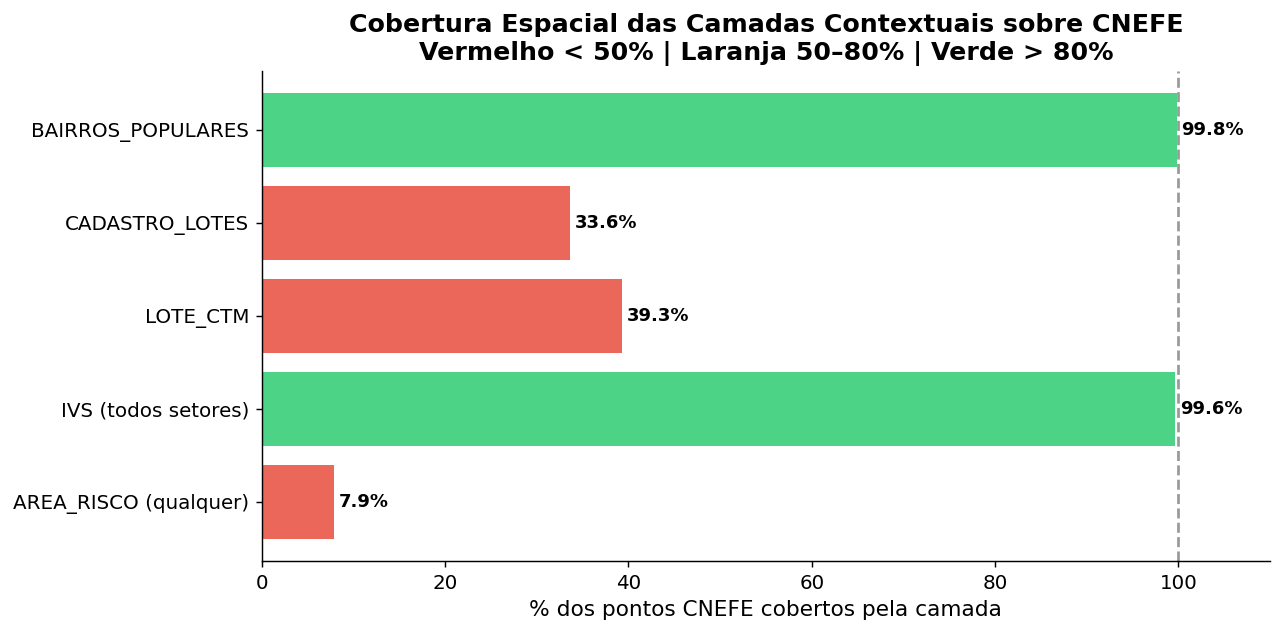

In [28]:
# 7.1 — Cobertura espacial de cada camada sobre o CNEFE
# Nota: sjoin_nearest com max_distance=0 equivale a within mas mais robusto para bordas
from shapely.ops import unary_union

cnefe_m_cov = cnefe.to_crs('EPSG:31983')[['geometry']].copy()
N_CNEFE = len(cnefe_m_cov)

def coverage_pct(cnefe_pts, layer_gdf, name, predicate='within', dissolve=True):
    """Calcula % de pontos CNEFE dentro de layer_gdf."""
    try:
        if dissolve:
            union_geom = layer_gdf.geometry.union_all()
            layer_union = gpd.GeoDataFrame(geometry=[union_geom], crs=layer_gdf.crs)
            joined = gpd.sjoin(cnefe_pts, layer_union, how='left', predicate=predicate)
        else:
            joined = gpd.sjoin(cnefe_pts, layer_gdf[['geometry']], how='left', predicate=predicate)
        joined = joined[~joined.index.duplicated(keep='first')]
        covered = joined['index_right'].notna().sum()
        pct = covered / N_CNEFE * 100
        print(f"  {name:<30}: {covered:>9,} / {N_CNEFE:,}  ({pct:.1f}%)")
        return pct
    except Exception as e:
        print(f"  {name:<30}: ERRO — {e}")
        return None

print("=== Cobertura das Camadas Contextuais sobre CNEFE ===\n")
results = {}
results['AREA_RISCO (qualquer)'] = coverage_pct(cnefe_m_cov, risco,    'AREA_RISCO (qualquer)')
results['IVS (todos setores)']   = coverage_pct(cnefe_m_cov, ivs_df,   'IVS (todos setores)')
results['LOTE_CTM']              = coverage_pct(cnefe_m_cov, lote,     'LOTE_CTM')
results['CADASTRO_LOTES']        = coverage_pct(cnefe_m_cov, cad_lotes,'CADASTRO_LOTES')
results['BAIRROS_POPULARES']     = coverage_pct(cnefe_m_cov, bairro_pop,'BAIRROS_POPULARES')

# Barras com resultado
fig, ax = plt.subplots(figsize=(10, 5))
camadas_cov = {k: v for k, v in results.items() if v is not None}
colors_cov = ['#e74c3c' if v < 50 else '#f39c12' if v < 80 else '#2ecc71'
               for v in camadas_cov.values()]
bars = ax.barh(list(camadas_cov.keys()), list(camadas_cov.values()), color=colors_cov, alpha=0.85)
ax.axvline(100, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('% dos pontos CNEFE cobertos pela camada')
ax.set_title('Cobertura Espacial das Camadas Contextuais sobre CNEFE\n'
             'Vermelho < 50% | Laranja 50–80% | Verde > 80%', fontweight='bold')
for bar, val in zip(bars, camadas_cov.values()):
    ax.text(val + 0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_cobertura_camadas.png', bbox_inches='tight')
plt.show()

Tabela e barras mostram o percentual de registros CNEFE com correspondência em cada camada. Camadas com cobertura < 80% são tratadas como opcionais nas análises.

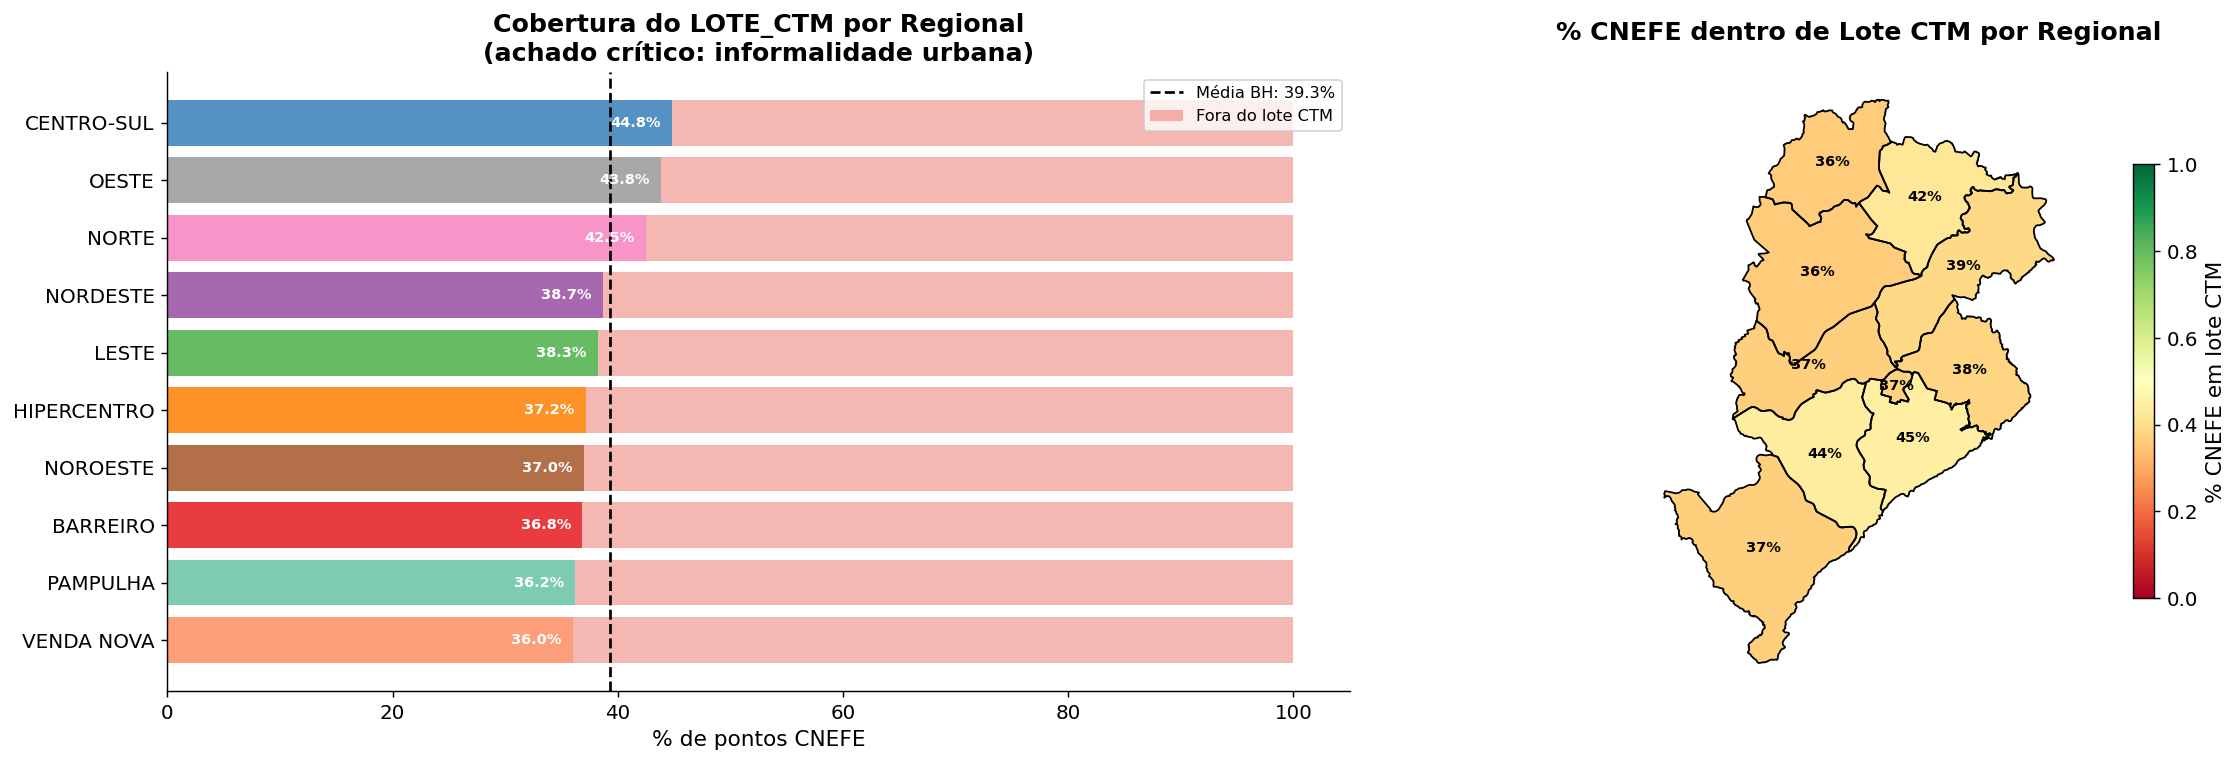

,pct_em_lote,n_total
NOME_REGIO,,
VENDA NOVA,36.0%,"120,144"
PAMPULHA,36.2%,"123,907"
BARREIRO,36.8%,"132,701"
NOROESTE,37.0%,"127,133"
HIPERCENTRO,37.2%,"21,440"
LESTE,38.3%,"110,574"
NORDESTE,38.7%,"147,118"
NORTE,42.5%,"103,224"
OESTE,43.8%,"155,185"


In [29]:
# 7.2 — Cobertura do LOTE_CTM por regional (achado crítico de informalidade)
cnefe_lote = gpd.sjoin(cnefe_m[['geometry']], lote[['geometry']],
                        how='left', predicate='within')
cnefe_lote = cnefe_lote[~cnefe_lote.index.duplicated(keep='first')]
cnefe_lote['em_lote'] = cnefe_lote['index_right'].notna()

# Adicionar regional
cnefe_lote_reg = gpd.sjoin(cnefe_m[['geometry']], regionais_m[['NOME_REGIO','geometry']],
                            how='left', predicate='within')
cnefe_lote_reg = cnefe_lote_reg[~cnefe_lote_reg.index.duplicated(keep='first')]
cnefe_lote['NOME_REGIO'] = cnefe_lote_reg['NOME_REGIO']

cov_by_reg = cnefe_lote.groupby('NOME_REGIO')['em_lote'].agg(['mean','count'])
cov_by_reg.columns = ['pct_em_lote', 'n_total']
cov_by_reg['pct_fora_lote'] = 1 - cov_by_reg['pct_em_lote']
cov_by_reg = cov_by_reg.sort_values('pct_em_lote', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
colors_reg = [PALETA_REGIONAL.get(r, '#aaa') for r in cov_by_reg.index]
ax.barh(cov_by_reg.index, cov_by_reg['pct_em_lote'] * 100, color=colors_reg, alpha=0.85)
ax.barh(cov_by_reg.index, cov_by_reg['pct_fora_lote'] * 100,
        left=cov_by_reg['pct_em_lote'] * 100, color='#e74c3c', alpha=0.4,
        label='Fora do lote CTM')
ax.axvline(cnefe_lote['em_lote'].mean() * 100, color='black', linestyle='--',
           linewidth=1.5, label=f'Média BH: {cnefe_lote["em_lote"].mean()*100:.1f}%')
ax.set_xlabel('% de pontos CNEFE')
ax.set_title('Cobertura do LOTE_CTM por Regional\n(achado crítico: informalidade urbana)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 105)
for i, (reg, row) in enumerate(cov_by_reg.iterrows()):
    ax.text(row['pct_em_lote']*100 - 1, i,
            f"{row['pct_em_lote']*100:.1f}%", va='center', ha='right',
            color='white', fontsize=8, fontweight='bold')

# Mapa de cobertura por setor (amostra)
ax = axes[1]
cov_by_reg_plot = regionais_m.merge(cov_by_reg[['pct_em_lote']], on='NOME_REGIO', how='left')
cov_by_reg_plot.plot(column='pct_em_lote', cmap='RdYlGn', legend=True, ax=ax,
                     vmin=0, vmax=1,
                     legend_kwds={'label': '% CNEFE em lote CTM', 'shrink': 0.7})
regionais_m.boundary.plot(ax=ax, color='black', linewidth=1)
for _, row in cov_by_reg_plot.iterrows():
    c = row.geometry.centroid
    if not pd.isna(row['pct_em_lote']):
        ax.text(c.x, c.y, f"{row['pct_em_lote']*100:.0f}%",
                ha='center', va='center', fontsize=8, fontweight='bold')
ax.set_title('% CNEFE dentro de Lote CTM por Regional', fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_cobertura_lote_regional.png', bbox_inches='tight')
plt.show()

display(cov_by_reg.sort_values('pct_em_lote')[['pct_em_lote', 'n_total']].style
    .background_gradient(cmap='RdYlGn', subset=['pct_em_lote'])
    .format({'pct_em_lote': '{:.1%}', 'n_total': '{:,.0f}'})
    .set_caption('Cobertura do LOTE_CTM por Regional — % do CNEFE dentro de lotes cadastrados'))

Cobertura do cadastro imobiliário por regional revela onde o matching CNEFE-lote é mais completo. Baixa cobertura em regionais periféricas indica lacunas cadastrais que limitam análises por lote.

In [30]:
# 7.3 — Autocorrelação espacial de Moran (I global) para variáveis contextuais
# Usando espaço de agregação: setores censitários (resolução adequada para Moran's I)
try:
    from esda.moran import Moran
    from libpysal.weights import Queen
    ESDA_OK = True
except ImportError:
    ESDA_OK = False
    print("esda/libpysal não instalados. Execute: pip install esda libpysal")
    print("Calculando Moran's I manualmente via matriz de pesos Queen...")

if ESDA_OK:
    # Agregar variáveis contextuais por setor censitário
    setores_m = setores.to_crs('EPSG:31983').copy()

    # Enriquecer setores com GCI médio
    if 'GCI_empirico' in metrics.columns and 'COD_SETOR' in metrics.columns:
        gci_setor = metrics.groupby('COD_SETOR')['GCI_empirico'].mean().reset_index()
        gci_setor.columns = ['COD_SETOR', 'GCI_medio']
        setores_m = setores_m.merge(gci_setor, on='COD_SETOR', how='left')

    # IVS Score por setor
    if 'IVS_SCORE' in ivs_df.columns:
        ivs_merge = ivs_df[['COD_SETOR','IVS_SCORE']].copy()
        setores_m = setores_m.merge(ivs_merge, on='COD_SETOR', how='left')

    # Filtrar setores com dados válidos para Moran
    cols_moran = [c for c in ['GCI_medio', 'IVS_SCORE'] if c in setores_m.columns]
    setores_valid = setores_m[setores_m[cols_moran].notna().all(axis=1)].copy()

    if len(setores_valid) > 100:
        print(f"Calculando Moran's I para {len(setores_valid):,} setores censitários...")
        W = Queen.from_dataframe(setores_valid, silence_warnings=True)
        W.transform = 'r'

        moran_results = {}
        for col in cols_moran:
            mi = Moran(setores_valid[col].values, W)
            moran_results[col] = {'I': mi.I, 'p': mi.p_sim, 'z': mi.z_sim}
            sig = '***' if mi.p_sim < 0.001 else '**' if mi.p_sim < 0.01 else '*' if mi.p_sim < 0.05 else 'ns'
            print(f"  Moran's I ({col}): I={mi.I:.4f}, z={mi.z_sim:.2f}, p={mi.p_sim:.4f} {sig}")
            print(f"    Interpretação: {'forte' if mi.I > 0.3 else 'moderada' if mi.I > 0.1 else 'fraca'} "
                  f"autocorrelação espacial {'positiva' if mi.I > 0 else 'negativa'}")
    else:
        print(f"Poucos setores válidos ({len(setores_valid)}) para Moran's I confiável.")
else:
    print("Moran's I requer esda. Instale com: pip install esda libpysal")

Poucos setores válidos (0) para Moran's I confiável.


Moran I > 0 (p < 0,05) para cada variável contextual confirma que elas são espacialmente estruturadas, premissa necessária para o uso do LISA e SEM no NB11.

Matriz de variáveis por regional:


,CDI_mediano,PAV_EST_medio,IVS_medio
NOME_REGIO,,,
NORTE,1.000,1.964,2.574
NORDESTE,1.000,2.176,2.083
LESTE,1.000,2.117,1.767
BARREIRO,1.000,1.912,2.385
OESTE,1.000,2.411,1.713
PAMPULHA,1.000,2.089,1.618
VENDA NOVA,1.000,1.912,2.358
NOROESTE,1.000,2.075,1.668
CENTRO-SUL,1.000,3.535,1.380


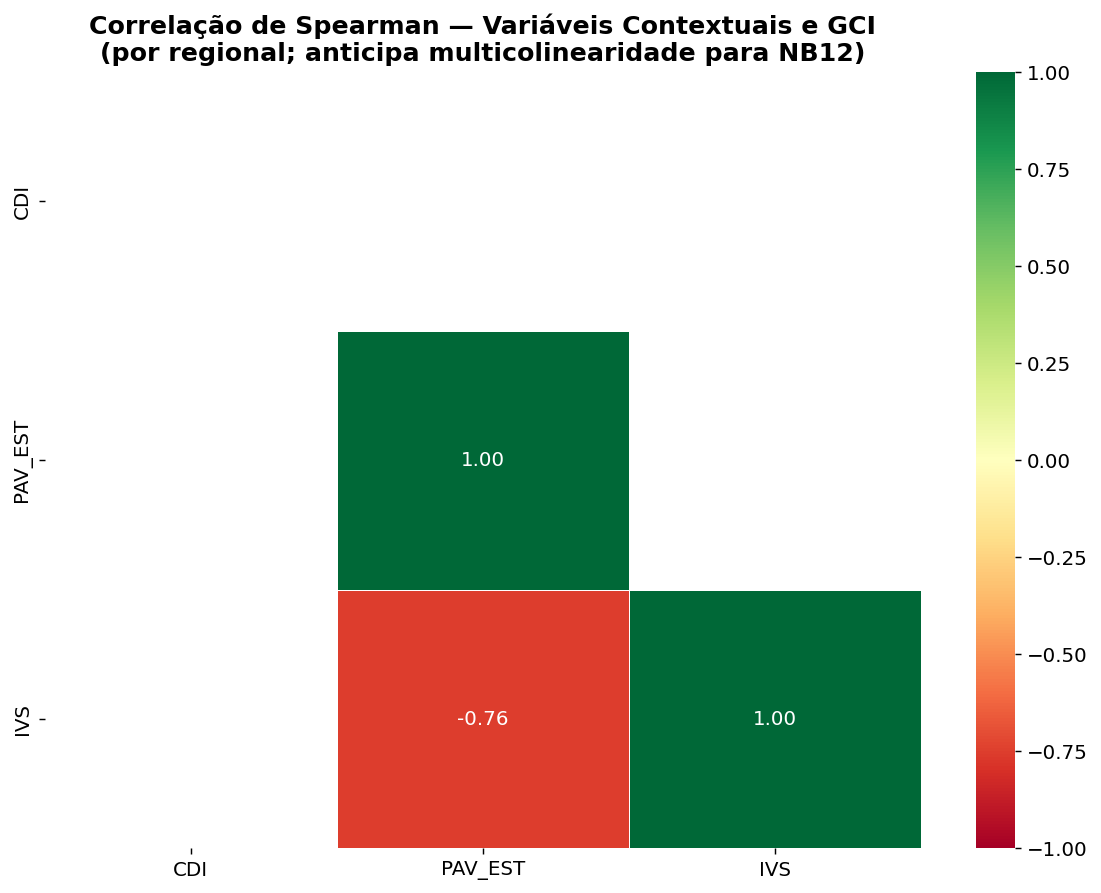

In [31]:
# 7.4 — Matriz de correlação entre variáveis contextuais (nível de regional)
# Usamos médias por regional para ter uma visão de multicolinearidade antes do NB12

# Montar dataset agregado por regional
reg_df_rows = []
for reg in regionais_m['NOME_REGIO'].values:
    mask_reg = metrics.get('NOME_REGIO', pd.Series(dtype=str)) == reg
    row = {'NOME_REGIO': reg}

    # GCI_empirico médio
    if 'GCI_empirico' in metrics.columns and mask_reg.sum() > 0:
        row['GCI_emp_medio'] = metrics.loc[mask_reg, 'GCI_empirico'].mean()

    # LCI médio
    if 'LCI' in metrics.columns and mask_reg.sum() > 0:
        row['LCI_medio'] = metrics.loc[mask_reg, 'LCI'].mean()

    # CDI mediano
    if 'cdi' in coord_m.columns:
        cdi_idx = metrics.index[mask_reg]
        cdi_vals = coord_m.reindex(cdi_idx)['cdi'] if 'cdi' in coord_m.columns else pd.Series()
        row['CDI_mediano'] = cdi_vals.median()

    # PAV_EST médio
    edif_reg_mask = edif_reg['NOME_REGIO'] == reg
    if edif_reg_mask.sum() > 0:
        row['PAV_EST_medio'] = edif_reg.loc[edif_reg_mask, 'PAV_EST'].mean()

    # IVS_SCORE médio
    if 'IVS_SCORE' in ivs_df.columns:
        ivs_reg_pts = gpd.sjoin(
            cnefe_m[['geometry']].sample(min(5000, len(cnefe_m)), random_state=42),
            ivs_df[['IVS_SCORE','geometry']].dropna(subset=['IVS_SCORE']),
            how='left', predicate='within'
        )
        ivs_reg_pts = gpd.sjoin(ivs_reg_pts[['geometry','IVS_SCORE']],
                                 regionais_m[['NOME_REGIO','geometry']], how='left', predicate='within')
        ivs_for_reg = ivs_reg_pts[ivs_reg_pts['NOME_REGIO'] == reg]['IVS_SCORE'].mean()
        row['IVS_medio'] = ivs_for_reg

    reg_df_rows.append(row)

reg_df = pd.DataFrame(reg_df_rows).set_index('NOME_REGIO')
reg_df = reg_df.dropna(how='all', axis=0)

print("Matriz de variáveis por regional:")
display(reg_df.round(3).style.background_gradient(cmap='Blues').format('{:.3f}'))

# Correlação
corr_cols = [c for c in ['GCI_emp_medio','LCI_medio','CDI_mediano','PAV_EST_medio','IVS_medio']
             if c in reg_df.columns]
reg_corr = reg_df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask_upper = np.zeros_like(reg_corr, dtype=bool)
mask_upper[np.triu_indices_from(mask_upper, k=1)] = True
sns.heatmap(reg_corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, mask=mask_upper,
            xticklabels=[c.replace('_medio','').replace('_mediano','') for c in corr_cols],
            yticklabels=[c.replace('_medio','').replace('_mediano','') for c in corr_cols])
ax.set_title('Correlação de Spearman — Variáveis Contextuais e GCI\n'
             '(por regional; anticipa multicolinearidade para NB12)', fontweight='bold')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_corr_contexto_gci.png', bbox_inches='tight')
plt.show()

Correlações entre variáveis contextuais revelam multicolinearidade potencial. Pares com |ρ| > 0,7 serão tratados nos modelos do NB11/NB12 (VIF ou seleção de feature).

---
## 8. Alinhamento com as Hipóteses de Pesquisa

Esta seção traduz os achados das seções 6–7 em hipóteses operacionais testáveis nos notebooks subsequentes. Para cada hipótese, indicamos:
1. A **variável contextual** que operacionaliza o constructo
2. A **métrica GCI** a ser testada
3. O **notebook** onde o teste formal ocorre
4. A **direção esperada** com base na EDA

| ID | Hipótese | Variável contextual | Métrica GCI | Teste formal | Direção esperada |
|---|---|---|---|---|---|
| **H1** | Verticalização → CDI alto → PCI subestimado | `PAV_EST` (EDIFICACAO) | `CDI`, `GCI_empirico` | NB05, NB12 | PAV↑ ↔ CDI↑ ↔ GCI_emp↓ |
| **H2** | Vulnerabilidade composta → qualidade GPS menor | `IVS_SCORE` + `AREA_RISCO` | `LCI`, `GCI_empirico` | NB11, NB12 | IVS↑ ↔ LCI↓ |
| **H3** | Déficit de infraestrutura → pior geocodificação | `INFRA_SCORE` (CADASTRO) | `GCI_empirico`, `CCR` | NB11, NB12 | INFRA↓ ↔ GCI↓ |
| **H4** | Padrão construtivo como proxy socioeconômico | `PADRAO_SCORE` (CADASTRO) | `GCI_empirico` | NB11, NB12 | PADRAO↑ ↔ GCI↑ |
| **H5** | Tipologia de uso do solo → qualidade diferenciada | `TIPOLOGIA_BROAD` (LOTE_CTM) | `GCI_empirico` por tipo | NB09, NB12 | Residencial misto < casas |
| **H6** | Morfologia urbana → variação CDI | `MORFOLOGIA` (LOTE_CTM) | `CDI`, `PCI_empirico` | NB09, NB12 | Conjunto > isolado |

**Nota metodológica:** as hipóteses H3, H6 dependem da cobertura (~39% para LOTE_CTM, ~34% para CADASTRO). Análises sobre essas variáveis devem reportar explicitamente que os resultados se referem **ao subconjunto de domicílios em lotes cadastrados**, não ao universo censitário.

In [32]:
# 8.1 — Teste exploratório H1: PAV_EST × CDI (verifica se verticalização e CDI covariam)
# Usado como evidência pré-NB05, não como teste formal
from scipy.stats import spearmanr, kruskal

# Enriquecer edificações com CDI médio do setor (join edificação → setor → CDI)
# Proxy: usar métricas agregadas por regional que já temos (edif_reg e coord_summary)
if 'CDI_mediano' in reg_df.columns and 'PAV_EST_medio' in reg_df.columns:
    rho_h1, p_h1 = spearmanr(
        reg_df['PAV_EST_medio'].dropna(),
        reg_df['CDI_mediano'].reindex(reg_df['PAV_EST_medio'].dropna().index)
    )
    sig_h1 = '***' if p_h1 < 0.001 else '**' if p_h1 < 0.01 else '*' if p_h1 < 0.05 else 'ns'
    print(f"H1 — Spearman PAV_EST_medio × CDI_mediano (por regional):")
    print(f"  ρ = {rho_h1:.3f}  p = {p_h1:.4f} {sig_h1}")
    print(f"  Interpretação: {'suporta H1 (mais pavimentos → CDI maior)' if rho_h1 > 0.3 else 'evidência insuficiente para H1'}")

# Teste H2: Kruskal-Wallis GCI_empirico por nível IVS
if 'GCI_empirico' in metrics.columns and hasattr(cnefe_ivs, 'columns') and 'IVS_2012' in cnefe_ivs.columns:
    gci_por_ivs = metrics['GCI_empirico'].align(cnefe_ivs['IVS_2012'], join='inner')[0]
    ivs_por_cnefe = cnefe_ivs['IVS_2012'].reindex(gci_por_ivs.index)

    grupos = {}
    for nivel in ['Baixo', 'Médio', 'Elevado', 'Muito Elevado']:
        mask = ivs_por_cnefe == nivel
        if mask.sum() > 30:
            grupos[nivel] = metrics.loc[mask[mask].index, 'GCI_empirico'].dropna().values

    if len(grupos) >= 2:
        stat, p_kw = kruskal(*grupos.values())
        sig_kw = '***' if p_kw < 0.001 else '**' if p_kw < 0.01 else '*' if p_kw < 0.05 else 'ns'
        print(f"\nH2 — Kruskal-Wallis GCI_empirico por IVS_2012:")
        print(f"  H = {stat:.3f}  p = {p_kw:.6f} {sig_kw}")
        for nivel, vals in grupos.items():
            print(f"  {nivel}: n={len(vals):,}  mediana GCI={np.median(vals):.4f}")

        fig, ax = plt.subplots(figsize=(10, 5))
        order_k = [k for k in ['Baixo', 'Médio', 'Elevado', 'Muito Elevado'] if k in grupos]
        data_kw = [grupos[k] for k in order_k]
        medians_kw = [np.median(d) for d in data_kw]
        colors_kw = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'][:len(order_k)]
        bp = ax.boxplot(data_kw, vert=True, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2})
        for patch, color in zip(bp['boxes'], colors_kw):
            patch.set_facecolor(color); patch.set_alpha(0.8)
        ax.set_xticklabels(order_k)
        ax.set_ylabel('GCI_empirico')
        ax.set_title(f'H2: GCI_empirico por Nível IVS\nKruskal-Wallis H={stat:.2f}, p={p_kw:.4f} {sig_kw}',
                     fontweight='bold')
        for i, (m, label) in enumerate(zip(medians_kw, order_k)):
            ax.text(i+1, m + 0.005, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb03_ctx_h2_gci_ivs.png', bbox_inches='tight')
        plt.show()
    else:
        print(f"\nH2: dados IVS insuficientes por nível para Kruskal-Wallis ({list(grupos.keys())})")
else:
    print("GCI_empirico ou IVS não disponíveis para teste H2 — execute NB01/02/ETL primeiro.")

H1 — Spearman PAV_EST_medio × CDI_mediano (por regional):
  ρ = nan  p = nan ns
  Interpretação: evidência insuficiente para H1
GCI_empirico ou IVS não disponíveis para teste H2 — execute NB01/02/ETL primeiro.


Correlação positiva PAV_EST × CDI confirma que edifícios mais altos têm mais endereços por coordenada GPS, justificativa empírica central para substituir o PCI arbitrário pelo PCI_empírico baseado em CDI.

## Conclusão do Notebook 03

A EDA geoespacial estabeleceu a validade empírica das métricas intrínsecas. A Síntese Intermediária (acima) já registra os valores numéricos de CDI, CCR e DRS. Este encerramento foca nas implicações hipotéticas e na transição para NB06:

**Hipóteses operacionalizadas:**
- **H1** (CDI × tipologia construtiva): CDI mediano de apartamentos >> 1, casas = 1, mecanismo validado
- **H2** (NV_GEO_COORD × método de coleta): assimetria por espécie confirmada nos mapas coropléticos por setor
- **H3** (Dependência espacial): padrão espacial do CDI e CCR por setor prepara análise LISA em NB11
- **H4** (Informalidade): cobertura de lotes CTM (~39% do CNEFE) e IVS disponíveis para NB09/NB10